# Terminal-velocity scan and post-Minkowski analyses

This notebook performs the scan in homogeneous frequency $\omega$, extracts the terminal wall velocity, and builds the final Minkowski diagnostic plots for *Globally Charged Vacuum Decay* (arXiv:2606.xxxxx). By default it loads cached scan data when available.

The scan itself is expensive: for each $\omega$ one solves the fixed-$Q$ Euclidean PDE, analytically continues the turning slice, evolves in Minkowski time, extracts $R(t)$ and estimates $v_\infty$. Therefore `RUN_VELOCITY_SCAN=False` by default and the notebook loads `data/terminal_velocity_scan.pkl` if present.

## Theory and consistency checks

The terminal velocity is extracted from the late-time radius $R(t)$ of the real-time bubble. In the fixed-charge case the phase-gradient contribution near the wall grows with the bubble radius and can be fitted as a linear growth of the rest-frame wall tension,

$$
\sigma_{\rm rest}(R,Q)\simeq \sigma_0(Q)+s(Q)R .
$$

Energy conservation at large $R$ then gives

$$
\gamma_\infty(Q)\simeq \frac{\Delta P(Q)}{3s(Q)},\qquad
v_\infty(Q)=\sqrt{1-\gamma_\infty^{-2}} .
$$

The scan tests this mechanism numerically. At small charge, $s(Q)$ vanishes and the neutral runaway limit $v_\infty\to1$ is recovered. At larger charge, the phase shell lowers the terminal velocity. The notebook also keeps the different velocity estimators visible: last-snapshot derivative, late-window median, and asymptotic fit.

## 1. Setup and cache utilities

In [34]:
from __future__ import annotations

import sys
from pathlib import Path
import warnings
import pickle
from types import SimpleNamespace

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.interpolate import RegularGridInterpolator

warnings.filterwarnings("ignore", category=DeprecationWarning)

# -----------------------------------------------------------------------------
# Repository discovery
# -----------------------------------------------------------------------------
def find_qubble_root(start: Path) -> Path:
    """Return the repository root containing Bubble_finder/ and Q_ball_finder/."""
    cur = start.resolve()
    for parent in [cur, *cur.parents]:
        if (parent / "Bubble_finder").is_dir() and (parent / "Q_ball_finder").is_dir():
            return parent
    raise RuntimeError(
        "Could not locate the Qubble repository root. "
        "Run this notebook from inside the repository checkout."
    )

QUBBLE_ROOT = find_qubble_root(Path.cwd())
NOTEBOOK_DIR = Path.cwd().resolve()

if str(QUBBLE_ROOT) not in sys.path:
    sys.path.insert(0, str(QUBBLE_ROOT))

from Bubble_finder.potential_bubble import V_phi, dV_dphi, d2V_dphi2, Omega_phi, vacua_of_Omega, dOmega_dphi
from Bubble_finder.bounce_1d import solve_bounce
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver, make_potential_from_V
from Bubble_finder.observables_1d import (
    compute_charge,
    compute_energy_minkowski_1d_spherical,
    compute_free_energy_grandcanonical,
)
from Bubble_finder.observables_2d import (
    compute_observables_tau0_ghost,
    compute_targets_tau0_ghost,
    compute_charge_tau0_ghost_2d,
)
from Bubble_finder.clean_analysis_helpers import (
    ModelParams,
    configure_matplotlib,
    solve_or_load_bounce_1d,
    compute_1d_observables,
    run_1d_scan,
    build_seed,
    run_newton_with_eta_scan,
    summarize_solution,
    compute_static_energy_minus_hom_vs_tau,
    plot_seed_maps,
    plot_solution_maps,
)

# -----------------------------------------------------------------------------
# Runtime switches
# -----------------------------------------------------------------------------
RUN_EUCLIDEAN_SOLVE = False
REUSE_EUCLIDEAN_CACHE = True
RUN_MINKOWSKI_EVOLUTION = False
REUSE_MINKOWSKI_CACHE = True

# Use the same high-resolution settings as the production analysis by default.
# For a quick local smoke test set PUBLICATION_RESOLUTION = False.
PUBLICATION_RESOLUTION = True

CFG = {
    "save_figures": True,
    "use_tex": True,
    "random_seed": 7,
    "figures_dir": NOTEBOOK_DIR / "figures",
    "cache_dir": NOTEBOOK_DIR / "cache_minkowski_public",
}

np.random.seed(CFG["random_seed"])
CFG["figures_dir"].mkdir(parents=True, exist_ok=True)
CFG["cache_dir"].mkdir(parents=True, exist_ok=True)
Path("figures").mkdir(parents=True, exist_ok=True)

configure_matplotlib(use_tex=CFG["use_tex"], fontsize=12, dpi=140)
plt.rcParams.update({
    "text.usetex": bool(CFG["use_tex"]),
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

print(f"Qubble root: {QUBBLE_ROOT}")
print(f"Notebook dir: {NOTEBOOK_DIR}")
print(f"Figures dir:    {CFG['figures_dir']}")
print(f"Cache dir:      {CFG['cache_dir']}")


# Heavy operations are off by default. The notebook first tries to load cached
# data from data/*.pkl or cache_minkowski_public/*.npz. If the cache is missing,
# the corresponding section is skipped rather than interrupting Run All.
RUN_EUCLIDEAN_SOLVE_IF_CACHE_MISSING = False
RUN_LONG_SINGLE_BUBBLE = False
RUN_TWO_BUBBLE_2D = False
RUN_AXISYMMETRIC_3D = False
RUN_PERIODIC_MULTI_BUBBLE_2D = False
RUN_VELOCITY_SCAN = False
RUN_VIDEOS = False

LOAD_EUCLIDEAN_CACHE = True
LOAD_LONG_SINGLE_BUBBLE_CACHE = True
LOAD_TWO_BUBBLE_2D_CACHE = True
LOAD_AXISYMMETRIC_3D_CACHE = True
LOAD_PERIODIC_MULTI_BUBBLE_2D_CACHE = True
LOAD_TERMINAL_VELOCITY_SCAN_CACHE = True

DATA_DIR = NOTEBOOK_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Default mode: load cached data and skip expensive runs if the cache is absent.")

In [35]:
from types import SimpleNamespace
import pickle

def _as_snapshot_list(data, prefix=""):
    snap_t = np.asarray(data[prefix + "snapshot_t"], dtype=float)
    out = []
    keys = [k for k in data.files if k.startswith(prefix + "snap_")]
    arrays = {k[len(prefix + "snap_"):]: np.asarray(data[k]) for k in keys}
    for i, t in enumerate(snap_t):
        fields = {name: arr[i] for name, arr in arrays.items() if arr.shape[0] == len(snap_t)}
        fields["t"] = float(t)
        out.append(SimpleNamespace(**fields))
    return out


def save_history_npz(path, hist, grid_names):
    """Save a radial/2D/axisymmetric history in a lightweight, plotting-friendly format."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    snaps = list(getattr(hist, "snapshots", []))
    payload = {
        "t": np.asarray(getattr(hist, "t", []), dtype=float),
        "energy": np.asarray(getattr(hist, "energy", []), dtype=float),
        "charge": np.asarray(getattr(hist, "charge", []), dtype=float),
        "snapshot_t": np.asarray([s.t for s in snaps], dtype=float),
    }
    for g in grid_names:
        payload[g] = np.asarray(getattr(hist, g), dtype=float)
    snap_fields = ["phi", "phibar", "dotphi", "dotphibar", "rho_phys", "phase_angle"]
    for name in snap_fields:
        vals = []
        ok = True
        for s in snaps:
            if not hasattr(s, name):
                ok = False
                break
            vals.append(getattr(s, name))
        if ok and len(vals) > 0:
            payload[f"snap_{name}"] = np.asarray(vals)
    np.savez_compressed(path, **payload)
    print(f"Saved history cache: {path}")


def load_history_npz(path, grid_names):
    path = Path(path)
    data = np.load(path, allow_pickle=True)
    snaps = _as_snapshot_list(data)
    fields = {
        "t": np.asarray(data["t"], dtype=float),
        "energy": np.asarray(data["energy"], dtype=float),
        "charge": np.asarray(data["charge"], dtype=float),
        "snapshots": snaps,
    }
    for g in grid_names:
        fields[g] = np.asarray(data[g], dtype=float)
    return SimpleNamespace(**fields)


def maybe_load_history(name, path, grid_names, load_flag=True):
    path = Path(path)
    if load_flag and path.exists():
        globals()[name] = load_history_npz(path, grid_names)
        print(f"Loaded {name} from {path}")
        return globals()[name]
    print(f"No cache loaded for {name}. Expected path: {path}")
    return None

LONG_SINGLE_CACHE = DATA_DIR / "single_bubble_long_history.npz"
TWO_BUBBLE_2D_CACHE = DATA_DIR / "two_bubble_2d_history.npz"
AXISYMMETRIC_3D_CACHE = DATA_DIR / "axisymmetric_3d_history.npz"
PERIODIC_2D_CACHE = DATA_DIR / "periodic_2d_history.npz"
TERMINAL_SCAN_CACHE_PATH = DATA_DIR / "terminal_velocity_scan.pkl"

## 2. Model and Euclidean scan helpers

Reference parameters: phi0=1.999, v1=1.0, v2=2.0, omega=0.95
False vacuum: phi_false = 1.0312018015
True vacuum:  phi_true  = 2.0656590991


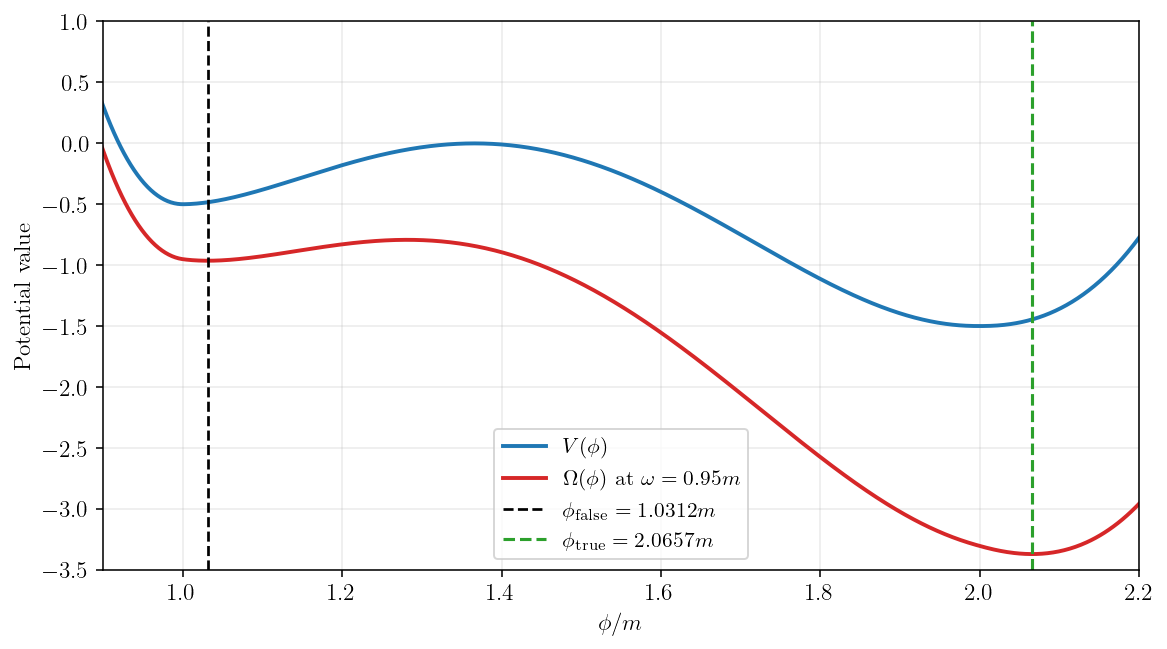

In [36]:
# Model parameters and reference angular frequency
MODEL = ModelParams(phi0=1.999, v1=1.0, v2=2.0)
OMEGA_REF = 0.95

phi_grid = np.linspace(MODEL.v1 - 0.2, MODEL.v2 + 0.2, 1000)
V_vals = V_phi(phi_grid, MODEL.phi0, MODEL.v1, MODEL.v2)
Om_vals = Omega_phi(phi_grid, MODEL.phi0, MODEL.v1, MODEL.v2, OMEGA_REF)

phi_false_ref, phi_true_ref = vacua_of_Omega(
    MODEL.phi0, MODEL.v1, MODEL.v2, OMEGA_REF, verbose=False
)

print(f"Reference parameters: phi0={MODEL.phi0}, v1={MODEL.v1}, v2={MODEL.v2}, omega={OMEGA_REF}")
print(f"False vacuum: phi_false = {phi_false_ref:.10f}")
print(f"True vacuum:  phi_true  = {phi_true_ref:.10f}")

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(phi_grid, V_vals, color="C0", label=r"$V(\phi)$")
ax.plot(phi_grid, Om_vals, color="C3", label=rf"$\Omega(\phi)$ at $\omega={OMEGA_REF:.2f}m$")
ax.axvline(phi_false_ref, color="k", ls="--", lw=1.4, label=rf"$\phi_{{\mathrm{{false}}}}={phi_false_ref:.4f}m$")
ax.axvline(phi_true_ref, color="C2", ls="--", lw=1.6, label=rf"$\phi_{{\mathrm{{true}}}}={phi_true_ref:.4f}m$")
ax.set_xlabel(r"$\phi/m$")
ax.set_ylabel(r"Potential value")
ax.set_xlim(MODEL.v1 * 0.9, MODEL.v2 * 1.1)
ax.set_ylim(-3.5, 1)
ax.legend(loc="best")
fig.tight_layout()
if CFG["save_figures"]:
    fig.savefig(CFG["figures_dir"] / "potential_and_omega_vacua.pdf", bbox_inches="tight")
plt.show()

In [37]:
DIMENSIONS = (1, 3, 4)
OMEGA_SET = {
    "omega_ref": float(OMEGA_REF),
    "omega_zero": 0.0,
}

bounces_fixed: dict[str, dict[int, dict]] = {k: {} for k in OMEGA_SET}

for om_label, om in OMEGA_SET.items():
    for d in DIMENSIONS:
        bounces_fixed[om_label][d] = solve_or_load_bounce_1d(
            None,
            MODEL,
            omega=om,
            d=d,
            rmax=260.0,
            n_grid_points=1000,
            max_iter=180,
            verbose=False,
        )

print("1D bounce profiles:")
for om_label, dct in bounces_fixed.items():
    print(f"  {om_label}:")
    for d, b in dct.items():
        src = "cache" if b.get("from_cache", False) else "new"
        print(f"    O({d}): points={len(b['r'])}, phi_false={b['phi_false']:.6f}, source={src}")

1D bounce profiles:
  omega_ref:
    O(1): points=1000, phi_false=1.031202, source=new
    O(3): points=1000, phi_false=1.031202, source=new
    O(4): points=1000, phi_false=1.031202, source=new
  omega_zero:
    O(1): points=1000, phi_false=1.000000, source=new
    O(3): points=1000, phi_false=1.000000, source=new
    O(4): points=1000, phi_false=1.000000, source=new


This short 1D scan determines the available homogeneous charged branch and hence $\omega_{\max}$ for the terminal-velocity scan.

In [38]:
def estimate_omega_max(model: ModelParams, omega_hi: float = 1.4, ntest: int = 240) -> float:
    oms = np.linspace(0.0, omega_hi, ntest)
    ok = []
    for om in oms:
        try:
            vacua_of_Omega(model.phi0, model.v1, model.v2, float(om), verbose=False)
            ok.append(True)
        except Exception:
            ok.append(False)
    ok = np.asarray(ok, dtype=bool)
    if not np.any(ok):
        raise RuntimeError("No valid omega found in tested range")
    last = np.where(ok)[0][-1]
    return float(oms[last])

# Grid settings for the short omega scan (same convention as the faithful notebooks).
RMAX_1D_FIXED = 260.0
N_GRID_1D_SCAN = 1300
MAX_ITER_1D_SCAN = 170
N_OMEGA_SCAN_FOR_OMEGA_MAX = 2

OMEGA_MAX = estimate_omega_max(MODEL)
omega_scan = np.linspace(0.0, 0.999 * OMEGA_MAX, int(N_OMEGA_SCAN_FOR_OMEGA_MAX))
print(f"Estimated omega_max ~ {OMEGA_MAX:.6f}")
print(f"Scan points used only to infer omega_max: {len(omega_scan)}")

scan_profiles = run_1d_scan(
    None,
    MODEL,
    omega_values=omega_scan,
    dimensions=(3, 4),
    rmax=float(RMAX_1D_FIXED),
    n_grid_points=int(N_GRID_1D_SCAN),
    max_iter=int(MAX_ITER_1D_SCAN),
    verbose=False,
)

scan_summary = {3: [], 4: []}
for d in (3, 4):
    for b in scan_profiles[d]:
        obs = compute_1d_observables(MODEL, b)
        scan_summary[d].append(
            {
                "omega": b["omega"],
                "phi_center": b["phi0_center"],
                "phi_false": b["phi_false"],
                "phi_true": b["phi_true"],
                **obs,
            }
        )

for d in (3, 4):
    scan_summary[d] = sorted(scan_summary[d], key=lambda x: x["omega"])

print(f"Converged points: O(3)={len(scan_summary[3])}, O(4)={len(scan_summary[4])}")


Estimated omega_max ~ 1.341423
Scan points used only to infer omega_max: 2
Converged points: O(3)=2, O(4)=2


In [39]:
# 2D default configuration.
# IMPORTANT: force the homogeneous background to the FALSE-vacuum branch.
phi_false_2d, phi_true_2d = vacua_of_Omega(MODEL.phi0, MODEL.v1, MODEL.v2, float(OMEGA_REF), verbose=False)
rho0_false_solver_units = float(phi_false_2d / np.sqrt(2.0))

if PUBLICATION_RESOLUTION:
    Nr_2d, Ntau_2d, Lr_2d, beta_2d = 600, 100, 10.0, 10.0
else:
    Nr_2d, Ntau_2d, Lr_2d, beta_2d = 160, 60, 10.0, 10.0

CFG_2D = {
    "Nr": Nr_2d,
    "Ntau": Ntau_2d,
    "Lr": Lr_2d,
    "beta": beta_2d,
    "omega_ref": float(OMEGA_REF),
    "eta0_init": 0.0,
    "newton_tol": 1e-8,
    "newton_max_iter": 45,
    "damping": 0.8,
    "max_backtracks": 28,
    "rho0_bracket": (0.6, 1.6),
    "rho0_false": rho0_false_solver_units,
    "complex_saddle": True,
    "verbose": True,
}

U, dU, d2U = make_potential_from_V(
    V_phi,
    dV_dphi,
    d2V_dphi2,
    MODEL.phi0,
    MODEL.v1,
    MODEL.v2,
)

profiles_for_seeds = {
    "O1": bounces_fixed["omega_ref"][1],
    "O3": bounces_fixed["omega_ref"][3],
    "O4": bounces_fixed["omega_ref"][4],
}

_solver_target = Bubble2DSolver(
    Bubble2DSettings(
        Nr=CFG_2D["Nr"],
        Ntau=CFG_2D["Ntau"],
        Lr=CFG_2D["Lr"],
        beta=CFG_2D["beta"],
        omega_ref=CFG_2D["omega_ref"],
        eta0=float(CFG_2D["eta0_init"]),
        rho0=float(CFG_2D["rho0_false"]),
        newton_tol=CFG_2D["newton_tol"],
        newton_max_iter=CFG_2D["newton_max_iter"],
        damping=CFG_2D["damping"],
        max_backtracks=CFG_2D["max_backtracks"],
        rho0_bracket=CFG_2D["rho0_bracket"],
        complex_saddle=CFG_2D["complex_saddle"],
        verbose=False,
        tau_bc="twisted",
        r_bc="neumann",
        allow_debug_bcs=False,
    ),
    U,
    dU,
    d2U,
)
_targets_2d = compute_targets_tau0_ghost(
    _solver_target,
    subtract_background_charge=False,
)
Q_TARGET_2D = float(_targets_2d["Q"])

Q_TARGET_2D_FROM_1D = compute_1d_observables(
    MODEL,
    bounces_fixed["omega_ref"][3],
    r_max_ref=CFG_2D["Lr"],
)["Q"]

print(f"2D vacua at omega_ref: phi_false={phi_false_2d:.10e}, phi_true={phi_true_2d:.10e}")
print(f"Forced solver rho0 [|phi| units]: {CFG_2D['rho0_false']:.10e}")
print(f"Forced homogeneous rho_phys = sqrt(2)*rho0: {np.sqrt(2.0)*CFG_2D['rho0_false']:.10e}")
print(f"Target charge for 2D eta0 scan: Q_target = {Q_TARGET_2D:.10e}")

2D vacua at omega_ref: phi_false=1.0312018015e+00, phi_true=2.0656590991e+00
Forced solver rho0 [|phi| units]: 7.2916978659e-01
Forced homogeneous rho_phys = sqrt(2)*rho0: 1.0312018015e+00
Target charge for 2D eta0 scan: Q_target = 4.2315506009e+03


In [40]:
def make_solver(eta0: float = 0.0, verbose: bool = True) -> Bubble2DSolver:
    settings = Bubble2DSettings(
        Nr=CFG_2D["Nr"],
        Ntau=CFG_2D["Ntau"],
        Lr=CFG_2D["Lr"],
        beta=CFG_2D["beta"],
        omega_ref=CFG_2D["omega_ref"],
        eta0=float(eta0),
        rho0=float(CFG_2D["rho0_false"]),
        newton_tol=CFG_2D["newton_tol"],
        newton_max_iter=CFG_2D["newton_max_iter"],
        damping=CFG_2D["damping"],
        max_backtracks=CFG_2D["max_backtracks"],
        rho0_bracket=CFG_2D["rho0_bracket"],
        complex_saddle=CFG_2D["complex_saddle"],
        verbose=bool(verbose),
        tau_bc="twisted",
        r_bc="neumann",
        allow_debug_bcs=False,
    )
    return Bubble2DSolver(settings, U, dU, d2U)

SEED_TYPES = ["O4_seed", "O3_static_seed", "O1_tau_seed", "homogeneous_seed"]
seed_preview = {}
solver_preview = make_solver(eta0=0.0, verbose=False)
for s in SEED_TYPES:
    x0, rho_seed = build_seed(solver_preview, s, profiles_for_seeds)
    seed_preview[s] = {"x0": x0, "rho_seed": rho_seed}

print("Seed system initialized for:")
for s in SEED_TYPES:
    arr = seed_preview[s]["rho_seed"]
    print(f"  {s:<18} shape={arr.shape}, min={arr.min():.6f}, max={arr.max():.6f}")

Seed system initialized for:
  O4_seed            shape=(600, 100), min=0.729170, max=1.423209
  O3_static_seed     shape=(600, 100), min=0.729170, max=1.348682
  O1_tau_seed        shape=(600, 100), min=0.729170, max=1.013437
  homogeneous_seed   shape=(600, 100), min=0.729170, max=0.729170


In [41]:
def _newton_compact_pat():
    import re
    return re.compile(
        r"iter=(\d+).*?\|\|F\|\|=([+\-0-9.eE]+).*?rhoQ=([+\-0-9.eE]+).*?rhoE=([+\-0-9.eE]+).*?"
        r"rho_Q/rho_Q_ref=([+\-0-9.eE]+).*?rho_E/rho_E_ref=([+\-0-9.eE]+)"
    )


def _print_newton_compact_from_line(line, pat=None):
    if "[Newton-explicit]" not in line:
        return
    pat = pat or _newton_compact_pat()
    m = pat.search(line)
    if m is None:
        return
    it = int(m.group(1))
    nF = float(m.group(2))
    q_val = float(m.group(3))
    e_val = float(m.group(4))
    q_ratio = float(m.group(5))
    e_ratio = float(m.group(6))
    print(
        f"[Newton-compact] iter={it:02d}  ||F||={nF:.3e}  "
        f"rho_Q={q_val:.8e}  rho_E={e_val:.8e}  "
        f"rho_Q/rho_Q*= {q_ratio:.6f}  rho_E/rho_E*= {e_ratio:.6f}",
        flush=True,
    )


class _StdoutNewtonCompactLive:
    """Parse [Newton-explicit] lines from solve() and emit [Newton-compact] immediately."""

    def __init__(self, stream):
        import re
        self._stream = stream
        self._buf = ""
        self._pat = _newton_compact_pat()

    def write(self, text):
        if not text:
            return
        self._buf += text
        while "\n" in self._buf:
            line, self._buf = self._buf.split("\n", 1)
            _print_newton_compact_from_line(line, self._pat)

    def flush(self):
        if self._buf:
            _print_newton_compact_from_line(self._buf, self._pat)
            self._buf = ""
        self._stream.flush()

    def isatty(self):
        return getattr(self._stream, "isatty", lambda: False)()


def _solve_at_eta_local(slv, eta, x_init, verbose=False, newton_live=False):
    import io
    import sys
    from contextlib import redirect_stdout

    slv.settings.eta0 = float(eta)
    slv.eta0 = float(eta)

    use_compact = bool(verbose or newton_live)
    if use_compact and newton_live:
        print(f"[Newton-compact] starting solve at eta0={float(eta):.6f}", flush=True)
        live_out = _StdoutNewtonCompactLive(sys.stdout)
        with redirect_stdout(live_out):
            sol_eta = slv.solve(x_init, verbose=True, verbose_success_block=False)
        live_out.flush()
    elif use_compact:
        buf = io.StringIO()
        with redirect_stdout(buf):
            sol_eta = slv.solve(x_init, verbose=True, verbose_success_block=False)

        for line in buf.getvalue().splitlines():
            _print_newton_compact_from_line(line)
    else:
        sol_eta = slv.solve(x_init, verbose=False, verbose_success_block=False)

    q_eta = float(
        compute_charge_tau0_ghost_2d(
            slv,
            sol_eta.y,
            sol_eta.ybar,
            subtract_background=False,
        )
    )
    e_eta = float(sol_eta.E_tau0)
    r_eta = float(sol_eta.residual_norm)
    return q_eta, e_eta, r_eta, sol_eta


def _eta_scan_match_charge_local(
    slv,
    x_seed,
    Q_target_here,
    eta_start=0.0,
    d_eta=0.02,
    max_steps=80,
    tol_q=1e-6,
    scan_label="eta-scan",
    newton_live=False,
):
    tol_abs = float(tol_q * max(1.0, abs(Q_target_here)))
    history = []

    targets = compute_targets_tau0_ghost(slv, subtract_background_charge=False)
    Q_target = float(targets["Q"])
    E_target = float(targets["E"])

    print("[Targets] eta0 scan references (total observables):")
    print(f"  Q_target_total = {Q_target:.8e}")
    print(f"  E_target_total = {E_target:.8e}")

    def _print_compact_line(tag, eta, q_val, e_val):
        q_ratio = q_val / Q_target if abs(Q_target) > 1e-30 else np.nan
        e_ratio = e_val / E_target if abs(E_target) > 1e-30 else np.nan
        print(
            f"[{tag}] eta={eta:.6f}  Q_total={q_val:.8e}  E_total={e_val:.8e}  "
            f"Q_total/Q*= {q_ratio:.6f}  E_total/E*= {e_ratio:.6f}"
        )

    # First solve at eta=0 with full Newton verbose output
    eta_curr = float(eta_start)
    q_curr, e_curr, r_curr, sol_curr = _solve_at_eta_local(slv, eta_curr, x_seed, verbose=False, newton_live=newton_live)
    x_seed = np.asarray(sol_curr.x, dtype=float).copy()
    history.append({"eta0": eta_curr, "Q": q_curr, "E": e_curr, "residual": r_curr})

    _print_compact_line(scan_label, eta_curr, q_curr, e_curr)
    if abs(q_curr - Q_target_here) <= tol_abs:
        return sol_curr, {
            "eta0": eta_curr,
            "eta_bracket_used": (eta_curr, eta_curr),
            "history": history,
        }

    eta_prev, q_prev = eta_curr, q_curr
    crossed = False

    # Step scan from eta=0, no initial global bracketing
    for _ in range(int(max_steps)):
        eta_prev, q_prev = eta_curr, q_curr
        if q_curr < Q_target_here:
            eta_curr += d_eta
        else:
            eta_curr -= d_eta

        q_curr, e_curr, r_curr, sol_curr = _solve_at_eta_local(slv, eta_curr, x_seed, verbose=False, newton_live=False)
        x_seed = np.asarray(sol_curr.x, dtype=float).copy()
        history.append({"eta0": eta_curr, "Q": q_curr, "E": e_curr, "residual": r_curr})
        _print_compact_line(scan_label, eta_curr, q_curr, e_curr)

        if (q_prev - Q_target_here) * (q_curr - Q_target_here) <= 0:
            crossed = True
            break

    if not crossed:
        raise RuntimeError("O4 eta-scan did not cross target charge within max_steps")

    eta_lo, eta_hi = (eta_prev, eta_curr) if eta_prev < eta_curr else (eta_curr, eta_prev)
    state = {"x_seed": x_seed}
    cache = {}

    def _f_eta(eta):
        key = round(float(eta), 12)
        if key in cache:
            return cache[key]["Q"] - Q_target_here

        q_val, e_val, r_val, sol_val = _solve_at_eta_local(slv, float(eta), state["x_seed"], verbose=False, newton_live=False)
        state["x_seed"] = np.asarray(sol_val.x, dtype=float).copy()
        cache[key] = {"Q": q_val, "E": e_val, "residual": r_val}
        history.append({"eta0": float(eta), "Q": q_val, "E": e_val, "residual": r_val})
        return q_val - Q_target_here

    eta_star = float(brentq(_f_eta, eta_lo, eta_hi, xtol=1e-10))
    q_star, e_star, r_star, sol_star = _solve_at_eta_local(slv, eta_star, state["x_seed"], verbose=False, newton_live=False)
    history.append({"eta0": eta_star, "Q": q_star, "E": e_star, "residual": r_star})

    _print_compact_line(f"{scan_label}*", eta_star, q_star, e_star)

    return sol_star, {
        "eta0": eta_star,
        "eta_bracket_used": (eta_lo, eta_hi),
        "history": history,
    }


def _resample_seed_to_solver_grid(old_solver, new_solver, x_old):
    """
    Resample a full 2D state preserving complex structure (y, ybar),
    then repack in the new solver representation.

    This avoids losing phase information that would be dropped by rho-only resampling.
    """
    y_old, ybar_old = old_solver.unpack(np.asarray(x_old))

    r_old = np.asarray(old_solver.grid.r, dtype=float)
    tau_old = np.asarray(old_solver.grid.tau, dtype=float)
    r_new = np.asarray(new_solver.grid.r, dtype=float)
    tau_new = np.asarray(new_solver.grid.tau, dtype=float)

    def _interp_complex(field_old: np.ndarray) -> np.ndarray:
        f_re = RegularGridInterpolator(
            (r_old, tau_old),
            np.asarray(field_old.real, dtype=float),
            method="linear",
            bounds_error=False,
            fill_value=None,
        )
        f_im = RegularGridInterpolator(
            (r_old, tau_old),
            np.asarray(field_old.imag, dtype=float),
            method="linear",
            bounds_error=False,
            fill_value=None,
        )
        RR, TT = np.meshgrid(r_new, tau_new, indexing="ij")
        pts = np.column_stack([RR.ravel(), TT.ravel()])
        re_new = f_re(pts).reshape((r_new.size, tau_new.size))
        im_new = f_im(pts).reshape((r_new.size, tau_new.size))
        return re_new + 1j * im_new

    y_new = _interp_complex(np.asarray(y_old))
    ybar_new = _interp_complex(np.asarray(ybar_old))

    return new_solver.pack(y_new, ybar_new)


def _prepare_seed_for_solver_grid(solver_target, x_seed, solver_source=None, label="seed"):
    try:
        _ = solver_target.unpack(np.asarray(x_seed))
        return np.asarray(x_seed).copy()
    except Exception:
        if solver_source is None:
            raise RuntimeError(f"[{label}] incompatible seed and no source solver provided for resampling.")
        x_resampled = _resample_seed_to_solver_grid(solver_source, solver_target, x_seed)
        return x_resampled

## Scan in omega: terminal wall velocity vs Q / Q_max

We perform a continuation scan in the homogeneous frequency $\omega$, starting at $\omega=0.05$ and increasing in steps of $0.1$ up to $\omega_{\max}$. For each scan point we:

1. solve the Euclidean 2D bubble using continuation from the previous converged point (first point from an O(4) seed),
2. run Minkowski evolution up to $t=8$,
3. extract an effective late-time wall velocity,
4. compute the homogeneous reference charge $Q$ and normalize by $Q_{\max}$,
5. store robust diagnostics and plot $v_{\mathrm{terminal}}$ against $Q/Q_{\max}$.

The scan is defensive: if one point fails, it stores `NaN` diagnostics and continues.

In [42]:
# Omega-scan setup and robust helpers
import numpy as np
import matplotlib.pyplot as plt

import importlib

def _import_pandas():
    try:
        return importlib.import_module("pandas")
    except ImportError as exc:
        raise ImportError(
            "pandas is required. Install with: pip install pandas\n"
            "or: pip install -r requirements.txt"
        ) from exc

pd = _import_pandas()


def _infer_omega_max_for_scan() -> tuple[float, str]:
    """Infer omega_max strictly from the 1D scan summary (preferred physics source)."""
    if "scan_summary" not in globals():
        return estimate_omega_max(MODEL), "estimate_omega_max(MODEL)"

    # Prefer O(4) branch if available, fallback to O(3).
    if 4 in scan_summary and len(scan_summary[4]) > 0:
        omega_max_1d = float(max(float(r["omega"]) for r in scan_summary[4]))
        omega_max_source = "scan_summary[4]"
    elif 3 in scan_summary and len(scan_summary[3]) > 0:
        omega_max_1d = float(max(float(r["omega"]) for r in scan_summary[3]))
        omega_max_source = "scan_summary[3]"
    else:
        raise RuntimeError("scan_summary has no O(4)/O(3) points. Cannot infer omega_max from 1D scan.")

    if not np.isfinite(omega_max_1d):
        raise RuntimeError("Inferred omega_max from 1D scan is not finite.")

    return omega_max_1d, omega_max_source


def _make_solver_for_omega(omega_now: float, eta0_guess: float, beta_fixed: float):
    """Build a Bubble2DSolver with notebook-standard settings at fixed omega."""
    phi_false_now, _ = vacua_of_Omega(MODEL.phi0, MODEL.v1, MODEL.v2, float(omega_now), verbose=False)
    rho0_now = float(phi_false_now / np.sqrt(2.0))

    settings_now = Bubble2DSettings(
        Nr=CFG_2D["Nr"],
        Ntau=CFG_2D["Ntau"],
        Lr=CFG_2D["Lr"],
        beta=float(beta_fixed),
        omega_ref=float(omega_now),
        eta0=float(eta0_guess),
        rho0=float(rho0_now),
        newton_tol=CFG_2D["newton_tol"],
        newton_max_iter=CFG_2D["newton_max_iter"],
        damping=CFG_2D["damping"],
        max_backtracks=CFG_2D["max_backtracks"],
        rho0_bracket=CFG_2D["rho0_bracket"],
        complex_saddle=CFG_2D["complex_saddle"],
        verbose=False,
        tau_bc="twisted",
        r_bc="neumann",
        allow_debug_bcs=False,
    )
    return Bubble2DSolver(settings_now, U, dU, d2U)


def _extract_radius_dynamic_halfheight(r_grid: np.ndarray, rho_rt: np.ndarray, n_inner: int = 4, n_outer: int = 16):
    """Dynamic half-height radius using median inner/outer windows per snapshot."""
    r_grid = np.asarray(r_grid, dtype=float)
    rho_rt = np.asarray(rho_rt, dtype=float)

    n_t, n_r = rho_rt.shape
    n_inner = int(max(2, min(n_inner, n_r // 4)))
    n_outer = int(max(3, min(n_outer, n_r // 2)))

    rho_in = np.nanmedian(rho_rt[:, :n_inner], axis=1)
    rho_out = np.nanmedian(rho_rt[:, -n_outer:], axis=1)
    rho_level = 0.5 * (rho_in + rho_out)

    radius_t = np.full(n_t, np.nan, dtype=float)

    for it in range(n_t):
        f = rho_rt[it, :] - rho_level[it]
        if np.all(~np.isfinite(f)):
            continue

        s = np.sign(f)
        s[~np.isfinite(s)] = 0.0

        idx = None
        for j in range(n_r - 1):
            if not (np.isfinite(f[j]) and np.isfinite(f[j + 1])):
                continue
            if f[j] == 0.0:
                idx = j
                break
            if f[j] * f[j + 1] < 0.0:
                idx = j
                break

        if idx is None:
            continue

        f0 = f[idx]
        f1 = f[idx + 1]
        r0 = r_grid[idx]
        r1 = r_grid[idx + 1]

        if np.isclose(f1, f0):
            radius_t[it] = r0
        else:
            alpha = -f0 / (f1 - f0)
            alpha = float(np.clip(alpha, 0.0, 1.0))
            radius_t[it] = r0 + alpha * (r1 - r0)

    return radius_t, rho_in, rho_out, rho_level


def _local_quadratic_velocity(t_arr: np.ndarray, r_arr: np.ndarray, half_window: int = 3):
    """Estimate dR/dt via local quadratic fits around each valid point."""
    t_arr = np.asarray(t_arr, dtype=float)
    r_arr = np.asarray(r_arr, dtype=float)
    v = np.full_like(r_arr, np.nan, dtype=float)

    good = np.isfinite(t_arr) & np.isfinite(r_arr)
    idx_good = np.where(good)[0]
    if idx_good.size < 3:
        return v

    for k in idx_good:
        i0 = max(0, k - half_window)
        i1 = min(t_arr.size, k + half_window + 1)
        tw = t_arr[i0:i1]
        rw = r_arr[i0:i1]

        m = np.isfinite(tw) & np.isfinite(rw)
        if np.count_nonzero(m) < 3:
            continue

        tw = tw[m]
        rw = rw[m]
        if np.unique(tw).size < 3:
            continue

        coeff = np.polyfit(tw, rw, deg=2)
        a2, a1, _ = coeff
        v[k] = 2.0 * a2 * t_arr[k] + a1

    return v


def _terminal_velocity_from_rt(t_arr: np.ndarray, radius_t: np.ndarray, tlate_min: float = 6.0, tlate_max: float = 8.0):
    """Compute effective terminal velocity and diagnostics from R(t)."""
    v_t = _local_quadratic_velocity(t_arr, radius_t, half_window=3)

    late_mask = np.isfinite(v_t) & np.isfinite(t_arr) & (t_arr >= tlate_min) & (t_arr <= tlate_max)
    n_late = int(np.count_nonzero(late_mask))

    if n_late >= 3:
        v_eff = float(np.nanmean(v_t[late_mask]))
        v_std = float(np.nanstd(v_t[late_mask]))
        used_mask = late_mask
    else:
        good = np.where(np.isfinite(v_t) & np.isfinite(t_arr))[0]
        if good.size == 0:
            return np.nan, np.nan, np.nan, 0, v_t
        n_tail = int(min(10, good.size))
        tail_idx = good[-n_tail:]
        v_eff = float(np.nanmean(v_t[tail_idx]))
        v_std = float(np.nanstd(v_t[tail_idx]))
        used_mask = np.zeros_like(v_t, dtype=bool)
        used_mask[tail_idx] = True
        n_late = int(n_tail)

    last_good = np.where(np.isfinite(v_t))[0]
    v_last = float(v_t[last_good[-1]]) if last_good.size > 0 else np.nan

    return v_eff, v_last, v_std, n_late, v_t


def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


omega_start_scan_terminal = 0.05
omega_step_scan_terminal = 0.05

# Use the true omega_max from the 1D scan summary (no hard cap here).
omega_max_scan_terminal, omega_max_source_terminal = _infer_omega_max_for_scan()

omega_list_terminal = list(np.round(np.arange(omega_start_scan_terminal, omega_max_scan_terminal + 1e-12, omega_step_scan_terminal), 12))
omega_list_terminal = [float(w) for w in omega_list_terminal if w <= omega_max_scan_terminal + 1e-12]

if len(omega_list_terminal) == 0:
    raise RuntimeError("Empty omega scan list. Check omega_max inference.")

print(f"omega_max source (1D scan) = {omega_max_source_terminal}")
print(f"omega_max used for scan    = {omega_max_scan_terminal:.6f}")
print(f"|omega_max - 1.34|         = {abs(omega_max_scan_terminal - 1.34):.6f}")
if abs(omega_max_scan_terminal - 1.34) > 0.12:
    print("[warning] omega_max is not close to 1.34; verify the 1D scan range and converged points.")
print(f"omega_list ({len(omega_list_terminal)} points):")
print(omega_list_terminal)

omega_max source (1D scan) = scan_summary[4]
omega_max used for scan    = 1.340081
|omega_max - 1.34|         = 0.000081
omega_list (26 points):
[0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15, 1.2, 1.25, 1.3]


In [43]:
# ============================================================
# Load terminal-velocity scan bundle, cache-first and non-fatal
# ============================================================
import pickle
import numpy as np
import importlib

TERMINAL_SCAN_CACHE_PATH = DATA_DIR / "terminal_velocity_scan.pkl"

def _import_pandas_optional():
    try:
        return importlib.import_module("pandas")
    except ImportError:
        return None

pd = _import_pandas_optional()

def _safe_float_local(x, default=np.nan):
    try:
        arr = np.asarray(x)
        if arr.size == 1:
            return float(arr.ravel()[0])
    except Exception:
        pass
    try:
        return float(x)
    except Exception:
        return float(default)

def _ensure_array_or_none(x, dtype=float):
    if x is None:
        return None
    try:
        return np.asarray(x, dtype=dtype)
    except Exception:
        return None

def _normalize_loaded_terminal_row(r):
    r = dict(r)
    scalar_defaults = {
        "omega": np.nan, "converged": False, "residual": np.nan,
        "Q": np.nan, "Q_max": np.nan, "q_ratio": np.nan,
        "v_terminal_eff": np.nan, "v_terminal_last": np.nan,
        "v_terminal_std": np.nan, "v_infinity_fit": np.nan,
        "v_infinity_median": np.nan, "v_infinity_fit_rms": np.nan,
        "n_late_points": 0, "n_vinf_points": 0, "status": "",
        "error": "", "eta0": np.nan, "Q_solution": np.nan,
        "seed_source": "", "seed_residual": np.nan, "t_max": np.nan,
    }
    for k, default in scalar_defaults.items():
        r.setdefault(k, default)
    for k in ["omega", "residual", "Q", "Q_max", "q_ratio", "v_terminal_eff", "v_terminal_last", "v_terminal_std", "v_infinity_fit", "v_infinity_median", "v_infinity_fit_rms", "eta0", "Q_solution", "seed_residual", "t_max"]:
        r[k] = _safe_float_local(r[k])
    r["converged"] = bool(r["converged"])
    r["n_late_points"] = int(r["n_late_points"])
    r["n_vinf_points"] = int(r["n_vinf_points"])
    for k in ["t_snap", "radius_t", "velocity_t", "rho_rt", "snapshot_times"]:
        r[k] = _ensure_array_or_none(r.get(k, None), dtype=float)
    r["solver"] = None
    r["solution"] = None
    r["minkowski"] = None
    return r

def _build_terminal_scan_df_from_results(results):
    if pd is None:
        return None
    return pd.DataFrame([
        {
            "omega": r.get("omega", np.nan),
            "converged": bool(r.get("converged", False)),
            "residual": _safe_float_local(r.get("residual", np.nan)),
            "Q": _safe_float_local(r.get("Q", np.nan)),
            "Q_max": _safe_float_local(r.get("Q_max", np.nan)),
            "q_ratio": _safe_float_local(r.get("q_ratio", np.nan)),
            "v_terminal_eff": _safe_float_local(r.get("v_terminal_eff", np.nan)),
            "v_infinity_fit": _safe_float_local(r.get("v_infinity_fit", np.nan)),
            "v_infinity_median": _safe_float_local(r.get("v_infinity_median", np.nan)),
            "v_infinity_fit_rms": _safe_float_local(r.get("v_infinity_fit_rms", np.nan)),
            "v_terminal_last": _safe_float_local(r.get("v_terminal_last", np.nan)),
            "v_terminal_std": _safe_float_local(r.get("v_terminal_std", np.nan)),
            "n_late_points": int(r.get("n_late_points", 0)),
            "n_vinf_points": int(r.get("n_vinf_points", 0)),
            "t_max": _safe_float_local(r.get("t_max", np.nan)),
            "status": r.get("status", ""),
            "eta0": _safe_float_local(r.get("eta0", np.nan)),
            "Q_solution": _safe_float_local(r.get("Q_solution", np.nan)),
            "seed_source": r.get("seed_source", ""),
            "seed_residual": _safe_float_local(r.get("seed_residual", np.nan)),
            "error": r.get("error", ""),
        }
        for r in results
    ])

def _build_terminal_evolution_from_results(results):
    return {
        float(r.get("omega", np.nan)): {
            "omega": float(r.get("omega", np.nan)),
            "converged": bool(r.get("converged", False)),
            "t_max": _safe_float_local(r.get("t_max", np.nan)),
            "minkowski": None,
            "t_snap": r.get("t_snap", None),
            "rho_rt": r.get("rho_rt", None),
            "radius_t": r.get("radius_t", None),
            "velocity_t": r.get("velocity_t", None),
            "v_infinity_fit": _safe_float_local(r.get("v_infinity_fit", np.nan)),
            "v_infinity_median": _safe_float_local(r.get("v_infinity_median", np.nan)),
            "v_infinity_fit_rms": _safe_float_local(r.get("v_infinity_fit_rms", np.nan)),
            "n_vinf_points": int(r.get("n_vinf_points", 0)),
            "solver": None,
            "solution": None,
            "error": r.get("error", ""),
        }
        for r in results
        if np.isfinite(_safe_float_local(r.get("omega", np.nan)))
    }

if LOAD_TERMINAL_VELOCITY_SCAN_CACHE and TERMINAL_SCAN_CACHE_PATH.is_file():
    with TERMINAL_SCAN_CACHE_PATH.open("rb") as f:
        _terminal_bundle = pickle.load(f)
    scan_terminal_results = [_normalize_loaded_terminal_row(r) for r in _terminal_bundle["scan_terminal_results"]]
    scan_terminal_evolution = _build_terminal_evolution_from_results(scan_terminal_results)
    scan_terminal_df = _build_terminal_scan_df_from_results(scan_terminal_results)
    Q_max_terminal_scan = float(_terminal_bundle.get("Q_max_terminal_scan", np.nan))
    beta_fixed_terminal_scan = float(_terminal_bundle.get("beta_fixed_terminal_scan", np.nan))
    omega_max_scan_terminal = float(_terminal_bundle.get("omega_max_scan_terminal", np.nan))
    omega_list_scan = list(_terminal_bundle.get("omega_list_scan", []))
    n_ok_terminal = int(sum(bool(r.get("converged", False)) for r in scan_terminal_results))
    print(f"Loaded terminal-velocity scan bundle from {TERMINAL_SCAN_CACHE_PATH}")
    print(f"  n_results={len(scan_terminal_results)}  n_ok={n_ok_terminal}")
    if scan_terminal_df is not None:
        display(scan_terminal_df)
else:
    print(f"No terminal scan cache loaded. Expected path: {TERMINAL_SCAN_CACHE_PATH}")
    print("Set RUN_VELOCITY_SCAN=True to generate the scan.")

Loaded terminal-velocity scan bundle from /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Qubble/Bubble_finder/notebooks/data/terminal_velocity_scan.pkl
  n_results=53  n_ok=51


,omega,converged,residual,Q,Q_max,q_ratio,v_terminal_eff,v_infinity_fit,v_infinity_median,v_infinity_fit_rms,...,v_terminal_std,n_late_points,n_vinf_points,t_max,status,eta0,Q_solution,seed_source,seed_residual,error
0,1.32668,True,1.069044e-11,54493.034704,54493.03469,1.000000,0.537343,0.550759,0.538900,0.005898,...,0.006811,105,105,8.00,ok,-0.000121,54493.034704,O4 seed,6.384895,
1,1.30168,True,1.084911e-11,52172.440375,54493.03469,0.957415,0.542294,0.551506,0.542997,0.002613,...,0.003656,104,116,8.25,ok,-0.000150,52172.440375,previous 2D solution,4.193553,
2,1.27668,True,1.107998e-11,50292.966659,54493.03469,0.922925,0.547119,0.558514,0.547219,0.001944,...,0.002879,102,127,8.50,ok,-0.000179,50292.966659,previous 2D solution,3.357614,
3,1.25168,True,1.141364e-11,48628.776175,54493.03469,0.892385,0.551838,0.606361,0.551426,0.001854,...,0.002407,98,128,8.75,ok,-0.000211,48628.776175,previous 2D solution,3.013490,
4,1.22668,True,1.147621e-11,47100.849133,54493.03469,0.864346,0.556555,0.558033,0.556015,0.001494,...,0.001927,99,132,9.00,ok,-0.000244,47100.849133,previous 2D solution,2.828424,
5,1.20168,True,1.084537e-11,45670.008417,54493.03469,0.838089,0.561345,0.541745,0.560794,0.001243,...,0.001569,89,122,9.25,ok,-0.000281,45670.008417,previous 2D solution,2.718776,
6,1.17668,True,1.177184e-11,44313.267952,54493.03469,0.813191,0.566195,0.547166,0.565891,0.001193,...,0.001414,96,135,9.50,ok,-0.000321,44313.267952,previous 2D solution,2.651898,
7,1.15168,True,1.210493e-11,43015.685355,54493.03469,0.789380,0.571218,0.567016,0.571485,0.001121,...,0.001279,94,136,9.75,ok,-0.000364,43015.685355,previous 2D solution,2.612061,
8,1.12668,True,1.139516e-11,41766.855318,54493.03469,0.766462,0.576289,0.585103,0.577058,0.001104,...,0.001161,93,138,10.00,ok,-0.000412,41766.855318,previous 2D solution,2.590620,
9,1.10168,True,1.204472e-11,40559.153631,54493.03469,0.744300,0.581635,0.591788,0.582944,0.001010,...,0.001150,92,139,10.25,ok,-0.000463,40559.153631,previous 2D solution,2.582373,


In [44]:
if RUN_VELOCITY_SCAN:
    # Continuation scan in omega with Minkowski terminal-velocity extraction

    if "MinkowskiEvolutionConfig" not in globals():
        raise RuntimeError("Minkowski backend imports are missing. Run the Minkowski setup/import cell first.")

    if "_eta_scan_match_charge_local" not in globals():
        raise RuntimeError("Missing helper `_eta_scan_match_charge_local`. Run the earlier Euclidean scan helper cell first.")

    if "_resample_seed_to_solver_grid" not in globals():
        raise RuntimeError("Missing helper `_resample_seed_to_solver_grid`. Run the earlier helper cell first.")

    import importlib

    def _import_pandas():
        try:
            return importlib.import_module("pandas")
        except ImportError as exc:
            raise ImportError(
                "pandas is required. Install with: pip install pandas\n"
                "or: pip install -r requirements.txt"
            ) from exc

    pd = _import_pandas()


    beta_fixed_terminal_scan = float(CFG_2D["beta"])

    # First omega in the scan is 0.99*omega_max; define Q_max there so the first point has Q/Q_max = 1
    omega_first_scan = 0.99 * float(omega_max_scan_terminal)
    solver_qmax = _make_solver_for_omega(omega_first_scan, eta0_guess=0.0, beta_fixed=beta_fixed_terminal_scan)
    targets_qmax = compute_targets_tau0_ghost(solver_qmax, subtract_background_charge=False)
    Q_max_terminal_scan = float(targets_qmax["Q"])

    print(f"beta fixed for terminal scan = {beta_fixed_terminal_scan:.6f}")
    print(f"Q_max (homogeneous at first scan omega = {omega_first_scan:.6f}) = {Q_max_terminal_scan:.8e}")

    # Reuse Minkowski runtime style already used in notebook
    base_cfg = globals().get("MINKOWSKI_CFG", {})
    mk_dt = float(base_cfg.get("dt", 2e-4))
    mk_cfl = float(base_cfg.get("cfl_prefactor", 0.05))
    mk_outer = str(base_cfg.get("outer_boundary_mode", "none"))
    mk_sp_frac = float(base_cfg.get("sponge_fraction", 0.0))
    mk_sp_str = float(base_cfg.get("sponge_strength", 0.0))
    mk_sp_pow = float(base_cfg.get("sponge_power", 0.0))
    mk_store_every = int(base_cfg.get("store_every", 1000))
    mk_enforce_conj = bool(base_cfg.get("enforce_conjugacy", False))
    mk_verbose = bool(base_cfg.get("verbose", False))

    # Time-horizon schedule for the scan: start at 8 and increase by 0.25 each step.
    # Evolution horizon is capped strictly below CFG_2D["Lr"] (radial box size).
    if "CFG_2D" not in globals() or not isinstance(CFG_2D, dict) or "Lr" not in CFG_2D:
        raise RuntimeError("CFG_2D['Lr'] required for terminal scan (run 2D config cell first).")
    Lr_terminal_scan = float(CFG_2D["Lr"])
    mk_tmax_start_scan = 8.0
    mk_tmax_step_scan = 0.25
    mk_tmax_ceiling_scan = 15.0
    mk_snapshot_count_scan = 260

    U_scan = globals().get("U_for_minkowski", U)
    dU_scan = globals().get("dU_for_minkowski", dU)

    scan_terminal_results = []
    prev_solver_term = None
    prev_sol_term = None
    prev_eta_term = 0.0

    # Omega list for this scan: start at 0.99*omega_max, descend by step 0.025
    omega_scan_start = 0.99 * float(omega_max_scan_terminal)
    omega_scan_step = 0.025
    omega_scan_floor = 0.025
    omega_list_scan = []
    w = omega_scan_start
    while w >= omega_scan_floor - 1e-12:
        omega_list_scan.append(float(np.round(w, 12)))
        w -= omega_scan_step
    if len(omega_list_scan) == 0:
        raise RuntimeError("Empty omega list for terminal scan (check omega_max_scan_terminal).")
    print(f"Terminal scan omega: {len(omega_list_scan)} points from {omega_list_scan[0]:.4f} down to {omega_list_scan[-1]:.4f} (step {omega_scan_step})")

    for i_omega, omega_now in enumerate(omega_list_scan):
        print("\n" + "=" * 92)
        print(f"[terminal scan] point {i_omega+1}/{len(omega_list_scan)} | omega={omega_now:.6f}")

        # Increase t_max by mk_tmax_step_scan each omega point; never reach Lr (domain boundary).
        t_max_sched = float(min(mk_tmax_ceiling_scan, mk_tmax_start_scan + mk_tmax_step_scan * i_omega))
        t_max_now = float(min(t_max_sched, Lr_terminal_scan - 1e-6))
        if t_max_now <= 0.0:
            raise RuntimeError(f"terminal scan t_max_now={t_max_now} invalid (Lr={Lr_terminal_scan})")
        snapshot_times_now = tuple(np.linspace(0.0, t_max_now, mk_snapshot_count_scan))
        print(f"[terminal scan] t_max(now) = {t_max_now:.3f}")

        row = {
            "omega": float(omega_now),
            "converged": False,
            "residual": np.nan,
            "Q": np.nan,
            "Q_max": float(Q_max_terminal_scan),
            "q_ratio": np.nan,
            "v_terminal_eff": np.nan,
            "v_terminal_last": np.nan,
            "v_terminal_std": np.nan,
            "v_infinity_fit": np.nan,
            "v_infinity_median": np.nan,
            "v_infinity_fit_rms": np.nan,
            "n_late_points": 0,
            "n_vinf_points": 0,
            "status": "failed",
            "error": "",
            "eta0": np.nan,
            "Q_solution": np.nan,
            "seed_source": "",
            "seed_residual": np.nan,
            "euclidean_meta": None,
            "solver": None,
            "solution": None,
            "minkowski": None,
            "radius_t": None,
            "t_snap": None,
            "velocity_t": None,
            "t_max": float(t_max_now),
            "snapshot_times": snapshot_times_now,
            "rho_rt": None,
        }

        try:
            solver_now = _make_solver_for_omega(
                omega_now,
                eta0_guess=(prev_eta_term if i_omega > 0 else 0.0),
                beta_fixed=beta_fixed_terminal_scan,
            )

            targets_now = compute_targets_tau0_ghost(solver_now, subtract_background_charge=False)
            Q_hom_now = float(targets_now["Q"])
            row["Q"] = float(Q_hom_now)
            row["q_ratio"] = float(Q_hom_now / Q_max_terminal_scan) if np.isfinite(Q_max_terminal_scan) and abs(Q_max_terminal_scan) > 1e-30 else np.nan

            if i_omega == 0:
                bounce_o4_now = solve_or_load_bounce_1d(
                    None,
                    MODEL,
                    omega=float(omega_now),
                    d=4,
                    rmax=260.0,
                    n_grid_points=1000,
                    max_iter=180,
                    verbose=False,
                )
                x_seed_now, _ = build_seed(solver_now, "O4_seed", {"O4": bounce_o4_now})
                row["seed_source"] = "O4 seed"
            else:
                x_prev = np.asarray(prev_sol_term.x, dtype=float).copy()
                if x_prev.size == solver_now._zero_vec().size:
                    x_seed_now = x_prev
                    row["seed_source"] = "previous 2D solution"
                else:
                    x_seed_now = _resample_seed_to_solver_grid(prev_solver_term, solver_now, x_prev)
                    row["seed_source"] = "resampled previous 2D solution"

            row["seed_residual"] = float(np.linalg.norm(solver_now.residual(np.asarray(x_seed_now, dtype=float))))
            print(f"seed source: {row['seed_source']}")
            print(f"seed residual before Newton: {row['seed_residual']:.6e}")

            sol_now, meta_now = _eta_scan_match_charge_local(
                solver_now,
                x_seed_now,
                Q_target_here=float(Q_hom_now),
                eta_start=float(prev_eta_term if i_omega > 0 else 0.0),
                d_eta=0.05,
                max_steps=100,
                tol_q=1e-6,
                scan_label=f"terminal-scan omega={omega_now:.3f}",
            )

            eta_star_now = float(meta_now.get("eta0", np.nan))
            solver_now.settings.eta0 = eta_star_now
            solver_now.eta0 = eta_star_now

            row["eta0"] = float(eta_star_now)
            row["residual"] = _safe_float(sol_now.residual_norm)
            row["euclidean_meta"] = meta_now
            row["solver"] = solver_now
            row["solution"] = sol_now

            Q_solution_now = float(compute_charge_tau0_ghost_2d(solver_now, sol_now.y, sol_now.ybar, subtract_background=False))
            row["Q_solution"] = Q_solution_now

            # Minkowski continuation and evolution up to t=8
            tau_now = np.asarray(solver_now.grid.tau, dtype=float)
            i_tau0_now = int(np.argmin(np.abs(tau_now)))

            r_now, phi0_now, phibar0_now, dotphi0_now, dotphibar0_now = extract_initial_data_from_solver(
                solver_now,
                sol_now,
                index_tau=i_tau0_now,
                enforce_conjugacy=False,
                verbose=False,
            )

            mk_cfg_now = MinkowskiEvolutionConfig(
                t_max=float(t_max_now),
                dt=float(mk_dt),
                cfl_prefactor=float(mk_cfl),
                outer_boundary_mode=str(mk_outer),
                sponge_fraction=float(mk_sp_frac),
                sponge_strength=float(mk_sp_str),
                sponge_power=float(mk_sp_pow),
                store_every=int(mk_store_every),
                snapshot_times=snapshot_times_now,
                enforce_conjugacy=bool(mk_enforce_conj),
                verbose=bool(mk_verbose),
            )

            mk_hist_now = run_minkowski_evolution(
                r_now,
                phi0_now,
                phibar0_now,
                dotphi0_now,
                dotphibar0_now,
                U_scan,
                dU_scan,
                config=mk_cfg_now,
            )

            if len(mk_hist_now.snapshots) < 4:
                raise RuntimeError("Too few Minkowski snapshots for robust velocity extraction.")

            t_snap_now = np.asarray([s.t for s in mk_hist_now.snapshots], dtype=float)
            rho_rt_now = np.asarray([s.rho_phys for s in mk_hist_now.snapshots], dtype=float)

            # Drop snapshot times at or beyond Lr (outside the numerical radial box).
            mask_in_Lr = np.isfinite(t_snap_now) & (t_snap_now < Lr_terminal_scan)
            if np.count_nonzero(mask_in_Lr) < 4:
                raise RuntimeError(
                    f"Too few Minkowski snapshots with t < Lr={Lr_terminal_scan:g} "
                    f"(got {int(np.count_nonzero(mask_in_Lr))} of {t_snap_now.size})."
                )
            t_snap_now = t_snap_now[mask_in_Lr]
            rho_rt_now = rho_rt_now[mask_in_Lr]

            radius_t_now, rho_in_now, rho_out_now, rho_level_now = _extract_radius_dynamic_halfheight(r_now, rho_rt_now)
            v_eff_now, v_last_now, v_std_now, n_late_now, v_t_now = _terminal_velocity_from_rt(t_snap_now, radius_t_now, tlate_min=6.0, tlate_max=8.0)

            if not np.isfinite(v_eff_now):
                raise RuntimeError("Terminal velocity extraction failed (non-finite v_eff).")

            # Asymptotic-velocity fit: v(t) = v_inf + a/t + b/t^2 on late-time data
            v_inf_fit_now = np.nan
            v_inf_med_now = np.nan
            v_inf_rms_now = np.nan
            n_vinf_now = 0

            good_v = np.isfinite(t_snap_now) & np.isfinite(v_t_now) & (t_snap_now > 0.0) & (t_snap_now < Lr_terminal_scan)
            if np.count_nonzero(good_v) >= 6:
                t_good = t_snap_now[good_v]
                v_good = v_t_now[good_v]
                t_fit_min = max(6.0, 0.70 * float(np.max(t_good)))
                fit_mask = t_good >= t_fit_min

                if np.count_nonzero(fit_mask) < 8:
                    n_tail = int(min(20, t_good.size))
                    idx_tail = np.arange(t_good.size - n_tail, t_good.size)
                    t_fit = t_good[idx_tail]
                    v_fit = v_good[idx_tail]
                else:
                    t_fit = t_good[fit_mask]
                    v_fit = v_good[fit_mask]

                n_vinf_now = int(t_fit.size)
                if n_vinf_now >= 3 and np.unique(t_fit).size >= 3:
                    # v(t) = v_inf + a/t + b/t^2; use u=1/t for numerical stability
                    u = 1.0 / t_fit
                    X = np.column_stack([np.ones_like(t_fit), u, u**2])
                    # Ridge on a,b only (L = diag(0,1,1)) to stabilize without biasing v_inf
                    lam = 1e-6
                    L = np.array([[0.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]])
                    try:
                        coef = np.linalg.solve(X.T @ X + lam * L, X.T @ v_fit)
                        v_model = X @ coef
                        v_inf_fit_now = float(coef[0])
                        # optional: clip to plausible range (e.g. within data)
                        v_min, v_max = float(np.nanmin(v_fit)), float(np.nanmax(v_fit))
                        if v_inf_fit_now < v_min - 0.1 or v_inf_fit_now > v_max + 0.1:
                            v_inf_fit_now = float(np.clip(v_inf_fit_now, v_min, v_max))
                    except np.linalg.LinAlgError:
                        v_inf_fit_now = float(np.nanmedian(v_fit))
                        v_model = np.full_like(v_fit, v_inf_fit_now)
                    v_inf_med_now = float(np.nanmedian(v_fit))
                    v_inf_rms_now = float(np.sqrt(np.mean((v_fit - v_model) ** 2)))

            row["v_terminal_eff"] = float(v_eff_now)
            row["v_terminal_last"] = float(v_last_now)
            row["v_terminal_std"] = float(v_std_now)
            row["v_infinity_fit"] = float(v_inf_fit_now)
            row["v_infinity_median"] = float(v_inf_med_now)
            row["v_infinity_fit_rms"] = float(v_inf_rms_now)
            row["n_late_points"] = int(n_late_now)
            row["n_vinf_points"] = int(n_vinf_now)
            row["converged"] = True
            row["status"] = "ok"

            row["minkowski"] = mk_hist_now
            row["radius_t"] = radius_t_now
            row["t_snap"] = t_snap_now
            row["velocity_t"] = v_t_now
            row["t_max"] = float(t_max_now)
            row["snapshot_times"] = snapshot_times_now
            row["rho_rt"] = rho_rt_now

            print(
                f"ok | eta0={row['eta0']:+.5f} | residual={row['residual']:.3e} | "
                f"Q/Qmax={row['q_ratio']:.6f} | v_eff={row['v_terminal_eff']:.6f} | "
                f"v_inf_fit={row['v_infinity_fit']:.6f} | v_last={row['v_terminal_last']:.6f} | "
                f"std={row['v_terminal_std']:.3e} | n_late={row['n_late_points']} | n_vinf={row['n_vinf_points']}"
            )

            prev_solver_term = solver_now
            prev_sol_term = sol_now
            prev_eta_term = eta_star_now

        except Exception as exc:
            row["error"] = f"{type(exc).__name__}: {exc}"
            print(f"failed | omega={omega_now:.6f} -> {row['error']}")

        scan_terminal_results.append(row)

    # Compact table output
    print("\n" + "-" * 156)
    print(f"{'omega':>8} {'conv':>6} {'t_max':>8} {'residual':>12} {'Q/Qmax':>12} {'v_eff':>12} {'v_inf':>12} {'v_last':>12} {'v_std':>12} {'n_late':>8} {'n_vinf':>8}")
    print("-" * 156)
    for r in scan_terminal_results:
        conv = "ok" if r["converged"] else "fail"
        print(
            f"{r['omega']:>8.3f} {conv:>6} {r.get('t_max', np.nan):>8.3f} {r['residual']:>12.3e} {r['q_ratio']:>12.6f} "
            f"{r['v_terminal_eff']:>12.6f} {r['v_infinity_fit']:>12.6f} {r['v_terminal_last']:>12.6f} "
            f"{r['v_terminal_std']:>12.3e} {int(r['n_late_points']):>8d} {int(r['n_vinf_points']):>8d}"
        )

    n_ok_terminal = int(sum(bool(r["converged"]) for r in scan_terminal_results))
    print("-" * 120)
    print(f"Successful points: {n_ok_terminal}/{len(scan_terminal_results)}")

    # Explicit evolution archive for downstream analyses
    scan_terminal_evolution = {
        float(r["omega"]): {
            "omega": float(r["omega"]),
            "converged": bool(r["converged"]),
            "t_max": _safe_float(r.get("t_max", np.nan)),
            "minkowski": r.get("minkowski", None),
            "t_snap": r.get("t_snap", None),
            "rho_rt": r.get("rho_rt", None),
            "radius_t": r.get("radius_t", None),
            "velocity_t": r.get("velocity_t", None),
            "v_infinity_fit": _safe_float(r.get("v_infinity_fit", np.nan)),
            "v_infinity_median": _safe_float(r.get("v_infinity_median", np.nan)),
            "v_infinity_fit_rms": _safe_float(r.get("v_infinity_fit_rms", np.nan)),
            "n_vinf_points": int(r.get("n_vinf_points", 0)),
            "solver": r.get("solver", None),
            "solution": r.get("solution", None),
            "error": r.get("error", ""),
        }
        for r in scan_terminal_results
    }

    # Main compact table object
    scan_terminal_df = pd.DataFrame(
            [
                {
                    "omega": r["omega"],
                    "converged": r["converged"],
                    "residual": r["residual"],
                    "Q": r["Q"],
                    "Q_max": r["Q_max"],
                    "q_ratio": r["q_ratio"],
                    "v_terminal_eff": r["v_terminal_eff"],
                    "v_infinity_fit": r.get("v_infinity_fit", np.nan),
                    "v_infinity_median": r.get("v_infinity_median", np.nan),
                    "v_infinity_fit_rms": r.get("v_infinity_fit_rms", np.nan),
                    "v_terminal_last": r["v_terminal_last"],
                    "v_terminal_std": r["v_terminal_std"],
                    "n_late_points": r["n_late_points"],
                    "n_vinf_points": r.get("n_vinf_points", 0),
                    "t_max": r.get("t_max", np.nan),
                    "status": r["status"],
                    "eta0": r["eta0"],
                    "Q_solution": r["Q_solution"],
                    "seed_source": r["seed_source"],
                    "seed_residual": r["seed_residual"],
                    "error": r["error"],
                }
                for r in scan_terminal_results
            ]
        )
    display(scan_terminal_df)
else:
    print('Terminal-velocity scan skipped by default. Set RUN_VELOCITY_SCAN=True to generate it.')

Terminal-velocity scan skipped by default. Set RUN_VELOCITY_SCAN=True to generate it.


In [45]:
if RUN_VELOCITY_SCAN and "scan_terminal_results" in globals() and len(scan_terminal_results) > 0:
    # ============================================================
    # Save terminal-velocity scan bundle
    # ============================================================

    import pickle
    import numpy as np
    import importlib


    def _import_pandas_optional():
        try:
            return importlib.import_module("pandas")
        except ImportError:
            return None


    def _safe_float_local(x, default=np.nan):
        try:
            arr = np.asarray(x)
            if arr.size == 1:
                return float(arr.ravel()[0])
        except Exception:
            pass
        try:
            return float(x)
        except Exception:
            return float(default)


    def _array_or_none(x, dtype=float):
        if x is None:
            return None
        try:
            return np.asarray(x, dtype=dtype)
        except Exception:
            return None


    def _pickle_safe_meta(meta):
        """
        Keep only pickle-safe scalar/list/dict metadata.
        Avoid storing live solver-like objects accidentally.
        """
        if meta is None:
            return None

        if isinstance(meta, dict):
            out = {}
            for k, v in meta.items():
                if isinstance(v, (str, int, float, bool, type(None))):
                    out[k] = v
                elif isinstance(v, (list, tuple)):
                    try:
                        out[k] = [
                            vv if isinstance(vv, (str, int, float, bool, type(None)))
                            else _safe_float_local(vv)
                            for vv in v
                        ]
                    except Exception:
                        out[k] = str(v)
                elif isinstance(v, np.ndarray):
                    out[k] = np.asarray(v)
                else:
                    try:
                        out[k] = float(v)
                    except Exception:
                        out[k] = str(v)
            return out

        return str(meta)


    def _terminal_scan_record_for_disk(rec, store_rho_rt=True):
        """
        Pickle-safe terminal-scan row.

        Drops live objects:
          - solver
          - solution
          - minkowski

        Keeps arrays needed by downstream plotting:
          - t_snap
          - radius_t
          - velocity_t
          - rho_rt, optional but useful for later diagnostics
          - snapshot_times
        """
        if not isinstance(rec, dict):
            return rec

        keep_scalar_keys = [
            "omega",
            "converged",
            "residual",
            "Q",
            "Q_max",
            "q_ratio",
            "v_terminal_eff",
            "v_terminal_last",
            "v_terminal_std",
            "v_infinity_fit",
            "v_infinity_median",
            "v_infinity_fit_rms",
            "n_late_points",
            "n_vinf_points",
            "status",
            "error",
            "eta0",
            "Q_solution",
            "seed_source",
            "seed_residual",
            "t_max",
        ]

        out = {}

        for k in keep_scalar_keys:
            if k in rec:
                v = rec[k]
                if isinstance(v, (bool, np.bool_)):
                    out[k] = bool(v)
                elif isinstance(v, (int, np.integer)):
                    out[k] = int(v)
                elif isinstance(v, (float, np.floating)):
                    out[k] = float(v)
                elif isinstance(v, str):
                    out[k] = v
                elif v is None:
                    out[k] = None
                else:
                    out[k] = _safe_float_local(v)

        out["euclidean_meta"] = _pickle_safe_meta(rec.get("euclidean_meta", None))

        out["t_snap"] = _array_or_none(rec.get("t_snap", None), dtype=float)
        out["radius_t"] = _array_or_none(rec.get("radius_t", None), dtype=float)
        out["velocity_t"] = _array_or_none(rec.get("velocity_t", None), dtype=float)
        out["snapshot_times"] = _array_or_none(rec.get("snapshot_times", None), dtype=float)

        if store_rho_rt:
            out["rho_rt"] = _array_or_none(rec.get("rho_rt", None), dtype=float)
        else:
            out["rho_rt"] = None

        # Preserve names expected elsewhere, but do not pickle live objects.
        out["solver"] = None
        out["solution"] = None
        out["minkowski"] = None

        return out


    def _build_terminal_scan_df_from_results(results):
        pd = _import_pandas_optional()
        if pd is None:
            return None

        return pd.DataFrame(
            [
                {
                    "omega": r.get("omega", np.nan),
                    "converged": bool(r.get("converged", False)),
                    "residual": _safe_float_local(r.get("residual", np.nan)),
                    "Q": _safe_float_local(r.get("Q", np.nan)),
                    "Q_max": _safe_float_local(r.get("Q_max", np.nan)),
                    "q_ratio": _safe_float_local(r.get("q_ratio", np.nan)),
                    "v_terminal_eff": _safe_float_local(r.get("v_terminal_eff", np.nan)),
                    "v_infinity_fit": _safe_float_local(r.get("v_infinity_fit", np.nan)),
                    "v_infinity_median": _safe_float_local(r.get("v_infinity_median", np.nan)),
                    "v_infinity_fit_rms": _safe_float_local(r.get("v_infinity_fit_rms", np.nan)),
                    "v_terminal_last": _safe_float_local(r.get("v_terminal_last", np.nan)),
                    "v_terminal_std": _safe_float_local(r.get("v_terminal_std", np.nan)),
                    "n_late_points": int(r.get("n_late_points", 0)),
                    "n_vinf_points": int(r.get("n_vinf_points", 0)),
                    "t_max": _safe_float_local(r.get("t_max", np.nan)),
                    "status": r.get("status", ""),
                    "eta0": _safe_float_local(r.get("eta0", np.nan)),
                    "Q_solution": _safe_float_local(r.get("Q_solution", np.nan)),
                    "seed_source": r.get("seed_source", ""),
                    "seed_residual": _safe_float_local(r.get("seed_residual", np.nan)),
                    "error": r.get("error", ""),
                }
                for r in results
            ]
        )


    def _build_terminal_evolution_from_results(results):
        return {
            float(r.get("omega", np.nan)): {
                "omega": float(r.get("omega", np.nan)),
                "converged": bool(r.get("converged", False)),
                "t_max": _safe_float_local(r.get("t_max", np.nan)),
                "minkowski": None,
                "t_snap": r.get("t_snap", None),
                "rho_rt": r.get("rho_rt", None),
                "radius_t": r.get("radius_t", None),
                "velocity_t": r.get("velocity_t", None),
                "v_infinity_fit": _safe_float_local(r.get("v_infinity_fit", np.nan)),
                "v_infinity_median": _safe_float_local(r.get("v_infinity_median", np.nan)),
                "v_infinity_fit_rms": _safe_float_local(r.get("v_infinity_fit_rms", np.nan)),
                "n_vinf_points": int(r.get("n_vinf_points", 0)),
                "solver": None,
                "solution": None,
                "error": r.get("error", ""),
            }
            for r in results
            if np.isfinite(_safe_float_local(r.get("omega", np.nan)))
        }


    if "NOTEBOOK_DIR" not in globals():
        raise RuntimeError("NOTEBOOK_DIR is missing. Run the notebook setup cell first.")

    if "scan_terminal_results" not in globals() or len(scan_terminal_results) == 0:
        raise RuntimeError("Missing scan_terminal_results. Run the terminal-velocity scan first.")

    TERMINAL_SCAN_CACHE_PATH = NOTEBOOK_DIR / "data" / "terminal_velocity_scan.pkl"
    TERMINAL_SCAN_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

    STORE_RHO_RT_IN_TERMINAL_CACHE = True

    _scan_terminal_results_disk = [
        _terminal_scan_record_for_disk(r, store_rho_rt=STORE_RHO_RT_IN_TERMINAL_CACHE)
        for r in scan_terminal_results
    ]

    # Rebuild compact objects from the disk-safe rows.
    _scan_terminal_df_disk = _build_terminal_scan_df_from_results(_scan_terminal_results_disk)

    _terminal_bundle = {
        "bundle_version": 1,
        "model_params": {
            "phi0": float(MODEL.phi0) if "MODEL" in globals() else np.nan,
            "v1": float(MODEL.v1) if "MODEL" in globals() else np.nan,
            "v2": float(MODEL.v2) if "MODEL" in globals() else np.nan,
        },
        "scan_terminal_results": _scan_terminal_results_disk,
        "scan_terminal_df": _scan_terminal_df_disk,
        "scan_terminal_evolution": _build_terminal_evolution_from_results(_scan_terminal_results_disk),
        "Q_max_terminal_scan": float(globals().get("Q_max_terminal_scan", np.nan)),
        "beta_fixed_terminal_scan": float(globals().get("beta_fixed_terminal_scan", np.nan)),
        "omega_max_scan_terminal": float(globals().get("omega_max_scan_terminal", np.nan)),
        "omega_first_scan": float(globals().get("omega_first_scan", np.nan)),
        "omega_scan_start": float(globals().get("omega_scan_start", np.nan)),
        "omega_scan_step": float(globals().get("omega_scan_step", np.nan)),
        "omega_scan_floor": float(globals().get("omega_scan_floor", np.nan)),
        "omega_list_scan": list(globals().get("omega_list_scan", [])),
        "mk_tmax_start_scan": float(globals().get("mk_tmax_start_scan", np.nan)),
        "mk_tmax_step_scan": float(globals().get("mk_tmax_step_scan", np.nan)),
        "mk_tmax_ceiling_scan": float(globals().get("mk_tmax_ceiling_scan", np.nan)),
        "mk_snapshot_count_scan": int(globals().get("mk_snapshot_count_scan", 0)),
        "Lr_terminal_scan": float(globals().get("Lr_terminal_scan", np.nan)),
        "STORE_RHO_RT_IN_TERMINAL_CACHE": bool(STORE_RHO_RT_IN_TERMINAL_CACHE),
    }

    with TERMINAL_SCAN_CACHE_PATH.open("wb") as f:
        pickle.dump(_terminal_bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

    # Keep these names available in the current session too.
    scan_terminal_results = _scan_terminal_results_disk
    scan_terminal_evolution = _terminal_bundle["scan_terminal_evolution"]
    scan_terminal_df = _scan_terminal_df_disk

    n_ok_terminal = int(sum(bool(r.get("converged", False)) for r in scan_terminal_results))

    print(f"Saved terminal-velocity scan -> {TERMINAL_SCAN_CACHE_PATH}")
    print(f"  n_results={len(scan_terminal_results)}  n_ok={n_ok_terminal}")
    print(f"  Q_max_terminal_scan={_terminal_bundle['Q_max_terminal_scan']}")
    print(f"  beta_fixed_terminal_scan={_terminal_bundle['beta_fixed_terminal_scan']}")
    print(f"  stored rho_rt={STORE_RHO_RT_IN_TERMINAL_CACHE}")
else:
    print('Terminal scan save skipped: no new scan results in this run.')

Terminal scan save skipped: no new scan results in this run.


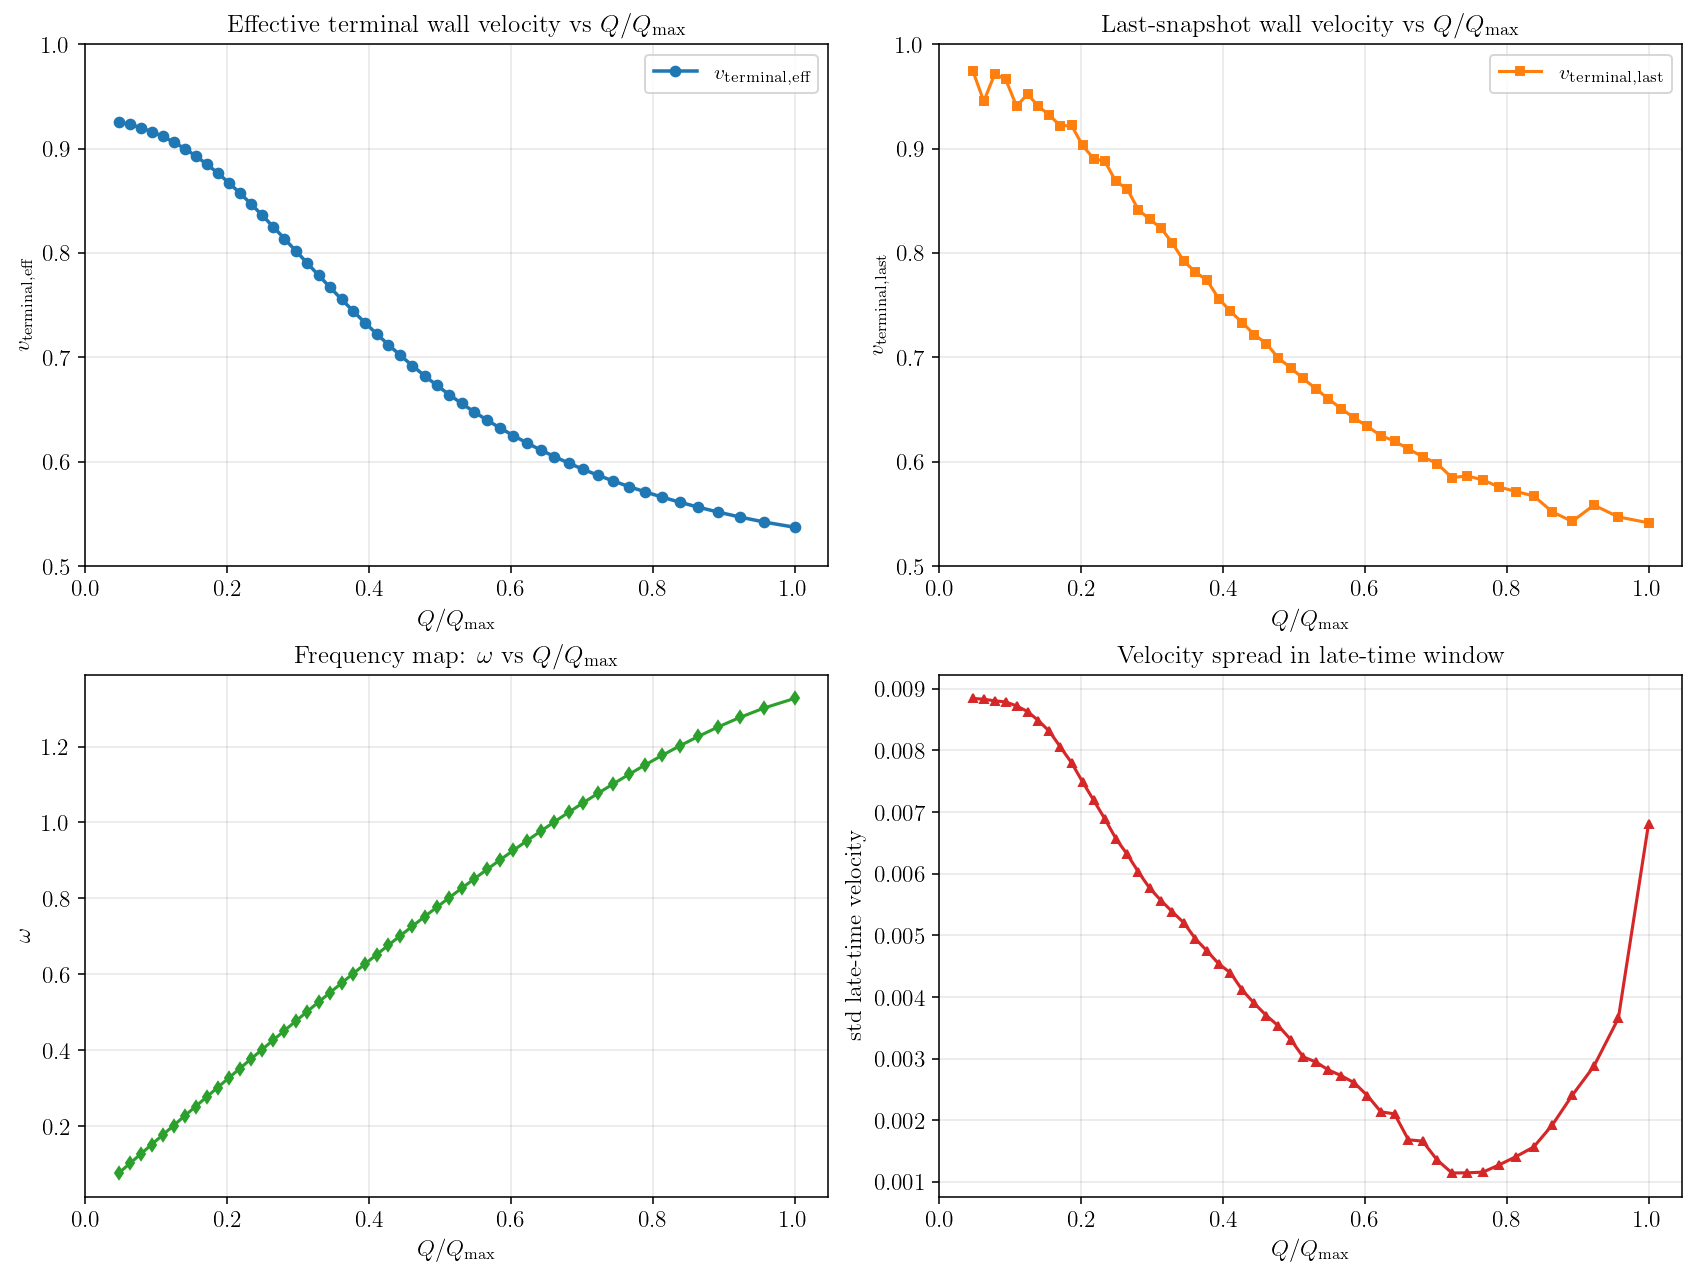

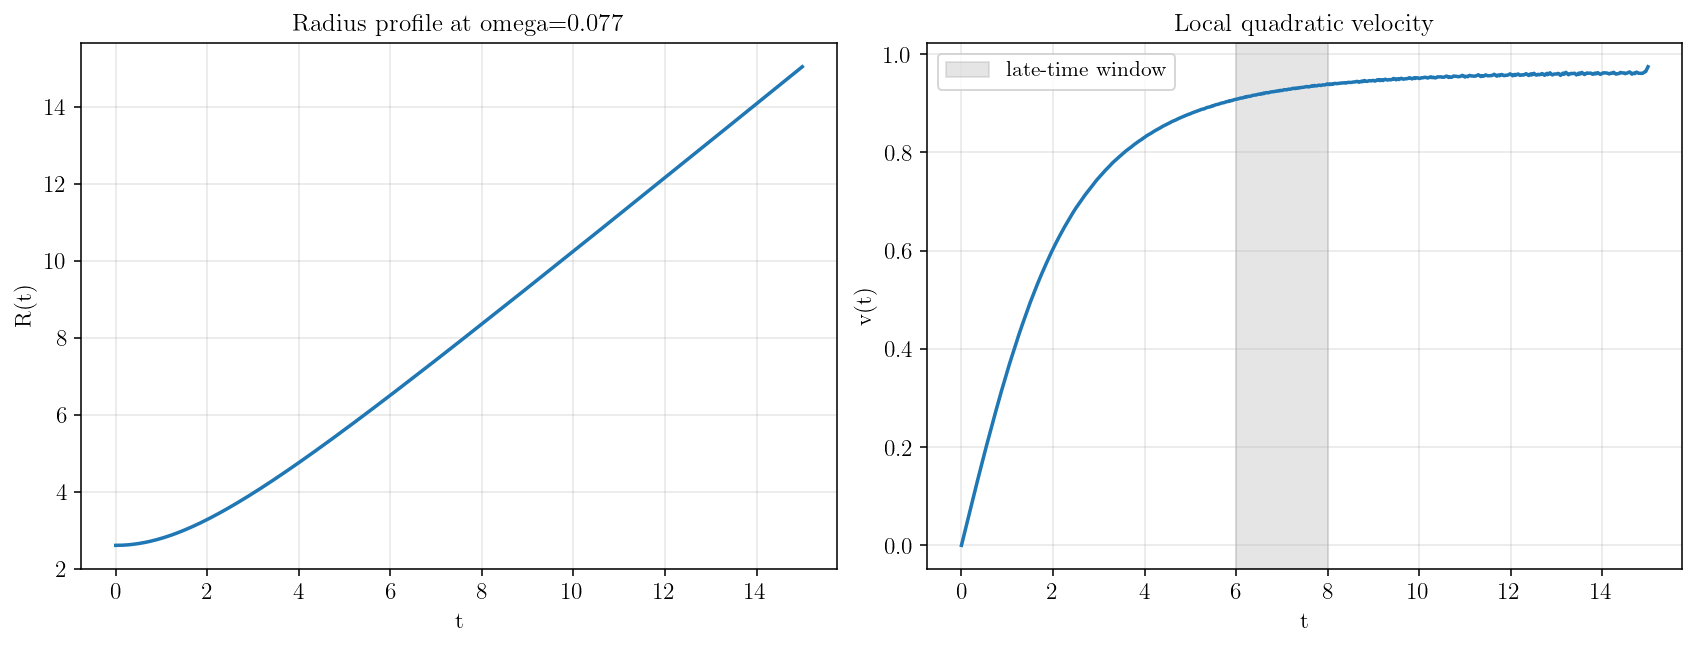

In [46]:
if "scan_terminal_results" in globals() and len(scan_terminal_results) > 0:
    # Plots: v_terminal vs Q/Q_max and scan diagnostics

    if pd is not None and not isinstance(scan_terminal_df, list):
        df_plot = scan_terminal_df.copy()
    else:
        df_plot = pd.DataFrame(scan_terminal_results) if pd is not None else None

    if df_plot is None:
        rows_plot = [r for r in scan_terminal_results]
        q_ratio_plot = np.asarray([_safe_float(r.get("q_ratio", np.nan)) for r in rows_plot], dtype=float)
        v_eff_plot = np.asarray([_safe_float(r.get("v_terminal_eff", np.nan)) for r in rows_plot], dtype=float)
        v_last_plot = np.asarray([_safe_float(r.get("v_terminal_last", np.nan)) for r in rows_plot], dtype=float)
        v_std_plot = np.asarray([_safe_float(r.get("v_terminal_std", np.nan)) for r in rows_plot], dtype=float)
        omega_plot = np.asarray([_safe_float(r.get("omega", np.nan)) for r in rows_plot], dtype=float)
        conv_plot = np.asarray([bool(r.get("converged", False)) for r in rows_plot], dtype=bool)
    else:
        q_ratio_plot = np.asarray(df_plot["q_ratio"], dtype=float)
        v_eff_plot = np.asarray(df_plot["v_terminal_eff"], dtype=float)
        v_last_plot = np.asarray(df_plot["v_terminal_last"], dtype=float)
        v_std_plot = np.asarray(df_plot["v_terminal_std"], dtype=float)
        omega_plot = np.asarray(df_plot["omega"], dtype=float)
        conv_plot = np.asarray(df_plot["converged"], dtype=bool)

    mask_ok = conv_plot & np.isfinite(q_ratio_plot)
    order = np.argsort(q_ratio_plot[mask_ok]) if np.count_nonzero(mask_ok) > 0 else np.array([], dtype=int)

    q_ok = q_ratio_plot[mask_ok][order]
    v_eff_ok = v_eff_plot[mask_ok][order]
    v_last_ok = v_last_plot[mask_ok][order]
    v_std_ok = v_std_plot[mask_ok][order]
    omega_ok = omega_plot[mask_ok][order]

    fig, ax = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

    ax[0, 0].plot(q_ok, v_eff_ok, "o-", lw=1.8, ms=5, label=r"$v_{\mathrm{terminal,eff}}$")
    ax[0, 0].set_xlabel(r"$Q / Q_{\max}$")
    ax[0, 0].set_ylim(0.5, 1)
    ax[0, 0].set_ylabel(r"$v_{\mathrm{terminal,eff}}$")
    ax[0, 0].set_title(r"Effective terminal wall velocity vs $Q/Q_{\max}$")
    ax[0, 0].grid(alpha=0.3)
    ax[0, 0].legend()

    ax[0, 1].plot(q_ok, v_last_ok, "s-", lw=1.6, ms=4.5, color="tab:orange", label=r"$v_{\mathrm{terminal,last}}$")
    ax[0, 1].set_xlabel(r"$Q / Q_{\max}$")
    ax[0, 1].set_ylabel(r"$v_{\mathrm{terminal,last}}$")
    ax[0, 1].set_ylim(0.5, 1)
    ax[0, 1].set_title(r"Last-snapshot wall velocity vs $Q/Q_{\max}$")
    ax[0, 1].grid(alpha=0.3)
    ax[0, 1].legend()

    ax[1, 0].plot(q_ok, omega_ok, "d-", lw=1.6, ms=4.5, color="tab:green")
    ax[1, 0].set_xlabel(r"$Q / Q_{\max}$")
    ax[1, 0].set_ylabel(r"$\omega$")
    ax[1, 0].set_title(r"Frequency map: $\omega$ vs $Q/Q_{\max}$")
    ax[1, 0].grid(alpha=0.3)

    ax[1, 1].plot(q_ok, v_std_ok, "^-", lw=1.6, ms=4.5, color="tab:red")
    ax[1, 1].set_xlabel(r"$Q / Q_{\max}$")
    ax[1, 1].set_ylabel(r"std late-time velocity")
    ax[1, 1].set_title(r"Velocity spread in late-time window")
    ax[1, 1].grid(alpha=0.3)

    plt.show()

    # Optional quick-look plot: R(t) and v(t) for the last successful point
    ok_rows = [r for r in scan_terminal_results if bool(r.get("converged", False))]
    if len(ok_rows) > 0:
        rlast = ok_rows[-1]
        if rlast.get("t_snap") is not None and rlast.get("radius_t") is not None and rlast.get("velocity_t") is not None:
            t_dbg = np.asarray(rlast["t_snap"], dtype=float)
            R_dbg = np.asarray(rlast["radius_t"], dtype=float)
            v_dbg = np.asarray(rlast["velocity_t"], dtype=float)

            fig2, ax2 = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
            ax2[0].plot(t_dbg, R_dbg, "-", lw=1.8)
            ax2[0].set_xlabel("t")
            ax2[0].set_ylabel("R(t)")
            ax2[0].set_title(f"Radius profile at omega={rlast['omega']:.3f}")
            ax2[0].grid(alpha=0.3)

            ax2[1].plot(t_dbg, v_dbg, "-", lw=1.8)
            ax2[1].axvspan(6.0, 8.0, color="gray", alpha=0.2, label="late-time window")
            ax2[1].set_xlabel("t")
            ax2[1].set_ylabel("v(t)")
            ax2[1].set_title("Local quadratic velocity")
            ax2[1].grid(alpha=0.3)
            ax2[1].legend()
            plt.show()
else:
    print('Terminal-velocity scan plots skipped: no scan_terminal_results.')

## Final figures

Velocity-scan summaries and the remaining figure panels for the paper.

# Final figures

The cells below assemble the figure panels from the scan and analysis results computed above.

## Scalar Potential Plot: Two-Branch Construction

This section adds a clean final plot of the scalar potential on the full domain $0\leq\phi\leq2$ by combining:

- branch (1) on $0\leq\phi\leq1$ from the analytic expression with $\phi_{0+}=1-\epsilon$, $\epsilon=10^{-13}$,
- branch (2) on $1\leq\phi\leq2$ reusing the project implementation already used in the workflow.

In the same figure we also plot $\Omega(\phi)$ using the existing project definition, and mark the false/true vacua of branch (2) with vertical lines and markers.

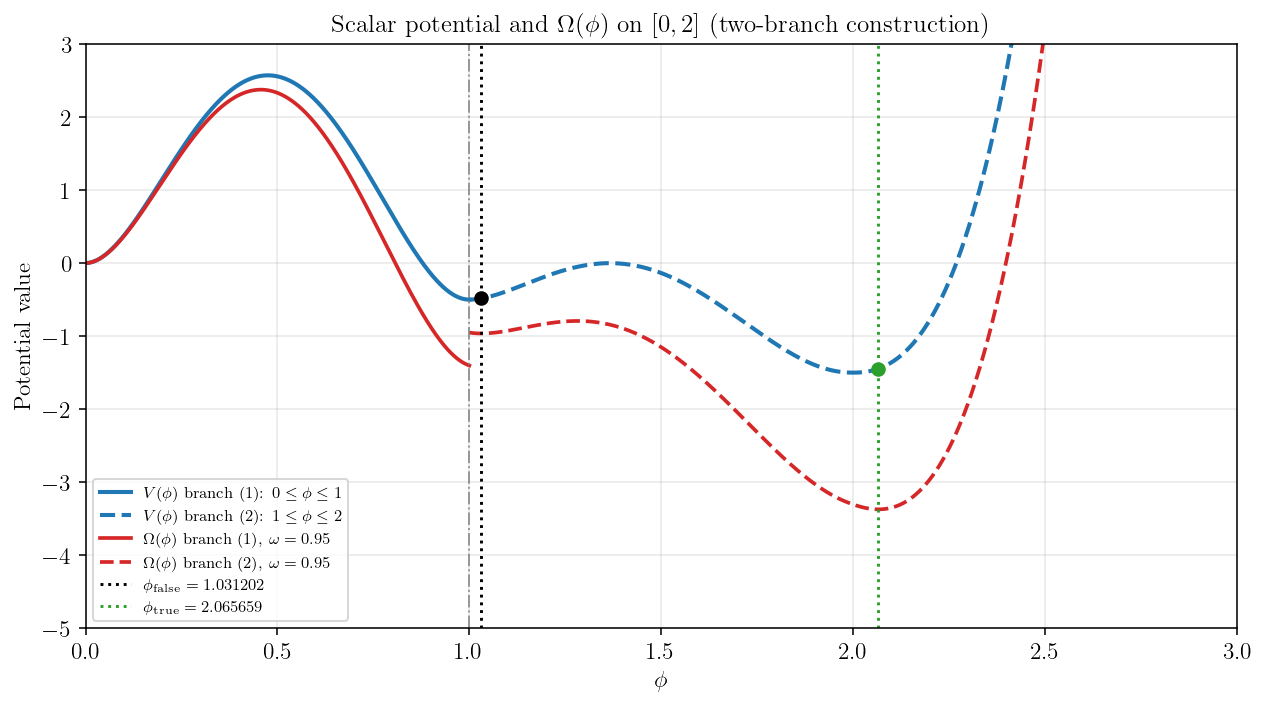

False vacuum (branch 2): phi_false = 1.0312018015
True vacuum  (branch 2): phi_true  = 2.0656590991


In [47]:
if True:
    # Two-branch scalar potential + Omega on a single plot (minimal integration)
    import numpy as np
    import matplotlib.pyplot as plt

    required_symbols = ["MODEL", "V_phi", "Omega_phi", "vacua_of_Omega"]
    missing_symbols = [s for s in required_symbols if s not in globals()]
    if missing_symbols:
        raise RuntimeError(f"Missing required project symbols: {missing_symbols}")

    # Keep project convention for omega used in Omega(phi)
    omega_plot = float(globals().get("OMEGA_REF", 0.95))

    # Numerical safeguards near logarithmic endpoints
    delta_phi = 1e-8
    epsilon = 1e-13
    phi0_plus = 1.0 - epsilon

    # Branch (1): 0 <= phi <= 1 (excluding exact singular endpoints)
    phi_01 = np.linspace(delta_phi, 1.0 - delta_phi, 1600)

    def V1_branch(phi, phi0p):
        phi = np.asarray(phi, dtype=float)
        one_minus = 1.0 - phi
        log_arg = ((1.0 - phi) * phi0p) / np.maximum(phi * (1.0 - phi0p), 1e-300)
        bracket = (2.0 * phi) / 3.0 - 1.0 + (one_minus**2) * np.log(np.maximum(log_arg, 1e-300))
        return 1.5 * (phi**2) * bracket

    V1_vals = V1_branch(phi_01, phi0_plus)
    Omega1_vals = Omega_phi(phi_01, MODEL.phi0, MODEL.v1, MODEL.v2, omega_plot)

    # Branch (2): 1 <= phi <= 2 (reuse existing project implementation)
    phi_12 = np.linspace(1.0 + delta_phi, 2.5 - delta_phi, 1600)
    V2_vals = V_phi(phi_12, MODEL.phi0, MODEL.v1, MODEL.v2)
    Omega2_vals = Omega_phi(phi_12, MODEL.phi0, MODEL.v1, MODEL.v2, omega_plot)

    # Vacua of branch (2) with the existing routine
    phi_false_b2, phi_true_b2 = vacua_of_Omega(MODEL.phi0, MODEL.v1, MODEL.v2, omega_plot, verbose=False)
    phi_false_b2 = float(phi_false_b2)
    phi_true_b2 = float(phi_true_b2)

    # Requested override: for phi < phi_false use branch-1-based Omega definition
    # Omega(phi) = V_branch1(phi) - omega^2 * phi^2
    mask_omega_branch1 = phi_01 < phi_false_b2
    Omega1_vals = np.array(Omega1_vals, copy=True)
    Omega1_vals[mask_omega_branch1] = V1_vals[mask_omega_branch1] - (omega_plot**2) * (phi_01[mask_omega_branch1]**2)

    V_false = float(V_phi(np.array([phi_false_b2]), MODEL.phi0, MODEL.v1, MODEL.v2)[0])
    V_true = float(V_phi(np.array([phi_true_b2]), MODEL.phi0, MODEL.v1, MODEL.v2)[0])

    # Plot everything on one axis, with clear branch styling
    fig, ax = plt.subplots(figsize=(9.2, 5.2))

    # V(phi)
    ax.plot(phi_01, V1_vals, color="C0", lw=2.1, label=r"$V(\phi)$ branch (1): $0\leq\phi\leq1$")
    ax.plot(phi_12, V2_vals, color="C0", lw=2.1, ls="--", label=r"$V(\phi)$ branch (2): $1\leq\phi\leq2$")

    # Omega(phi)
    ax.plot(phi_01, Omega1_vals, color="C3", lw=1.9, label=rf"$\Omega(\phi)$ branch (1), $\omega={omega_plot:.2f}$")
    ax.plot(phi_12, Omega2_vals, color="C3", lw=1.9, ls="--", label=rf"$\Omega(\phi)$ branch (2), $\omega={omega_plot:.2f}$")

    # Vacua markers/lines (branch 2)
    ax.axvline(phi_false_b2, color="k", ls=":", lw=1.5, label=rf"$\phi_{{\rm false}}={phi_false_b2:.6f}$")
    ax.axvline(phi_true_b2, color="C2", ls=":", lw=1.5, label=rf"$\phi_{{\rm true}}={phi_true_b2:.6f}$")
    ax.scatter([phi_false_b2], [V_false], color="k", s=42, zorder=6)
    ax.scatter([phi_true_b2], [V_true], color="C2", s=42, zorder=6)

    # Light visual cue for branch split
    ax.axvline(1.0, color="0.5", ls="-.", lw=1.0, alpha=0.8)

    ax.set_xlim(0.0, 3.0)
    ax.set_ylim(-5, 3)
    ax.set_xlabel(r"$\phi$")
    ax.set_ylabel(r"Potential value")
    ax.set_title(r"Scalar potential and $\Omega(\phi)$ on $[0,2]$ (two-branch construction)")
    ax.grid(alpha=0.28)
    ax.legend(fontsize=8, loc="best")
    fig.tight_layout()

    # Save plot with project-compatible behavior
    out_png = None
    if "CFG" in globals() and CFG.get("save_figures", False):
        out_pdf = CFG["figures_dir"] / "scalar_potential_and_omega.pdf"
        fig.savefig(out_pdf, bbox_inches="tight")

    plt.show()

    print(f"False vacuum (branch 2): phi_false = {phi_false_b2:.10f}")
    print(f"True vacuum  (branch 2): phi_true  = {phi_true_b2:.10f}")
    if out_png is not None:
        print(f"Saved: {out_png}")
else:
    print('cell 145 skipped')

## Effective Potential Branches Colored by $Q_{\mathrm{hom}}/Q_{\max}$

This scan plots the effective scalar potential across many $\omega$ values on the full domain $\phi\in[0,2]$, combining:

- branch (1) on $0\leq\phi\leq1$,
- branch (2) on $1\leq\phi\leq2$ (reusing the existing project implementation).

Each curve is colored by the homogeneous-charge ratio $Q_{\mathrm{hom}}/Q_{\max}$ computed with the same project conventions used elsewhere in the notebook.

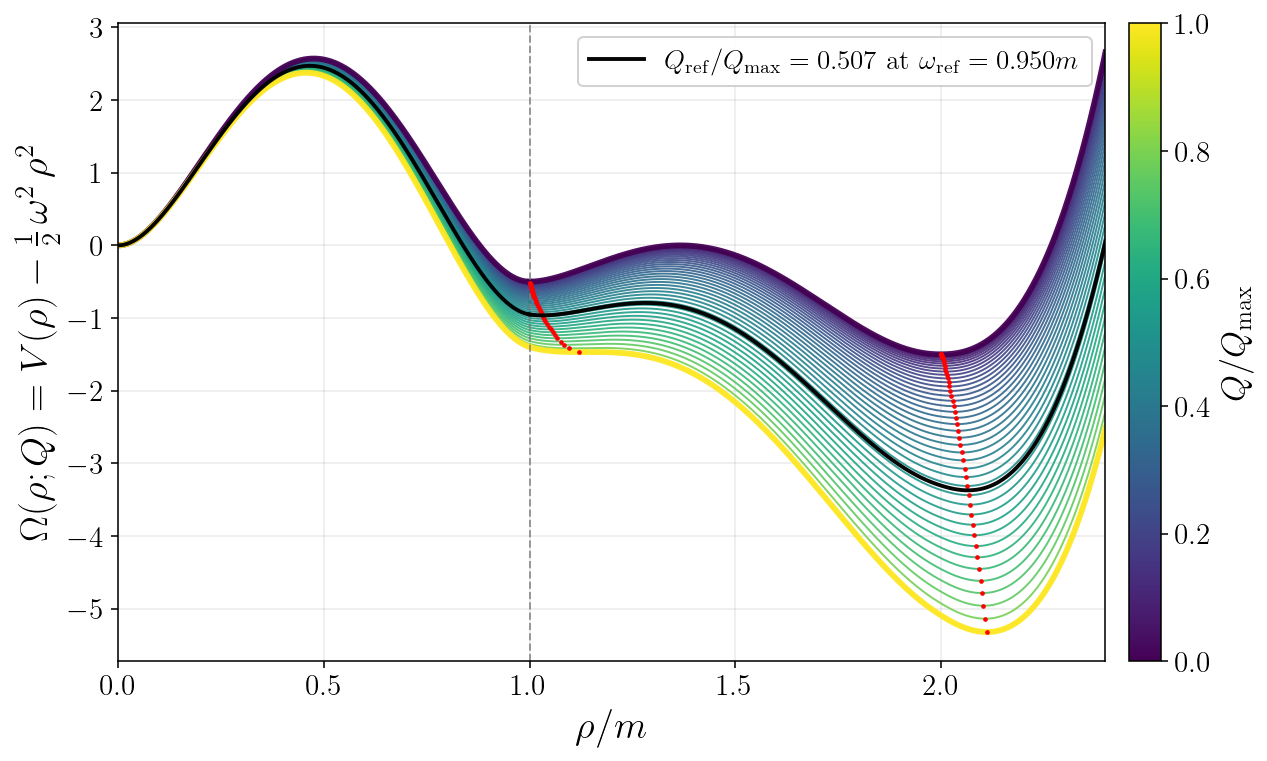

omega_min = 0.00000000
omega_max = 1.34008117
omega bounds source = omega_scan
number of curves plotted = 44
Q_hom/Q_max range = [0.00000000, 1.00000000]
phi_hom range    = [1.00116765, 2.00417014]
Q_max from scan  = 8.35116491e+03
Saved figure: /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/Qubble/Bubble_finder/notebooks/figures/scalar_potential_branches_colored_by_Q.pdf
Special highlighted curve at omega_ref = 0.950000 (exact)


In [48]:
if True:
    # Effective-potential scan in omega, colored by Q_hom/Q_max
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib import cm, colors

    required = ["MODEL", "V_phi", "Omega_phi", "vacua_of_Omega", "compute_targets_tau0_ghost"]
    missing = [k for k in required if k not in globals()]
    if missing:
        raise RuntimeError(f"Missing required symbols: {missing}")

    # ---- omega range (prioritize the dedicated omega scan section) ----
    def _infer_omega_bounds_for_plot():
        # 1) Preferred source: explicit omega scan grid from the scan section
        if "omega_scan" in globals() and len(omega_scan) > 1:
            arr = np.asarray(omega_scan, dtype=float)
            arr = arr[np.isfinite(arr)]
            if arr.size > 1:
                return float(np.min(arr)), float(np.max(arr)), "omega_scan"

        # 2) Next: OMEGA_MAX from estimate_omega_max and corresponding standard range
        if "OMEGA_MAX" in globals() and np.isfinite(float(OMEGA_MAX)):
            return 0.0, float(float(OMEGA_MAX)), "OMEGA_MAX"

        # 3) Fallback: terminal scan bounds
        if "omega_list_terminal" in globals() and len(omega_list_terminal) > 1:
            return float(np.min(omega_list_terminal)), float(np.max(omega_list_terminal)), "omega_list_terminal"

        wmin = float(globals().get("omega_start_scan_terminal", 0.05))
        if "omega_max_scan_terminal" in globals():
            wmax = float(omega_max_scan_terminal)
        elif "_infer_omega_max_for_scan" in globals():
            wmax = float(_infer_omega_max_for_scan())
        else:
            wmax = 1.5
        return wmin, float(wmax), "fallback"

    omega_min_plot, omega_max_plot, omega_bounds_source = _infer_omega_bounds_for_plot()
    if not np.isfinite(omega_min_plot) or not np.isfinite(omega_max_plot) or omega_max_plot <= omega_min_plot:
        raise RuntimeError(f"Invalid omega range: [{omega_min_plot}, {omega_max_plot}]")

    n_omega_plot = 44
    omega_plot_list = np.linspace(omega_min_plot, omega_max_plot, n_omega_plot)

    # ---- phi grids (avoid exact singular endpoints) ----
    delta_phi = 1e-8
    phi_01 = np.linspace(delta_phi, 1.0 - delta_phi, 1000)
    phi_12 = np.linspace(1.0 + delta_phi, 2.4 - delta_phi, 1200)

    # Branch (1) potential requested in previous section
    epsilon = 1e-13
    phi0_plus = 1.0 - epsilon

    def V1_branch(phi, phi0p):
        phi = np.asarray(phi, dtype=float)
        one_minus = 1.0 - phi
        log_arg = ((1.0 - phi) * phi0p) / np.maximum(phi * (1.0 - phi0p), 1e-300)
        bracket = (2.0 * phi) / 3.0 - 1.0 + (one_minus**2) * np.log(np.maximum(log_arg, 1e-300))
        return 1.5 * (phi**2) * bracket

    # ---- helper: reuse existing solver construction if present ----
    def _solver_for_hom_charge(omega_now: float):
        beta_here = float(globals().get("beta_fixed_terminal_scan", CFG_2D["beta"]))
        if "_make_solver_for_omega" in globals():
            return _make_solver_for_omega(float(omega_now), eta0_guess=0.0, beta_fixed=beta_here)

        # Fallback path reusing existing project classes/conventions
        phi_false_now, _ = vacua_of_Omega(MODEL.phi0, MODEL.v1, MODEL.v2, float(omega_now), verbose=False)
        rho0_now = float(phi_false_now / np.sqrt(2.0))
        settings = Bubble2DSettings(
            Nr=CFG_2D["Nr"],
            Ntau=CFG_2D["Ntau"],
            Lr=CFG_2D["Lr"],
            beta=float(beta_here),
            omega_ref=float(omega_now),
            eta0=0.0,
            rho0=float(rho0_now),
            newton_tol=CFG_2D["newton_tol"],
            newton_max_iter=CFG_2D["newton_max_iter"],
            damping=CFG_2D["damping"],
            max_backtracks=CFG_2D["max_backtracks"],
            rho0_bracket=CFG_2D["rho0_bracket"],
            complex_saddle=CFG_2D["complex_saddle"],
            verbose=False,
            tau_bc="twisted",
            r_bc="neumann",
            allow_debug_bcs=False,
        )
        return Bubble2DSolver(settings, U, dU, d2U)


    curves = []
    Q_hom_list = []
    phi_hom_list = []


    def _pick_false_true_minima(phi_grid, veff_grid):
        """Find false/true minima directly from sampled effective branch-2 potential."""
        p = np.asarray(phi_grid, dtype=float)
        v = np.asarray(veff_grid, dtype=float)
        m = np.isfinite(p) & np.isfinite(v)
        p = p[m]
        v = v[m]
        if p.size < 5:
            return np.nan, np.nan, np.nan, np.nan

        idx = np.where((v[1:-1] <= v[:-2]) & (v[1:-1] <= v[2:]))[0] + 1
        if idx.size == 0:
            return np.nan, np.nan, np.nan, np.nan

        i_false = idx[np.argmin(np.abs(p[idx] - 1.0))]
        i_true = idx[np.argmin(np.abs(p[idx] - 2.0))]

        if i_true == i_false and idx.size > 1:
            order = np.argsort(np.abs(p[idx] - 2.0))
            for j in order:
                if idx[j] != i_false:
                    i_true = idx[j]
                    break

        return float(p[i_false]), float(p[i_true]), float(v[i_false]), float(v[i_true])


    for om in omega_plot_list:
        # Potentials on two branches
        V1_vals = V1_branch(phi_01, phi0_plus)
        V2_vals = V_phi(phi_12, MODEL.phi0, MODEL.v1, MODEL.v2)

        # Effective potentials with requested convention: V_eff = V - (1/2) * omega * phi
        Veff1 = V1_vals - 0.5 * om**2 * phi_01**2
        Veff2 = V2_vals - 0.5 * om**2 * phi_12**2

        # False/true minima positions directly from effective branch-2 potential
        phi_false_now, phi_true_now, vf, vt = _pick_false_true_minima(phi_12, Veff2)
        phi_hom_now = phi_false_now

        # Homogeneous charge in existing project convention
        try:
            solver_q = _solver_for_hom_charge(float(om))
            tgt_q = compute_targets_tau0_ghost(solver_q, subtract_background_charge=False)
            Q_hom_now = float(tgt_q["Q"])
        except Exception:
            Q_hom_now = np.nan

        curves.append({
            "omega": float(om),
            "phi1": phi_01,
            "phi2": phi_12,
            "Veff1": Veff1,
            "Veff2": Veff2,
            "phi_hom": phi_hom_now,
            "Q_hom": Q_hom_now,
            "phi_false": phi_false_now,
            "phi_true": phi_true_now,
            "Veff_false": vf,
            "Veff_true": vt,
        })
        Q_hom_list.append(Q_hom_now)
        phi_hom_list.append(phi_hom_now)

    Q_hom_arr = np.asarray(Q_hom_list, dtype=float)
    finite_q = np.isfinite(Q_hom_arr)
    if np.count_nonzero(finite_q) == 0:
        raise RuntimeError("No finite Q_hom values were obtained in the omega scan.")

    Q_max_scan = float(np.nanmax(Q_hom_arr[finite_q]))
    if not np.isfinite(Q_max_scan) or abs(Q_max_scan) < 1e-30:
        raise RuntimeError(f"Invalid Q_max from scan: {Q_max_scan}")

    for c in curves:
        qh = float(c["Q_hom"]) if np.isfinite(c["Q_hom"]) else np.nan
        c["q_norm"] = float(qh / Q_max_scan) if np.isfinite(qh) else np.nan

    # ---- plotting ----
    cmap = cm.get_cmap("viridis")
    norm = colors.Normalize(vmin=float(np.nanmin([c["q_norm"] for c in curves if np.isfinite(c["q_norm"])])),
                            vmax=float(np.nanmax([c["q_norm"] for c in curves if np.isfinite(c["q_norm"])])))

    fig, ax = plt.subplots(figsize=(9.6, 5.6))

    for c in curves:
        if not np.isfinite(c["q_norm"]):
            color = "orange"
            lw = 0.9
            alpha = 0.6
        else:
            color = cmap(norm(c["q_norm"]))
            lw = 1.0
            alpha = 0.9

        ax.plot(c["phi1"], c["Veff1"], color=color, lw=lw, alpha=alpha)
        ax.plot(c["phi2"], c["Veff2"], color=color, lw=lw, alpha=alpha)

    # Highlight representative omegas: min, mid, max (without omega text labels)
    idx_rep = [0, len(curves)-1]
    for idx in idx_rep:
        c = curves[idx]
        color = "k" if not np.isfinite(c["q_norm"]) else cmap(norm(c["q_norm"]))
        ax.plot(c["phi1"], c["Veff1"], color=color, lw=3, alpha=0.95)
        ax.plot(c["phi2"], c["Veff2"], color=color, lw=3, alpha=0.95)

    # Special highlight: curve at exactly omega = OMEGA_REF
    omega_ref_special = float(globals().get("OMEGA_REF", 0.95))
    om_ref = float(omega_ref_special)
    V1_ref = V1_branch(phi_01, phi0_plus)
    V2_ref = V_phi(phi_12, MODEL.phi0, MODEL.v1, MODEL.v2)
    Veff1_ref = V1_ref - 0.5 * om_ref**2 * phi_01**2
    Veff2_ref = V2_ref - 0.5 * om_ref**2 * phi_12**2
    phi_false_ref, phi_true_ref, vf_ref, vt_ref = _pick_false_true_minima(phi_12, Veff2_ref)
    phi_hom_ref = phi_false_ref
    try:
        solver_q_ref = _solver_for_hom_charge(om_ref)
        tgt_q_ref = compute_targets_tau0_ghost(solver_q_ref, subtract_background_charge=False)
        Q_hom_ref = float(tgt_q_ref["Q"])
    except Exception:
        Q_hom_ref = np.nan
    qh_ref = float(Q_hom_ref) if np.isfinite(Q_hom_ref) else np.nan
    q_ref_norm = float(qh_ref / Q_max_scan) if np.isfinite(qh_ref) else np.nan
    c_ref = {
        "omega": om_ref,
        "phi1": phi_01,
        "phi2": phi_12,
        "Veff1": Veff1_ref,
        "Veff2": Veff2_ref,
        "phi_hom": phi_hom_ref,
        "Q_hom": Q_hom_ref,
        "phi_false": phi_false_ref,
        "phi_true": phi_true_ref,
        "Veff_false": vf_ref,
        "Veff_true": vt_ref,
        "q_norm": q_ref_norm,
    }
    if np.isfinite(q_ref_norm):
        ref_label = rf"$Q_{{\rm ref}}/Q_{{\max}}={q_ref_norm:.3f}$ at $\omega_{{\rm ref}}={om_ref:.3f}m$"
    else:
        ref_label = rf"$Q_{{\rm ref}}/Q_{{\max}}=\mathrm{{nan}}$ at $\omega_{{\rm ref}}={om_ref:.3f}m$"

    ax.plot(c_ref["phi1"], c_ref["Veff1"], color="black", lw=2.0, alpha=0.98, zorder=7, label=ref_label)
    ax.plot(c_ref["phi2"], c_ref["Veff2"], color="black", lw=2.0, alpha=0.98, zorder=7)

    # Plot all vacuum points (phi_false and phi_true) as small red markers
    phi_false_pts = np.asarray([c["phi_false"] for c in curves], dtype=float)
    V_false_pts = np.asarray([c["Veff_false"] for c in curves], dtype=float)
    phi_true_pts = np.asarray([c["phi_true"] for c in curves], dtype=float)
    V_true_pts = np.asarray([c["Veff_true"] for c in curves], dtype=float)

    mf = np.isfinite(phi_false_pts) & np.isfinite(V_false_pts)
    mt = np.isfinite(phi_true_pts) & np.isfinite(V_true_pts)

    ax.scatter(phi_false_pts[mf], V_false_pts[mf], s=2, color="red", zorder=6)
    ax.scatter(phi_true_pts[mt], V_true_pts[mt], s=2, color="red", zorder=6)

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r"$Q/Q_{\max}$", fontsize=18)
    cbar.ax.tick_params(labelsize=15)

    ax.axvline(1.0, color="0.5", ls="--", lw=1.0, alpha=0.8)
    ax.set_xlim(0.0, 2.4)
    ax.set_xlabel(r"$\rho/m$", fontsize=20)
    ax.set_ylabel(r"$\Omega(\rho;Q)=V(\rho)-\frac{1}{2}\,\omega^2\,\rho^2$", fontsize=20)
    ax.tick_params(axis="both", labelsize=15)
    #ax.set_title(r"Effective potential branches ( $V-\frac{1}{2}\omega\phi$ ) colored by $Q_{\mathrm{hom}}/Q_{\max}$")
    ax.grid(alpha=0.25)
    ax.legend(loc="best", fontsize=14, framealpha=0.9)
    fig.tight_layout()

    # Save figure (PDF only)
    if "CFG" in globals() and CFG.get("save_figures", False):
        out_path = CFG["figures_dir"] / "scalar_potential_branches_colored_by_Q.pdf"
    else:
        out_path = "scalar_potential_branches_colored_by_Q.pdf"
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()

    # Diagnostics
    phi_hom_arr = np.asarray(phi_hom_list, dtype=float)
    q_norm_arr = np.asarray([c["q_norm"] for c in curves], dtype=float)
    print(f"omega_min = {omega_min_plot:.8f}")
    print(f"omega_max = {omega_max_plot:.8f}")
    print(f"omega bounds source = {omega_bounds_source}")
    print(f"number of curves plotted = {len(curves)}")
    print(f"Q_hom/Q_max range = [{np.nanmin(q_norm_arr):.8f}, {np.nanmax(q_norm_arr):.8f}]")
    print(f"phi_hom range    = [{np.nanmin(phi_hom_arr):.8f}, {np.nanmax(phi_hom_arr):.8f}]")
    print(f"Q_max from scan  = {Q_max_scan:.8e}")
    print(f"Saved figure: {out_path}")
    print(f"Special highlighted curve at omega_ref = {omega_ref_special:.6f} (exact)")
else:
    print('cell 147 skipped')

# Scan plots

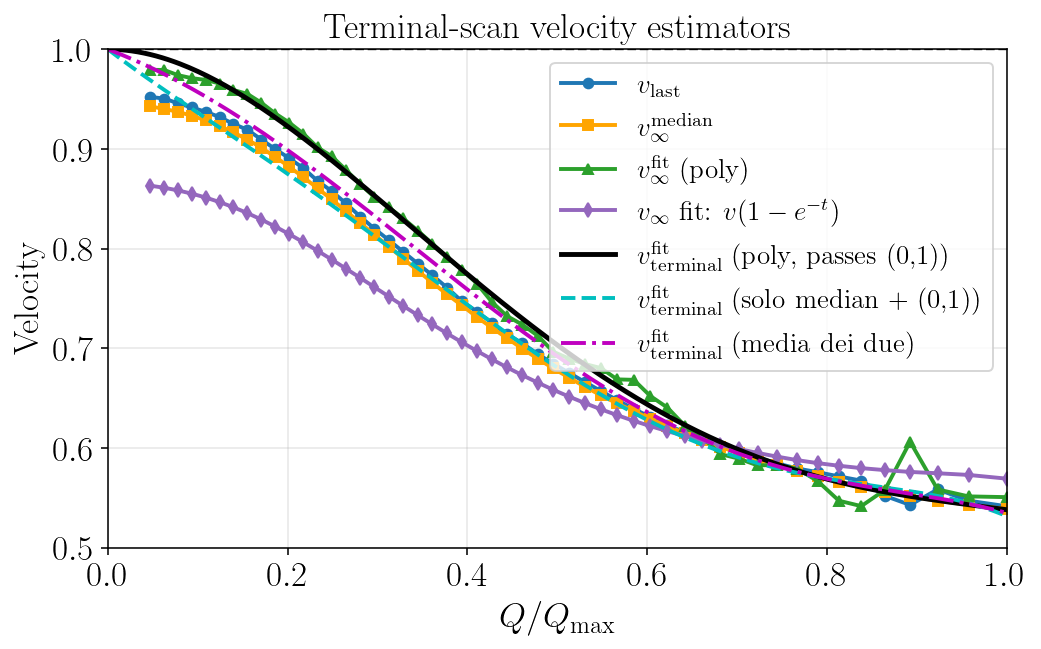

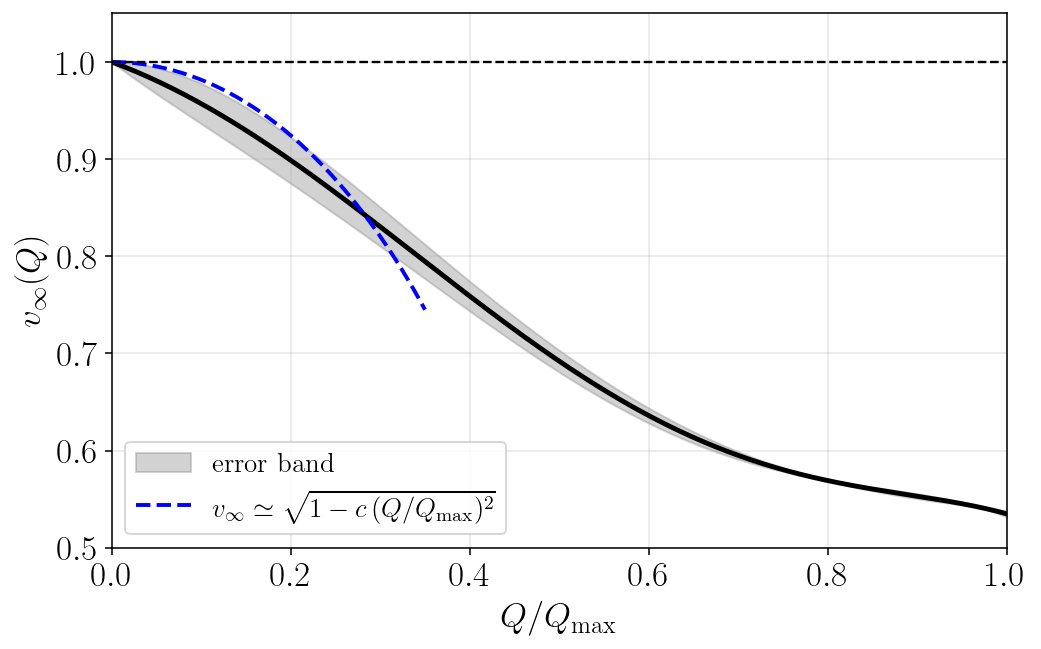

In [49]:
if "scan_terminal_results" in globals() and len(scan_terminal_results) > 0:
    # Velocity scan summary plot: v_last, v_infinity(median), v_infinity(fit), v_inf from v(t)=v_inf*(1-exp(-t))

    import numpy as np
    import matplotlib.pyplot as plt

    if "scan_terminal_results" not in globals() or len(scan_terminal_results) == 0:
        raise RuntimeError("Missing scan_terminal_results. Run the terminal-velocity scan cell first.")

    if "CFG_2D" not in globals() or not isinstance(CFG_2D, dict) or "Lr" not in CFG_2D:
        raise RuntimeError("CFG_2D['Lr'] required (run 2D config cell first).")
    _Lr_vel = float(CFG_2D["Lr"])


    def _tv_within_Lr(t, v):
        """Keep only finite samples with 0 < t < Lr (inside radial box)."""
        t = np.atleast_1d(np.asarray(t, dtype=float)).flatten()
        v = np.atleast_1d(np.asarray(v, dtype=float)).flatten()
        n = min(t.size, v.size)
        m = np.isfinite(t[:n]) & np.isfinite(v[:n]) & (t[:n] > 0.01) & (t[:n] < _Lr_vel)
        return t[:n][m], v[:n][m]


    def _v_last_within_Lr(r):
        raw_t, raw_v = r.get("t_snap", None), r.get("velocity_t", None)
        if raw_t is None or raw_v is None:
            return float(r.get("v_terminal_last", np.nan))
        t, v = _tv_within_Lr(raw_t, raw_v)
        return float(v[-1]) if t.size else np.nan


    def _v_med_late_within_Lr(r, t_late_frac=0.70):
        raw_t, raw_v = r.get("t_snap", None), r.get("velocity_t", None)
        if raw_t is None or raw_v is None:
            return float(r.get("v_infinity_median", np.nan))
        t, v = _tv_within_Lr(raw_t, raw_v)
        if t.size < 6:
            return np.nan
        t_fit_min = max(6.0, t_late_frac * float(np.max(t)))
        fit_mask = t >= t_fit_min
        if np.count_nonzero(fit_mask) < 8:
            n_tail = min(20, t.size)
            v_tail = v[-n_tail:]
        else:
            v_tail = v[fit_mask]
        return float(np.nanmedian(v_tail)) if v_tail.size else np.nan

    # Q and Q_max: use max Q in scan as reference so first point (highest omega) has Q/Q_max = 1
    Q_vals = np.asarray([r.get("Q", np.nan) for r in scan_terminal_results], dtype=float)
    Q_max_plot = float(np.nanmax(Q_vals)) if np.any(np.isfinite(Q_vals)) else np.nan
    q_ratio_vals = np.asarray(
        [float(Q_vals[i] / Q_max_plot) if np.isfinite(Q_max_plot) and abs(Q_max_plot) > 1e-30 and np.isfinite(Q_vals[i]) else np.nan for i in range(len(Q_vals))],
        dtype=float,
    )
    v_last_vals = np.asarray([_v_last_within_Lr(r) for r in scan_terminal_results], dtype=float)
    v_med_vals = np.asarray([_v_med_late_within_Lr(r) for r in scan_terminal_results], dtype=float)

    # Poly fit v(t) = v_inf + a/t + b/t^2, computed here from t_snap, velocity_t (Ridge-stabilized)
    def _fit_vinf_poly(r, t_late_frac=0.70, lam=1e-6):
        raw_t = r.get("t_snap", None)
        raw_v = r.get("velocity_t", None)
        if raw_t is None or raw_v is None:
            return np.nan
        t, v = _tv_within_Lr(raw_t, raw_v)
        if t.size < 6:
            return np.nan
        t_good = t
        v_good = v
        t_fit_min = max(6.0, t_late_frac * float(np.max(t_good)))
        fit_mask = t_good >= t_fit_min
        if np.count_nonzero(fit_mask) < 8:
            n_tail = min(20, t_good.size)
            idx = np.arange(t_good.size - n_tail, t_good.size)
            t_fit, v_fit = t_good[idx], v_good[idx]
        else:
            t_fit, v_fit = t_good[fit_mask], v_good[fit_mask]
        if t_fit.size < 3 or np.unique(t_fit).size < 3:
            return np.nan
        u = 1.0 / t_fit
        X = np.column_stack([np.ones_like(t_fit), u, u**2])
        L = np.array([[0.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]])
        try:
            coef = np.linalg.solve(X.T @ X + lam * L, X.T @ v_fit)
            v_inf = float(coef[0])
            v_min, v_max = float(np.nanmin(v_fit)), float(np.nanmax(v_fit))
            if v_inf < v_min - 0.1 or v_inf > v_max + 0.1:
                v_inf = float(np.clip(v_inf, v_min, v_max))
            return v_inf
        except np.linalg.LinAlgError:
            return float(np.nanmedian(v_fit))

    v_fit_vals = np.array([_fit_vinf_poly(r) for r in scan_terminal_results], dtype=float)

    # Fit: v(t) = v_inf * (1 - exp(-t)). Least-squares v_inf = sum(v*x)/sum(x^2) with x = 1-exp(-t).
    def _fit_vinf_1mexp(r):
        raw_t = r.get("t_snap", None)
        raw_v = r.get("velocity_t", None)
        if raw_t is None or raw_v is None:
            return np.nan
        t, v = _tv_within_Lr(raw_t, raw_v)
        if t.size < 3:
            return np.nan
        x = 1.0 - np.exp(-t)
        y = v
        denom = np.sum(x**2)
        if denom < 1e-20:
            return np.nan
        return float(np.sum(y * x) / denom)

    v_fit_exp_vals = np.array([_fit_vinf_1mexp(r) for r in scan_terminal_results], dtype=float)

    order = np.argsort(q_ratio_vals)
    q_ratio_vals = q_ratio_vals[order]
    v_last_vals = v_last_vals[order]
    v_med_vals = v_med_vals[order]
    v_fit_vals = v_fit_vals[order]
    v_fit_exp_vals = v_fit_exp_vals[order]

    # v_terminal: median for Q/Q_max > 0.65, poly fit for Q/Q_max <= 0.65 (excluding 3 points at ~0.02, 0.05, 0.07), plus (0, 1)
    q_cut = 0.65
    mask_med = (q_ratio_vals > q_cut) & np.isfinite(v_med_vals)
    idx_poly = np.where((q_ratio_vals <= q_cut) & np.isfinite(v_fit_vals))[0]
    # Exclude only the 2 poly points with smallest q_ratio (~0.02, 0.05); keep the one at ~0.07
    idx_poly_keep = idx_poly[2:] if len(idx_poly) > 2 else idx_poly
    q_terminal = np.concatenate([
        q_ratio_vals[mask_med],
        q_ratio_vals[idx_poly_keep],
        [0.0],
    ])
    v_terminal = np.concatenate([
        v_med_vals[mask_med],
        v_fit_vals[idx_poly_keep],
        [1.0],
    ])
    # Sort by q_ratio ascending
    sort_t = np.argsort(q_terminal)
    q_terminal = q_terminal[sort_t]
    v_terminal = v_terminal[sort_t]

    # Polynomial fit v(q) = 1 - (a1*q + a2*q^2 + ...) so v(0)=1 and v <= 1 (like median curve)
    # Fit (1 - v) to polynomial in q; then v_terminal_fit = 1 - poly(q)
    poly_deg = 5
    q_pts = np.asarray(q_terminal, dtype=float)
    v_pts = np.asarray(v_terminal, dtype=float)
    n_pts = len(q_pts)
    if n_pts >= poly_deg + 1:
        # Fit 1 - v = a1*q + a2*q^2 + ... (no constant)
        X = np.column_stack([q_pts**k for k in range(1, poly_deg + 1)])
        y = 1.0 - v_pts
        coef, *_ = np.linalg.lstsq(X, y, rcond=None)
        q_terminal_fit = np.linspace(0.0, 1.0, 300)
        v_terminal_fit = 1.0 - sum(coef[k - 1] * q_terminal_fit**k for k in range(1, poly_deg + 1))
        v_terminal_fit = np.clip(v_terminal_fit, 0.0, 1.0)
    else:
        q_terminal_fit = np.linspace(0.0, 1.0, 300)
        v_terminal_fit = np.clip(np.interp(q_terminal_fit, q_pts, v_pts), 0.0, 1.0)

    # Second fit: only median points + (0, 1), same model v(q) = 1 - (a1*q + ...)
    m_med = np.isfinite(q_ratio_vals) & np.isfinite(v_med_vals)
    q_med_pts = np.concatenate([[0.0], q_ratio_vals[m_med]])
    v_med_pts = np.concatenate([[1.0], v_med_vals[m_med]])
    n_med = len(q_med_pts)
    if n_med >= poly_deg + 1:
        X_med = np.column_stack([q_med_pts**k for k in range(1, poly_deg + 1)])
        y_med = 1.0 - v_med_pts
        coef_med, *_ = np.linalg.lstsq(X_med, y_med, rcond=None)
        q_terminal_median_fit = np.linspace(0.0, 1.0, 300)
        v_terminal_median_fit = 1.0 - sum(coef_med[k - 1] * q_terminal_median_fit**k for k in range(1, poly_deg + 1))
        v_terminal_median_fit = np.clip(v_terminal_median_fit, 0.0, 1.0)
    else:
        q_terminal_median_fit = np.linspace(0.0, 1.0, 300)
        v_terminal_median_fit = np.clip(np.interp(q_terminal_median_fit, q_med_pts, v_med_pts), 0.0, 1.0)

    fig, ax = plt.subplots(figsize=(7.6, 4.8))

    m_last = np.isfinite(q_ratio_vals) & np.isfinite(v_last_vals)
    m_med = np.isfinite(q_ratio_vals) & np.isfinite(v_med_vals)
    m_fit = np.isfinite(q_ratio_vals) & np.isfinite(v_fit_vals)
    m_fit_exp = np.isfinite(q_ratio_vals) & np.isfinite(v_fit_exp_vals)

    if np.count_nonzero(m_last) > 0:
        ax.plot(q_ratio_vals[m_last], v_last_vals[m_last], "o-", lw=2.0, ms=5, color="tab:blue", label=r"$v_{\mathrm{last}}$")
    if np.count_nonzero(m_med) > 0:
        ax.plot(q_ratio_vals[m_med], v_med_vals[m_med], "s-", lw=2.0, ms=5, color="orange", label=r"$v_{\infty}^{\mathrm{median}}$")
    if np.count_nonzero(m_fit) > 0:
        ax.plot(q_ratio_vals[m_fit], v_fit_vals[m_fit], "^-", lw=2.0, ms=5, color="tab:green", label=r"$v_{\infty}^{\mathrm{fit}}$ (poly)")
    if np.count_nonzero(m_fit_exp) > 0:
        ax.plot(q_ratio_vals[m_fit_exp], v_fit_exp_vals[m_fit_exp], "d-", lw=2.0, ms=5, color="tab:purple", label=r"$v_{\infty}$ fit: $v(1-e^{-t})$")
    if len(q_terminal_fit) > 0:
        ax.plot(q_terminal_fit, v_terminal_fit, "k-", lw=2.5, label=r"$v_{\mathrm{terminal}}^{\mathrm{fit}}$ (poly, passes (0,1))")
    if len(q_terminal_median_fit) > 0:
        ax.plot(q_terminal_median_fit, v_terminal_median_fit, "c--", lw=2.0, label=r"$v_{\mathrm{terminal}}^{\mathrm{fit}}$ (solo median + (0,1))")
    # Media dei due fit
    if len(q_terminal_fit) == len(q_terminal_median_fit) and len(q_terminal_fit) > 0:
        v_terminal_fit_avg = 0.5 * (v_terminal_fit + v_terminal_median_fit)
        ax.plot(q_terminal_fit, v_terminal_fit_avg, "m-.", lw=2.0, label=r"$v_{\mathrm{terminal}}^{\mathrm{fit}}$ (media dei due)")

    ax.axhline(1.0, color="k", ls="--", lw=1.2)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.5, 1.0)
    ax.set_xlabel(r"$Q/Q_{\max}$", fontsize=18)
    ax.set_ylabel(r"Velocity", fontsize=18)
    ax.set_title("Terminal-scan velocity estimators", fontsize=18)
    ax.tick_params(axis="both", labelsize=18)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=14)

    fig.tight_layout()
    if "CFG" in globals() and isinstance(CFG, dict) and CFG.get("save_figures", False):
        fig.savefig(CFG["figures_dir"] / "omega_scan_velocity_estimators.pdf", bbox_inches="tight")

    plt.show()

    # Fit small-Q formula for q = Q/Q_max <= 0.3: v ≃ sqrt(1 - c*q^2)
    q_small_max = 0.35
    q_eps = 0.02
    mask_small = (q_terminal_fit > q_eps) & (q_terminal_fit <= q_small_max) & np.isfinite(v_terminal_fit_avg)
    if np.count_nonzero(mask_small) >= 3:
        q_fit = q_terminal_fit[mask_small]
        v_fit = v_terminal_fit_avg[mask_small]
        y_fit = 1.0 - v_fit**2
        x_fit2 = q_fit**2
        c_smallQ2 = np.sum(x_fit2 * y_fit) / (np.sum(x_fit2**2) + 1e-20)
        c_smallQ2 = np.clip(c_smallQ2, 0.0, 1e6)
        q_small_plot = np.linspace(0.0, q_small_max, 200)
        v_smallQ2_plot = np.sqrt(np.clip(1.0 - c_smallQ2 * q_small_plot**2, 0.0, 1.0))
    else:
        c_smallQ2 = np.nan
        q_small_plot = np.array([0.0])
        v_smallQ2_plot = np.array([1.0])

    # Second plot: only the average curve with continuous error band (poly = upper, solo median = lower)
    fig2, ax2 = plt.subplots(figsize=(7.6, 4.8))
    if len(q_terminal_fit) == len(v_terminal_median_fit) and len(q_terminal_fit) > 0:
        # Banda: limite basso = fit solo median, limite alto = fit poly
        ax2.fill_between(q_terminal_fit, v_terminal_median_fit, v_terminal_fit, color="gray", alpha=0.35, label="error band")
        ax2.plot(q_terminal_fit, v_terminal_fit_avg, "k-", lw=2.5)#, label=r"$v_{\mathrm{terminal}}^{\mathrm{fit}}$ (media)")
    if np.isfinite(c_smallQ2):
        ax2.plot(q_small_plot, v_smallQ2_plot, "b--", lw=2.0, label=r"$v_\infty \simeq \sqrt{1-c\,(Q/Q_{\max})^2}$")
    ax2.axhline(1.0, color="k", ls="--", lw=1.2)
    ax2.set_xlim(0.0, 1.0)
    ax2.set_ylim(0.5, 1.05)
    ax2.set_xlabel(r"$Q/Q_{\max}$", fontsize=18)
    ax2.set_ylabel(r"$v_\infty(Q)$", fontsize=18)
    #ax2.set_title("Terminal velocity fit (media) con banda di incertezza", fontsize=18)
    ax2.tick_params(axis="both", labelsize=18)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc="best", fontsize=14)
    fig2.tight_layout()
    if "CFG" in globals() and isinstance(CFG, dict) and CFG.get("save_figures", False):
        fig2.savefig(CFG["figures_dir"] / "omega_scan_velocity_terminal_fit_band.pdf", bbox_inches="tight")
    plt.show()
else:
    print('Analysis cell 161 skipped: required cached data not loaded.')

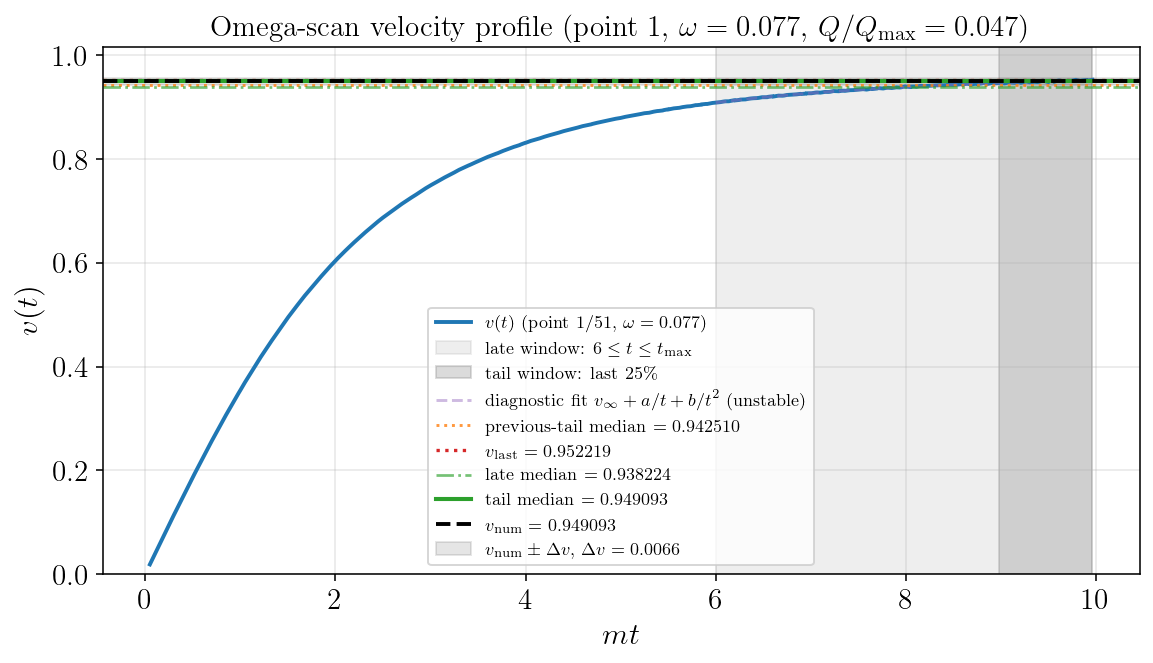

[velocity-profile tail-robust diagnostics]
point                  = 1/51
omega                  = 7.66803598e-02
Q                      = 2.57012058e+03
Q/Qmax                 = 4.71642036e-02
Lr cut                 = 10.0
domain t range         = [0.050000, 9.961400]
late window            = [6.000000, 9.961400]
tail window            = [8.976900, 9.961400]
n_domain               = 371
n_late                 = 149
n_tail                 = 38

[tail estimate]
v_last                 = 9.52218695e-01
v_late_median          = 9.38224330e-01
v_late_mean            = 9.35553335e-01
v_late_std             = 1.22991558e-02
v_tail_median          = 9.49092688e-01
v_tail_mean            = 9.49052584e-01
v_tail_std             = 1.85962103e-03
v_tail_mad             = 2.19842971e-03
v_prev_tail_median     = 9.42510383e-01
v_tail_drift           = 6.58230479e-03
v_last_offset          = 3.12600754e-03
v_num                  = 9.49092688e-01
dv_num                 = 6.58230479e-03

[diagnostic asy

In [50]:
if "scan_terminal_results" in globals() and len(scan_terminal_results) > 0:
    # ============================================================
    # Tail-robust omega-scan velocity profile for one scan point
    #
    # Broad late-time window:
    #   6 <= t <= t_max
    # after the domain cut:
    #   t < Lr
    #
    # Central estimate:
    #   v_num = median[v(t)] in the final tail of the late-time window
    #
    # Tail window:
    #   last TAIL_FRACTION of the broad late-time window
    #
    # Error estimate:
    #   dv_num = max[
    #       std[v(t)] in tail,
    #       robust MAD estimate in tail,
    #       |median(tail) - median(previous tail)|,
    #       |v_last - median(tail)|
    #   ]
    #
    # The asymptotic fit
    #   v(t) = v_inf + a/t + b/t^2
    # is diagnostic only. It is not used for v_num or dv_num.
    # ============================================================

    import numpy as np
    import matplotlib.pyplot as plt

    # =========================
    # choose scan point
    # =========================
    SCAN_POINT_NUMBER = 1  # 1-based index among converged points sorted by omega

    # =========================
    # extraction settings
    # =========================
    T_LATE_MIN = 6.0

    MIN_LATE_POINTS = 5
    MIN_TAIL_POINTS = 5
    MIN_FIT_POINTS = 5

    TAIL_FRACTION = 0.25
    USE_LAST_IN_ERROR = True

    FIT_RIDGE_LAMBDA = 1e-6
    FIT_ABS_TOL = 0.02
    FIT_NSIGMA_TOL = 3.0
    FIT_RANGE_PAD = 0.03

    SHOW_FIT_DIAGNOSTIC = True
    SHOW_UNSTABLE_FIT_HLINE = False
    SHOW_STORED_VALUES = False

    ZOOM_TO_TAIL_PLATEAU = False
    SAVE_FIG = False

    # =========================
    # checks
    # =========================
    if "scan_terminal_results" not in globals() or len(scan_terminal_results) == 0:
        raise RuntimeError("scan_terminal_results is missing/empty. Run or load the terminal scan first.")

    rows_ok = [r for r in scan_terminal_results if bool(r.get("converged", False))]
    if len(rows_ok) == 0:
        raise RuntimeError("No converged scan points available for velocity-profile plotting.")

    rows_ok = sorted(rows_ok, key=lambda r: float(r.get("omega", np.nan)))

    iscan = int(SCAN_POINT_NUMBER) - 1
    if iscan < 0 or iscan >= len(rows_ok):
        raise IndexError(
            f"SCAN_POINT_NUMBER={SCAN_POINT_NUMBER} out of range: "
            f"{len(rows_ok)} converged point(s), use 1..{len(rows_ok)}."
        )

    r0 = rows_ok[iscan]

    omega0 = float(r0.get("omega", np.nan))
    Q0 = float(r0.get("Q", np.nan))
    Qmax0 = float(r0.get("Q_max", np.nan))
    qratio0 = float(r0.get("q_ratio", np.nan))

    if not np.isfinite(qratio0):
        Q_all = np.asarray([float(r.get("Q", np.nan)) for r in rows_ok], dtype=float)
        Qmax_plot = float(np.nanmax(Q_all)) if np.any(np.isfinite(Q_all)) else np.nan
        if np.isfinite(Q0) and np.isfinite(Qmax_plot) and abs(Qmax_plot) > 1e-30:
            qratio0 = Q0 / Qmax_plot

    tv0_raw = r0.get("t_snap", None)
    v0_raw = r0.get("velocity_t", None)

    if tv0_raw is None or v0_raw is None:
        raise RuntimeError(f"Missing t_snap/velocity_t for scan point {SCAN_POINT_NUMBER}.")

    tv0 = np.asarray(tv0_raw, dtype=float).flatten()
    v0 = np.asarray(v0_raw, dtype=float).flatten()

    if tv0.size == 0 or v0.size == 0:
        raise RuntimeError(f"Empty t_snap/velocity_t for scan point {SCAN_POINT_NUMBER}.")

    n = min(tv0.size, v0.size)
    tv0 = tv0[:n]
    v0 = v0[:n]

    # =========================
    # domain cut
    # =========================
    mask = np.isfinite(tv0) & np.isfinite(v0) & (tv0 > 0.01)

    if "CFG_2D" in globals() and isinstance(CFG_2D, dict) and "Lr" in CFG_2D:
        Lr_here = float(CFG_2D["Lr"])
        mask &= tv0 < Lr_here
    else:
        Lr_here = np.nan

    if np.count_nonzero(mask) == 0:
        raise RuntimeError(f"No finite in-domain points for scan point {SCAN_POINT_NUMBER}.")

    t_dom = tv0[mask]
    v_dom = v0[mask]

    order = np.argsort(t_dom)
    t_dom = t_dom[order]
    v_dom = v_dom[order]

    # =========================
    # broad late-time window: 6 <= t <= tmax
    # =========================
    late_mask = np.isfinite(t_dom) & np.isfinite(v_dom) & (t_dom >= T_LATE_MIN)

    t_late = t_dom[late_mask]
    v_late = v_dom[late_mask]

    if t_late.size < MIN_LATE_POINTS:
        raise RuntimeError(
            f"Too few points in broad late window t >= {T_LATE_MIN}: "
            f"{t_late.size} point(s)."
        )

    tmax_used = float(np.nanmax(t_dom))
    tlate_min_used = float(np.nanmin(t_late))
    tlate_max_used = float(np.nanmax(t_late))

    # =========================
    # final tail window
    # =========================
    n_late = int(v_late.size)
    n_tail = max(MIN_TAIL_POINTS, int(np.ceil(TAIL_FRACTION * n_late)))
    n_tail = min(n_tail, n_late)

    t_tail = t_late[-n_tail:]
    v_tail = v_late[-n_tail:]

    if t_tail.size < MIN_TAIL_POINTS:
        raise RuntimeError(
            f"Too few points in tail window: {t_tail.size} point(s). "
            f"Need at least {MIN_TAIL_POINTS}."
        )

    ttail_min_used = float(np.nanmin(t_tail))
    ttail_max_used = float(np.nanmax(t_tail))

    # Previous tail segment, used only to estimate drift.
    if n_late >= 2 * n_tail:
        t_prev_tail = t_late[-2 * n_tail : -n_tail]
        v_prev_tail = v_late[-2 * n_tail : -n_tail]
    else:
        t_prev_tail = t_late[: n_late - n_tail]
        v_prev_tail = v_late[: n_late - n_tail]

    # =========================
    # robust tail estimators
    # =========================
    v_last = float(v_dom[-1])

    v_late_median = float(np.nanmedian(v_late))
    v_late_mean = float(np.nanmean(v_late))
    v_late_std = float(np.nanstd(v_late))

    v_tail_median = float(np.nanmedian(v_tail))
    v_tail_mean = float(np.nanmean(v_tail))
    v_tail_std = float(np.nanstd(v_tail))

    tail_mad = float(np.nanmedian(np.abs(v_tail - v_tail_median)))
    v_tail_mad = 1.4826 * tail_mad

    if v_prev_tail.size >= MIN_TAIL_POINTS:
        v_prev_tail_median = float(np.nanmedian(v_prev_tail))
        v_tail_drift = abs(v_tail_median - v_prev_tail_median)
    else:
        v_prev_tail_median = np.nan
        v_tail_drift = 0.0

    v_last_offset = abs(v_last - v_tail_median)

    # Central value: robust final-tail median.
    v_num = v_tail_median

    err_components = [
        v_tail_std,
        v_tail_mad,
        v_tail_drift,
    ]

    if USE_LAST_IN_ERROR:
        err_components.append(v_last_offset)

    dv_num = float(
        np.nanmax(
            [
                np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
                for x in err_components
            ]
        )
    )

    # =========================
    # diagnostic asymptotic fit only
    # =========================
    v_fit = np.nan
    v_fit_rms = np.nan
    fit_coef = None
    v_fit_curve_late = None
    fit_unstable = True
    fit_reason = "not fitted"

    if t_late.size >= MIN_FIT_POINTS and np.unique(t_late).size >= 3:
        u_late = 1.0 / t_late
        X_late = np.column_stack([np.ones_like(t_late), u_late, u_late**2])

        # Ridge only on a/t and b/t^2, not on v_inf.
        L = np.array(
            [
                [0.0, 0.0, 0.0],
                [0.0, 1.0, 0.0],
                [0.0, 0.0, 1.0],
            ]
        )

        try:
            fit_coef = np.linalg.solve(
                X_late.T @ X_late + FIT_RIDGE_LAMBDA * L,
                X_late.T @ v_late,
            )

            v_fit = float(fit_coef[0])
            v_fit_curve_late = X_late @ fit_coef
            v_fit_rms = float(np.sqrt(np.nanmean((v_late - v_fit_curve_late)**2)))

            v_min_late = float(np.nanmin(v_late))
            v_max_late = float(np.nanmax(v_late))

            fit_offset_tail = abs(v_fit - v_tail_median)
            fit_offset_late = abs(v_fit - v_late_median)

            plateau_tol = max(
                FIT_ABS_TOL,
                FIT_NSIGMA_TOL * max(v_tail_std, v_tail_mad, v_fit_rms, 1e-12),
            )

            outside_tail_band = fit_offset_tail > plateau_tol
            outside_late_range = (
                (v_fit < v_min_late - FIT_RANGE_PAD)
                or
                (v_fit > v_max_late + FIT_RANGE_PAD)
            )

            if outside_tail_band or outside_late_range:
                fit_unstable = True

                reasons = []
                if outside_tail_band:
                    reasons.append(
                        f"|fit-tail|={fit_offset_tail:.4g} > tol={plateau_tol:.4g}"
                    )
                if outside_late_range:
                    reasons.append(
                        f"fit outside late range [{v_min_late:.4g},{v_max_late:.4g}] by pad {FIT_RANGE_PAD:.4g}"
                    )
                fit_reason = "; ".join(reasons)
            else:
                fit_unstable = False
                fit_reason = "stable"

        except np.linalg.LinAlgError:
            fit_unstable = True
            fit_reason = "linear solve failed"
            fit_coef = None
            v_fit = np.nan
            v_fit_rms = np.nan
            v_fit_curve_late = None

    else:
        fit_unstable = True
        fit_reason = (
            f"too few late points for fit: n_late={t_late.size}, "
            f"unique={np.unique(t_late).size}"
        )

    # =========================
    # stored values for comparison/debug
    # =========================
    v_eff_stored = float(r0.get("v_terminal_eff", np.nan))
    v_last_stored = float(r0.get("v_terminal_last", np.nan))
    v_med_stored = float(r0.get("v_infinity_median", np.nan))
    v_fit_stored = float(r0.get("v_infinity_fit", np.nan))
    v_std_stored = float(r0.get("v_terminal_std", np.nan))
    v_fit_rms_stored = float(r0.get("v_infinity_fit_rms", np.nan))

    # =========================
    # plot
    # =========================
    fig, ax = plt.subplots(figsize=(8.4, 4.9))

    ax.plot(
        t_dom,
        v_dom,
        color="tab:blue",
        lw=2.0,
        label=rf"$v(t)$ (point {SCAN_POINT_NUMBER}/{len(rows_ok)}, $\omega={omega0:.3f}$)",
    )

    # Broad late window.
    ax.axvspan(
        tlate_min_used,
        tlate_max_used,
        color="gray",
        alpha=0.13,
        label=rf"late window: ${T_LATE_MIN:g}\leq t\leq t_{{\max}}$",
    )

    # Actual tail window used for v_num.
    ax.axvspan(
        ttail_min_used,
        ttail_max_used,
        color="gray",
        alpha=0.28,
        label=rf"tail window: last {100*TAIL_FRACTION:.0f}\%",
    )

    # Diagnostic fit curve only inside the broad late window.
    if SHOW_FIT_DIAGNOSTIC and v_fit_curve_late is not None:
        ax.plot(
            t_late,
            v_fit_curve_late,
            color="tab:purple",
            ls="--" if fit_unstable else "-",
            lw=1.5,
            alpha=0.45 if fit_unstable else 0.80,
            label=(
                rf"diagnostic fit $v_\infty+a/t+b/t^2$"
                + (" (unstable)" if fit_unstable else "")
            ),
        )

    # Previous tail median, if available.
    if np.isfinite(v_prev_tail_median):
        ax.axhline(
            v_prev_tail_median,
            color="tab:orange",
            ls=":",
            lw=1.5,
            alpha=0.8,
            label=rf"previous-tail median $={v_prev_tail_median:.6f}$",
        )

    ax.axhline(
        v_last,
        color="tab:red",
        ls=":",
        lw=1.7,
        label=rf"$v_{{\rm last}}={v_last:.6f}$",
    )

    ax.axhline(
        v_late_median,
        color="tab:green",
        ls="-.",
        lw=1.4,
        alpha=0.65,
        label=rf"late median $={v_late_median:.6f}$",
    )

    ax.axhline(
        v_tail_median,
        color="tab:green",
        ls="-",
        lw=2.1,
        label=rf"tail median $={v_tail_median:.6f}$",
    )

    if SHOW_FIT_DIAGNOSTIC and np.isfinite(v_fit) and (SHOW_UNSTABLE_FIT_HLINE or not fit_unstable):
        ax.axhline(
            v_fit,
            color="tab:purple",
            ls="--" if fit_unstable else "-",
            lw=1.5,
            alpha=0.50 if fit_unstable else 0.90,
            label=rf"$v_\infty^{{\rm fit}}={v_fit:.6f}$"
            + (" unstable" if fit_unstable else ""),
        )

    ax.axhline(
        v_num,
        color="k",
        ls="--",
        lw=2.0,
        label=rf"$v_{{\rm num}}={v_num:.6f}$",
    )

    if np.isfinite(dv_num) and dv_num > 0:
        ax.axhspan(
            v_num - dv_num,
            v_num + dv_num,
            color="k",
            alpha=0.10,
            label=rf"$v_{{\rm num}}\pm\Delta v$, $\Delta v={dv_num:.4f}$",
        )

    if SHOW_STORED_VALUES:
        if np.isfinite(v_eff_stored):
            ax.axhline(
                v_eff_stored,
                color="tab:orange",
                ls="--",
                lw=1.0,
                alpha=0.55,
                label=rf"stored $v_{{\rm terminal,eff}}={v_eff_stored:.6f}$",
            )

        if np.isfinite(v_med_stored):
            ax.axhline(
                v_med_stored,
                color="tab:green",
                ls=":",
                lw=1.0,
                alpha=0.55,
                label=rf"stored $v_\infty^{{\rm median}}={v_med_stored:.6f}$",
            )

        if np.isfinite(v_fit_stored):
            ax.axhline(
                v_fit_stored,
                color="tab:purple",
                ls=":",
                lw=1.0,
                alpha=0.55,
                label=rf"stored $v_\infty^{{\rm fit}}={v_fit_stored:.6f}$",
            )

    ax.set_xlabel(r"$mt$", fontsize=16)
    ax.set_ylabel(r"$v(t)$", fontsize=16)

    title_extra = ""
    if np.isfinite(qratio0):
        title_extra = rf", $Q/Q_{{\max}}={qratio0:.3f}$"

    ax.set_title(
        rf"Omega-scan velocity profile "
        rf"(point {SCAN_POINT_NUMBER}, $\omega={omega0:.3f}${title_extra})",
        fontsize=15,
    )

    ax.tick_params(axis="both", labelsize=15)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=9.1)

    # Stable y-axis selection.
    if ZOOM_TO_TAIL_PLATEAU:
        y_ref = np.concatenate(
            [
                np.asarray(v_tail, dtype=float),
                np.asarray([v_num - dv_num, v_num + dv_num], dtype=float),
            ]
        )
    else:
        y_ref = np.concatenate(
            [
                np.asarray(v_dom, dtype=float),
                np.asarray([v_num - dv_num, v_num + dv_num], dtype=float),
            ]
        )

    y_ref = y_ref[np.isfinite(y_ref)]

    if y_ref.size > 0:
        y_min = max(0.0, float(np.nanmin(y_ref)) - 0.06)
        y_max = min(1.05, float(np.nanmax(y_ref)) + 0.06)
        if y_max - y_min > 0.10:
            ax.set_ylim(y_min, y_max)

    fig.tight_layout()

    if SAVE_FIG or ("CFG" in globals() and isinstance(CFG, dict) and CFG.get("save_figures", False)):
        fig.savefig(
            CFG["figures_dir"] / f"scanpoint_{SCAN_POINT_NUMBER:02d}_velocity_profile_tail_robust.pdf",
            bbox_inches="tight",
        )

    plt.show()

    # =========================
    # diagnostics
    # =========================
    print("[velocity-profile tail-robust diagnostics]")
    print(f"point                  = {SCAN_POINT_NUMBER}/{len(rows_ok)}")
    print(f"omega                  = {omega0:.8e}")
    print(f"Q                      = {Q0:.8e}")
    print(f"Q/Qmax                 = {qratio0:.8e}")
    print(f"Lr cut                 = {Lr_here}")
    print(f"domain t range         = [{np.nanmin(t_dom):.6f}, {np.nanmax(t_dom):.6f}]")
    print(f"late window            = [{tlate_min_used:.6f}, {tlate_max_used:.6f}]")
    print(f"tail window            = [{ttail_min_used:.6f}, {ttail_max_used:.6f}]")
    print(f"n_domain               = {t_dom.size}")
    print(f"n_late                 = {t_late.size}")
    print(f"n_tail                 = {t_tail.size}")
    print("")
    print("[tail estimate]")
    print(f"v_last                 = {v_last:.8e}")
    print(f"v_late_median          = {v_late_median:.8e}")
    print(f"v_late_mean            = {v_late_mean:.8e}")
    print(f"v_late_std             = {v_late_std:.8e}")
    print(f"v_tail_median          = {v_tail_median:.8e}")
    print(f"v_tail_mean            = {v_tail_mean:.8e}")
    print(f"v_tail_std             = {v_tail_std:.8e}")
    print(f"v_tail_mad             = {v_tail_mad:.8e}")
    print(f"v_prev_tail_median     = {v_prev_tail_median:.8e}")
    print(f"v_tail_drift           = {v_tail_drift:.8e}")
    print(f"v_last_offset          = {v_last_offset:.8e}")
    print(f"v_num                  = {v_num:.8e}")
    print(f"dv_num                 = {dv_num:.8e}")
    print("")
    print("[diagnostic asymptotic fit]")
    print(f"v_fit                  = {v_fit:.8e}")
    print(f"v_fit_rms              = {v_fit_rms:.8e}")
    print(f"fit_unstable           = {fit_unstable}")
    print(f"fit_reason             = {fit_reason}")
    print("")
    print("[stored in scan row]")
    print(f"v_terminal_eff         = {v_eff_stored:.8e}")
    print(f"v_terminal_last        = {v_last_stored:.8e}")
    print(f"v_infinity_median      = {v_med_stored:.8e}")
    print(f"v_infinity_fit         = {v_fit_stored:.8e}")
    print(f"v_terminal_std         = {v_std_stored:.8e}")
    print(f"v_infinity_fit_rms     = {v_fit_rms_stored:.8e}")
    print("")
    print("Definitions:")
    print("  broad late window = 6 <= t <= t_max")
    print("  tail window       = final TAIL_FRACTION of the broad late window")
    print("  v_num             = median[v(t)] in tail window")
    print("  dv_num            = max[std_tail, MAD_tail, tail_drift, last_offset]")
    print("  fit               = diagnostic only; it is not used for v_num or dv_num")
else:
    print('Analysis cell 162 skipped: required cached data not loaded.')

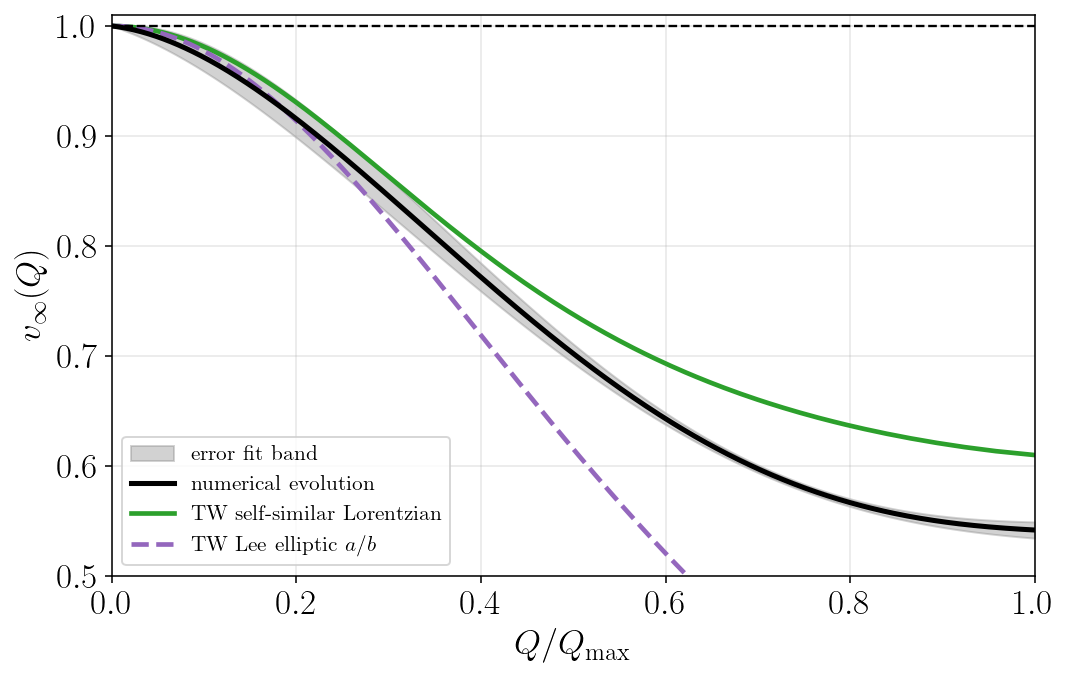

[single-panel global-fit diagnostics]
broad late-time window    = [6.000, t_max] after t < Lr
tail window fraction      = 0.250
fit used up to            = Q/Qmax <= 0.650, if stable
global polynomial degree  = 4
vacua source              = vacua_of_Omega(MODEL, omega=0)
rho_i, rho_f              = 1.00000002e+00, 1.99986461e+00
eps_i, eps_f, Deps        = 1.00000004e+00, 3.99945846e+00, 2.99945842e+00
D                         = 6.99945857e+00
DeltaV                    = 1.00000002e+00
Q_max_plot                = 5.44930347e+04
USE_ETA0_IN_TW            = False
ETA0_SIGN_IN_OMEGA_R      = +1.0
beta_for_eta              = 10.0
LEE_USE_RATIO             = True
Omega nodes range         = [0.00000000e+00, 1.32668036e+00]
v_tail range              = [5.36914633e-01, 9.49092688e-01]
v_fit range               = [5.79353748e-01, 9.72614987e-01]
v_used range              = [5.36914633e-01, 9.72614987e-01]
dv_used range             = [0.00000000e+00, 1.62294889e-02]
fit stable count          =

In [51]:
if "scan_terminal_results" in globals() and len(scan_terminal_results) > 0:
    # ============================================================
    # Terminal velocity plot + TW predictions:
    #
    #   1. Numerical black curve:
    #        global degree-4 anchored fit to the chosen numerical estimator
    #
    #   2. Gray uncertainty band:
    #        global degree-4 anchored fits to chosen estimator +/- error
    #
    #   3. TW diagnostics:
    #        - Wick-force diagnostic
    #        - Lorentzian self-similar shell
    #        - Lee elliptic continuation, v_Lee = a/b
    #
    # Numerical estimator used for the black curve:
    #
    #   if Q/Qmax <= Q_USE_FIT_MAX and fit is stable:
    #       v_used = v_fit
    #   else:
    #       v_used = v_tail
    #
    # No individual points are plotted.
    # No small-Q blue curve is plotted.
    # No lower residual panel is plotted.
    #
    # Requires:
    #   scan_terminal_results
    #   CFG_2D["Lr"]
    #   U
    #
    # Optional:
    #   beta_fixed_terminal_scan
    #   eta0 stored in scan_terminal_results
    #   rho_false_0, rho_true_0 or col_thin/col_thick/MODEL
    # ============================================================

    import numpy as np
    import matplotlib.pyplot as plt

    # =========================
    # switches
    # =========================
    USE_ETA0_IN_TW = False
    ETA0_SIGN_IN_OMEGA_R = +1.0

    # Red TW Wick-rotated curve (tab:red). Set True to show it.
    PLOT_TW_WICK_FORCE = False
    PLOT_TW_SELFSIMILAR = True
    PLOT_TW_LEE_ELLIPTIC = True

    # If True, use v_Lee = a/b = (1+u)/(1+v).
    # If False, use the strictly expanded result v_Lee = 1 + u - v.
    LEE_USE_RATIO = True

    T_LATE_MIN = 6.0
    TAIL_FRACTION = 0.25

    MIN_LATE_POINTS = 5
    MIN_TAIL_POINTS = 5
    MIN_FIT_POINTS = 5

    USE_LAST_IN_ERROR = True

    # Fit extraction in time
    FIT_RIDGE_LAMBDA = 1e-6
    FIT_RMS_ABS_TOL = 0.010
    FIT_RMS_REL_TOL = 0.030
    FIT_PHYS_MIN = 0.0
    FIT_PHYS_MAX = 1.02

    # Use v_fit only at low Q if stable.
    Q_USE_FIT_MAX = 0.65

    # If a fit point is used, include its spread from the tail estimator
    # as part of the uncertainty.
    FIT_TAIL_SPREAD_FACTOR = 0.50

    # Global curve fit in Q/Qmax
    POLY_DEG = 4
    N_FIT_GRID = 500
    N_TW_GRID = 500

    SAVE_FIG = True
    OUTNAME = "omega_scan_velocity_global_deg4_band_with_TW_and_Lee.pdf"


    # =========================
    # basic checks
    # =========================
    if "scan_terminal_results" not in globals() or len(scan_terminal_results) == 0:
        raise RuntimeError("Missing scan_terminal_results. Run/load the terminal-velocity scan first.")

    if "CFG_2D" not in globals() or not isinstance(CFG_2D, dict) or "Lr" not in CFG_2D:
        raise RuntimeError("CFG_2D['Lr'] required.")

    if "U" not in globals():
        raise RuntimeError("Missing potential U.")

    _Lr_vel = float(CFG_2D["Lr"])


    # =========================
    # helpers
    # =========================
    def _safe_float_plot(x, default=np.nan):
        try:
            arr = np.asarray(x)
            if arr.size == 1:
                return float(arr.ravel()[0])
        except Exception:
            pass

        try:
            return float(x)
        except Exception:
            return float(default)


    def _nan_range(x):
        x = np.asarray(x, dtype=float)
        if not np.any(np.isfinite(x)):
            return "[nan, nan]"
        return f"[{np.nanmin(x):.8e}, {np.nanmax(x):.8e}]"


    def _tv_within_Lr(t, v):
        """Keep only finite samples with 0 < t < Lr."""
        t = np.atleast_1d(np.asarray(t, dtype=float)).flatten()
        v = np.atleast_1d(np.asarray(v, dtype=float)).flatten()

        n = min(t.size, v.size)

        m = (
            np.isfinite(t[:n])
            & np.isfinite(v[:n])
            & (t[:n] > 0.01)
            & (t[:n] < _Lr_vel)
        )

        return t[:n][m], v[:n][m]


    def _late_window_from_6_to_max(t, v):
        """
        Broad late-time window:
            6 <= t <= tmax
        after t < Lr has already been applied.
        """
        t = np.asarray(t, dtype=float)
        v = np.asarray(v, dtype=float)

        m = np.isfinite(t) & np.isfinite(v) & (t >= T_LATE_MIN)

        return t[m], v[m]


    def _tail_from_late_window(t_late, v_late):
        """
        Final tail window:
            final TAIL_FRACTION of the broad late-time window.
        """
        t_late = np.asarray(t_late, dtype=float)
        v_late = np.asarray(v_late, dtype=float)

        n_late = int(v_late.size)
        n_tail = max(MIN_TAIL_POINTS, int(np.ceil(TAIL_FRACTION * n_late)))
        n_tail = min(n_tail, n_late)

        t_tail = t_late[-n_tail:]
        v_tail = v_late[-n_tail:]

        if n_late >= 2 * n_tail:
            t_prev_tail = t_late[-2 * n_tail : -n_tail]
            v_prev_tail = v_late[-2 * n_tail : -n_tail]
        else:
            t_prev_tail = t_late[: n_late - n_tail]
            v_prev_tail = v_late[: n_late - n_tail]

        return t_tail, v_tail, t_prev_tail, v_prev_tail


    def _tail_stats_for_row(r):
        """
        Tail estimator:
            v_tail = median[v(t)] in the final tail.

        Tail uncertainty:
            tail_err = max[std_tail, MAD_tail, tail_drift, last_offset].
        """
        raw_t = r.get("t_snap", None)
        raw_v = r.get("velocity_t", None)

        out = {
            "ok": False,
            "n_late": 0,
            "n_tail": 0,
            "v_tail": np.nan,
            "tail_err": np.nan,
            "v_tail_std": np.nan,
            "v_tail_mad": np.nan,
            "v_tail_drift": np.nan,
            "v_last_offset": np.nan,
        }

        if raw_t is None or raw_v is None:
            return out

        t, v = _tv_within_Lr(raw_t, raw_v)
        t_late, v_late = _late_window_from_6_to_max(t, v)

        if v_late.size < MIN_LATE_POINTS:
            out["n_late"] = int(v_late.size)
            return out

        t_tail, v_tail, t_prev_tail, v_prev_tail = _tail_from_late_window(t_late, v_late)

        if v_tail.size < MIN_TAIL_POINTS:
            out["n_late"] = int(v_late.size)
            out["n_tail"] = int(v_tail.size)
            return out

        v_last = float(v[-1])

        v_tail_med = float(np.nanmedian(v_tail))
        v_tail_std = float(np.nanstd(v_tail))

        tail_mad = float(np.nanmedian(np.abs(v_tail - v_tail_med)))
        v_tail_mad = 1.4826 * tail_mad

        if v_prev_tail.size >= MIN_TAIL_POINTS:
            v_prev_tail_med = float(np.nanmedian(v_prev_tail))
            v_tail_drift = abs(v_tail_med - v_prev_tail_med)
        else:
            v_tail_drift = 0.0

        v_last_offset = abs(v_last - v_tail_med)

        err_components = [
            v_tail_std,
            v_tail_mad,
            v_tail_drift,
        ]

        if USE_LAST_IN_ERROR:
            err_components.append(v_last_offset)

        tail_err = float(
            np.nanmax(
                [
                    np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
                    for x in err_components
                ]
            )
        )

        out.update(
            {
                "ok": True,
                "n_late": int(v_late.size),
                "n_tail": int(v_tail.size),
                "v_tail": v_tail_med,
                "tail_err": tail_err,
                "v_tail_std": v_tail_std,
                "v_tail_mad": v_tail_mad,
                "v_tail_drift": v_tail_drift,
                "v_last_offset": v_last_offset,
            }
        )

        return out


    def _fit_stats_for_row(r):
        """
        Fit:
            v(t) = v_inf + a/t + b/t^2
        on the broad late-time window.

        The fit is accepted if:
          - v_fit is finite and physical,
          - fit_rms is small.

        We do not reject v_fit just because it lies outside the observed
        late-time range, because for small Q it is an extrapolation.
        """
        raw_t = r.get("t_snap", None)
        raw_v = r.get("velocity_t", None)

        out = {
            "v_fit": np.nan,
            "v_fit_rms": np.nan,
            "fit_stable": False,
            "fit_reason": "not fitted",
        }

        if raw_t is None or raw_v is None:
            return out

        t, v = _tv_within_Lr(raw_t, raw_v)
        t_late, v_late = _late_window_from_6_to_max(t, v)

        if t_late.size < MIN_FIT_POINTS or np.unique(t_late).size < 3:
            out["fit_reason"] = (
                f"too few late points for fit: n_late={t_late.size}, "
                f"unique={np.unique(t_late).size}"
            )
            return out

        u = 1.0 / t_late

        X = np.column_stack(
            [
                np.ones_like(t_late),
                u,
                u**2,
            ]
        )

        # Ridge only on a/t and b/t^2, not on v_inf.
        L = np.array(
            [
                [0.0, 0.0, 0.0],
                [0.0, 1.0, 0.0],
                [0.0, 0.0, 1.0],
            ]
        )

        try:
            coef = np.linalg.solve(
                X.T @ X + FIT_RIDGE_LAMBDA * L,
                X.T @ v_late,
            )

            v_fit = float(coef[0])
            v_fit_curve = X @ coef
            v_fit_rms = float(np.sqrt(np.nanmean((v_late - v_fit_curve) ** 2)))

            v_scale = max(abs(float(np.nanmedian(v_late))), 1e-12)

            physical = (
                np.isfinite(v_fit)
                and (FIT_PHYS_MIN <= v_fit <= FIT_PHYS_MAX)
            )

            rms_ok = (
                np.isfinite(v_fit_rms)
                and (v_fit_rms <= max(FIT_RMS_ABS_TOL, FIT_RMS_REL_TOL * v_scale))
            )

            reasons = []
            if not physical:
                reasons.append(f"non-physical v_fit={v_fit:.4g}")
            if not rms_ok:
                reasons.append(f"fit_rms={v_fit_rms:.4g} too large")

            out["v_fit"] = v_fit
            out["v_fit_rms"] = v_fit_rms
            out["fit_stable"] = bool(physical and rms_ok)
            out["fit_reason"] = "stable" if out["fit_stable"] else "; ".join(reasons)

            return out

        except np.linalg.LinAlgError:
            out["fit_reason"] = "linear solve failed"
            return out


    def _unique_xy_mean(x, y):
        """
        Remove duplicate x values by averaging y at equal rounded x.
        """
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)

        m = np.isfinite(x) & np.isfinite(y)

        x = x[m]
        y = y[m]

        if x.size == 0:
            return x, y

        order = np.argsort(x)

        x = x[order]
        y = y[order]

        xr = np.round(x, 12)
        xu = np.unique(xr)

        x_out = []
        y_out = []

        for xv in xu:
            mm = xr == xv
            x_out.append(float(vx) if False else float(xv))
            y_out.append(float(np.nanmean(y[mm])))

        return np.asarray(x_out, dtype=float), np.asarray(y_out, dtype=float)


    def _global_deg4_fit(q, v, q_grid, deg=4):
        """
        Anchored global polynomial fit:
            v(q) = 1 - sum_{k=1}^{deg} a_k q^k

        This enforces v(0)=1.
        """
        q = np.asarray(q, dtype=float)
        v = np.asarray(v, dtype=float)

        q, v = _unique_xy_mean(q, v)

        m = np.isfinite(q) & np.isfinite(v) & (q >= 0.0) & (q <= 1.05)

        q = q[m]
        v = v[m]

        # Ensure the neutral anchor appears exactly once.
        has_zero = np.any(np.isclose(q, 0.0, atol=1e-14))

        if not has_zero:
            q = np.concatenate([[0.0], q])
            v = np.concatenate([[1.0], v])
        else:
            # Force exact neutral value.
            iz = np.argmin(np.abs(q))
            v[iz] = 1.0

        order = np.argsort(q)

        q = q[order]
        v = v[order]

        if q.size >= deg + 1:
            X = np.column_stack([q**k for k in range(1, deg + 1)])
            y = 1.0 - v
            coef, *_ = np.linalg.lstsq(X, y, rcond=None)

            v_grid = 1.0 - sum(
                coef[k - 1] * q_grid**k
                for k in range(1, deg + 1)
            )
        else:
            v_grid = np.interp(q_grid, q, v)

        return np.asarray(v_grid, dtype=float)


    def _U_scalar(phi):
        return float(np.asarray(U(np.array([float(phi)], dtype=float))).flat[0])


    def _infer_zero_charge_vacua():
        """
        Return rho_i, rho_f.

        Convention:
          rho_i = false/initial vacuum
          rho_f = true/final vacuum
        """
        if "rho_false_0" in globals() and "rho_true_0" in globals():
            return float(rho_false_0), float(rho_true_0), "rho_false_0/rho_true_0"

        for name in ("col_thin", "col_thick", "col"):
            if name in globals():
                c = globals()[name]
                if isinstance(c, dict):
                    if "rho_false_0" in c and "rho_true_0" in c:
                        return float(c["rho_false_0"]), float(c["rho_true_0"]), name
                    if "rho_i" in c and "rho_f" in c:
                        return float(c["rho_i"]), float(c["rho_f"]), name

        if "MODEL" in globals():
            try:
                from Bubble_finder.potential_bubble import vacua_of_Omega

                rf, rt = vacua_of_Omega(
                    float(MODEL.phi0),
                    float(MODEL.v1),
                    float(MODEL.v2),
                    0.0,
                    verbose=False,
                )

                return float(rf), float(rt), "vacua_of_Omega(MODEL, omega=0)"

            except Exception as exc:
                raise RuntimeError(
                    "Could not infer zero-charge vacua from MODEL. "
                    "Define rho_false_0 and rho_true_0 explicitly."
                ) from exc

        raise RuntimeError(
            "Could not infer zero-charge vacua. Define rho_false_0 and rho_true_0."
        )


    # =========================
    # TW helper functions
    # =========================
    def _AB_of_Omega(Omega_arr, eps_i, eps_f):
        Omega_arr = np.asarray(Omega_arr, dtype=float)

        Deps = eps_f - eps_i
        D = eps_f + 3.0 * eps_i

        pref = (
            (8.0 / 5.0)
            * eps_i
            * Omega_arr**2
            * Deps
            / D**2
        )

        A = pref * (2.0 * eps_f + 3.0 * eps_i)
        B = pref * (3.0 * Deps)

        return A, B


    def _tw_velocity_wick_force(Omega_arr, eps_i, eps_f, DeltaV):
        """
        Wick-force diagnostic.

        Literal continuation:
            s^2 -> - gamma^2 v^2 = - v^2/(1-v^2)

        Therefore:
            delta_Wick(v) = A - B v^2/(1-v^2)

        Force-balance diagnostic:
            DeltaV + delta_Wick(v) = 0

        This gives:
            v^2 = (DeltaV + A)/(DeltaV + A + B)
        """
        Omega_arr = np.asarray(Omega_arr, dtype=float)

        A, B = _AB_of_Omega(Omega_arr, eps_i, eps_f)

        v_out = np.full_like(Omega_arr, np.nan, dtype=float)

        num = DeltaV + A
        den = DeltaV + A + B

        good = (
            np.isfinite(num)
            & np.isfinite(den)
            & (den > 0.0)
        )

        v2 = np.full_like(Omega_arr, np.nan, dtype=float)
        v2[good] = num[good] / den[good]

        physical = good & np.isfinite(v2) & (v2 >= 0.0) & (v2 <= 1.0)

        v_out[physical] = np.sqrt(v2[physical])

        return v_out


    def _tw_velocity_lee_elliptic(Omega_arr, eps_i, eps_f, DeltaV, use_ratio=True):
        """
        Lee elliptic-continuation estimate.

        From the O(epsilon^2) ellipsoid around R_Q:
            a = R_Q (1 + u)
            b = R_Q (1 + v)

        with:
            u = -(6/5) A_Q
            v = +(18/5) A_Q

        where:
            A_Q = eps_i * Omega_R^2 * (eps_f - eps_i)^2
                  / [DeltaV * (eps_f + 3 eps_i)^2]

        The Wick continuation of the ellipsoid gives:
            v_Lee = a/b.

        If use_ratio=True:
            v_Lee = (1 + u)/(1 + v)
        If use_ratio=False:
            v_Lee = 1 + u - v = 1 - (24/5) A_Q
        """
        Omega_arr = np.asarray(Omega_arr, dtype=float)

        v_out = np.full_like(Omega_arr, np.nan, dtype=float)

        if not np.isfinite(DeltaV) or DeltaV <= 0.0:
            return v_out

        Deps = eps_f - eps_i
        D = eps_f + 3.0 * eps_i

        if not np.isfinite(D) or abs(D) < 1e-300:
            return v_out

        A_Q = (
            eps_i
            * Omega_arr**2
            * Deps**2
            / (DeltaV * D**2)
        )

        u = -(6.0 / 5.0) * A_Q
        v = +(18.0 / 5.0) * A_Q

        if use_ratio:
            den = 1.0 + v
            good = np.isfinite(A_Q) & np.isfinite(den) & (np.abs(den) > 1e-300)
            v_lee = np.full_like(Omega_arr, np.nan, dtype=float)
            v_lee[good] = (1.0 + u[good]) / den[good]
        else:
            good = np.isfinite(A_Q)
            v_lee = np.full_like(Omega_arr, np.nan, dtype=float)
            v_lee[good] = 1.0 + u[good] - v[good]

        physical = np.isfinite(v_lee) & (v_lee >= 0.0) & (v_lee <= 1.0)

        v_out[physical] = v_lee[physical]

        return v_out


    def _selfsimilar_Ealpha_coeff(v, Omega, eps_i, eps_f):
        """
        Lorentzian self-similar phase-energy coefficient:
            E_alpha^M = 4*pi*t^3*Ecoeff.
        """
        v = float(v)
        Omega = float(Omega)

        if not (0.0 < v < 1.0):
            return np.nan

        Deps = eps_f - eps_i

        den = eps_f * v**2 + 2.0 * eps_i * v + eps_i

        if not np.isfinite(den) or abs(den) < 1e-300:
            return np.nan

        Ecoeff = (
            eps_i
            * Omega**2
            * Deps
            * v**3
            * (1.0 + v)**3
            * (eps_f * v**2 - eps_i)
            / (
                6.0
                * (1.0 - v)
                * den**2
            )
        )

        return Ecoeff


    def _tw_velocity_selfsimilar(Omega_arr, eps_i, eps_f, DeltaV):
        """
        Solve:
            Ealpha_coeff(v, Omega) = DeltaV * v^3 / 3.
        """
        Omega_arr = np.asarray(Omega_arr, dtype=float)

        v_out = np.full_like(Omega_arr, np.nan, dtype=float)

        if DeltaV <= 0.0:
            print("[warning] DeltaV <= 0 in self-similar TW estimate.")
            return v_out

        if eps_f <= eps_i:
            print("[warning] eps_f <= eps_i. Self-similar estimate was derived assuming eps_f > eps_i.")

        def F(v, Om):
            return _selfsimilar_Ealpha_coeff(v, Om, eps_i, eps_f) - DeltaV * v**3 / 3.0

        for i, Om in enumerate(Omega_arr):
            if not np.isfinite(Om):
                continue

            if abs(Om) < 1e-300:
                v_out[i] = 1.0
                continue

            v_min = 1e-5
            v_max = 1.0 - 1e-7

            vv = np.linspace(v_min, v_max, 2500)
            ff = np.asarray([F(x, Om) for x in vv], dtype=float)

            good = np.isfinite(ff)

            if not np.any(good):
                continue

            vv = vv[good]
            ff = ff[good]

            idx = np.where((ff[:-1] <= 0.0) & (ff[1:] >= 0.0))[0]

            if len(idx) == 0:
                if np.nanmax(ff) < 0.0:
                    v_out[i] = 1.0
                continue

            j = idx[0]

            lo = float(vv[j])
            hi = float(vv[j + 1])
            flo = float(ff[j])

            for _ in range(100):
                mid = 0.5 * (lo + hi)
                fmid = F(mid, Om)

                if not np.isfinite(fmid):
                    break

                if abs(fmid) < 1e-13:
                    lo = mid
                    hi = mid
                    break

                if flo * fmid <= 0.0:
                    hi = mid
                else:
                    lo = mid
                    flo = fmid

            v_out[i] = 0.5 * (lo + hi)

        return v_out


    # =========================
    # numerical estimators from scan
    # =========================
    rows = list(scan_terminal_results)

    Q_vals = np.asarray([_safe_float_plot(r.get("Q", np.nan)) for r in rows], dtype=float)

    Q_max_plot = float(np.nanmax(Q_vals)) if np.any(np.isfinite(Q_vals)) else np.nan

    q_vals = np.asarray(
        [
            float(Q_vals[i] / Q_max_plot)
            if np.isfinite(Q_max_plot) and abs(Q_max_plot) > 1e-30 and np.isfinite(Q_vals[i])
            else np.nan
            for i in range(len(Q_vals))
        ],
        dtype=float,
    )

    omega_vals = np.asarray([_safe_float_plot(r.get("omega", np.nan)) for r in rows], dtype=float)
    eta0_vals = np.asarray([_safe_float_plot(r.get("eta0", np.nan)) for r in rows], dtype=float)

    beta_for_eta = float(globals().get("beta_fixed_terminal_scan", np.nan))

    if USE_ETA0_IN_TW and np.isfinite(beta_for_eta) and abs(beta_for_eta) > 1e-300:
        Omega_vals = omega_vals + ETA0_SIGN_IN_OMEGA_R * eta0_vals / beta_for_eta
    else:
        Omega_vals = omega_vals.copy()

    tail_stats = [_tail_stats_for_row(r) for r in rows]
    fit_stats = [_fit_stats_for_row(r) for r in rows]

    v_tail_vals = np.asarray([s["v_tail"] for s in tail_stats], dtype=float)
    tail_err_vals = np.asarray([s["tail_err"] for s in tail_stats], dtype=float)

    n_late_vals = np.asarray([s["n_late"] for s in tail_stats], dtype=int)
    n_tail_vals = np.asarray([s["n_tail"] for s in tail_stats], dtype=int)

    v_fit_vals = np.asarray([s["v_fit"] for s in fit_stats], dtype=float)
    v_fit_rms_vals = np.asarray([s["v_fit_rms"] for s in fit_stats], dtype=float)
    fit_stable_vals = np.asarray([bool(s["fit_stable"]) for s in fit_stats], dtype=bool)

    # Choose estimator used for the global black fit.
    use_fit_vals = (
        fit_stable_vals
        & np.isfinite(v_fit_vals)
        & (q_vals <= Q_USE_FIT_MAX)
    )

    v_used_vals = np.where(use_fit_vals, v_fit_vals, v_tail_vals)

    fit_err_vals = np.nan_to_num(v_fit_rms_vals, nan=0.0, posinf=0.0, neginf=0.0)
    tail_err_safe = np.nan_to_num(tail_err_vals, nan=0.0, posinf=0.0, neginf=0.0)

    fit_tail_spread_vals = (
        FIT_TAIL_SPREAD_FACTOR
        * np.abs(
            np.nan_to_num(v_fit_vals - v_tail_vals, nan=0.0, posinf=0.0, neginf=0.0)
        )
    )

    dv_used_vals = np.where(
        use_fit_vals,
        np.maximum.reduce(
            [
                fit_err_vals,
                tail_err_safe,
                fit_tail_spread_vals,
            ]
        ),
        tail_err_safe,
    )

    # Sort by q
    order = np.argsort(q_vals)

    q_vals = q_vals[order]
    Omega_vals = Omega_vals[order]

    v_used_vals = v_used_vals[order]
    dv_used_vals = dv_used_vals[order]

    v_tail_vals = v_tail_vals[order]
    tail_err_vals = tail_err_vals[order]

    v_fit_vals = v_fit_vals[order]
    v_fit_rms_vals = v_fit_rms_vals[order]

    fit_stable_vals = fit_stable_vals[order]
    use_fit_vals = use_fit_vals[order]

    n_late_vals = n_late_vals[order]
    n_tail_vals = n_tail_vals[order]

    # Valid points for the global degree-4 fit.
    m_num = (
        np.isfinite(q_vals)
        & np.isfinite(v_used_vals)
        & np.isfinite(dv_used_vals)
        & (q_vals >= 0.0)
        & (q_vals <= 1.0)
        & (n_late_vals >= MIN_LATE_POINTS)
        & (n_tail_vals >= MIN_TAIL_POINTS)
    )

    q_num = q_vals[m_num]
    v_num = v_used_vals[m_num]
    dv_num = dv_used_vals[m_num]

    # Add neutral anchor.
    q_num = np.concatenate([[0.0], q_num])
    v_num = np.concatenate([[1.0], v_num])
    dv_num = np.concatenate([[0.0], dv_num])

    # Global degree-4 fits: central, lower, upper.
    q_fit_grid = np.linspace(0.0, 1.0, N_FIT_GRID)

    v_fit_central = _global_deg4_fit(
        q_num,
        v_num,
        q_fit_grid,
        deg=POLY_DEG,
    )

    v_fit_low = _global_deg4_fit(
        q_num,
        v_num - dv_num,
        q_fit_grid,
        deg=POLY_DEG,
    )

    v_fit_high = _global_deg4_fit(
        q_num,
        v_num + dv_num,
        q_fit_grid,
        deg=POLY_DEG,
    )

    v_fit_low, v_fit_high = (
        np.minimum(v_fit_low, v_fit_high),
        np.maximum(v_fit_low, v_fit_high),
    )

    v_fit_central = np.clip(v_fit_central, 0.0, 1.05)
    v_fit_low = np.clip(v_fit_low, 0.0, 1.05)
    v_fit_high = np.clip(v_fit_high, 0.0, 1.05)


    # =========================
    # TW predictions
    # =========================
    rho_i, rho_f, vac_source = _infer_zero_charge_vacua()

    eps_i = rho_i**2
    eps_f = rho_f**2
    Deps = eps_f - eps_i
    D = eps_f + 3.0 * eps_i
    DeltaV = _U_scalar(rho_i) - _U_scalar(rho_f)

    if DeltaV <= 0.0:
        print(f"[warning] DeltaV={DeltaV:.6e} <= 0. Check vacuum ordering.")

    if Deps <= 0.0:
        print(f"[warning] eps_f-eps_i={Deps:.6e} <= 0. TW formula assumes eps_f > eps_i.")

    # Build Omega_R(q) from the scan data.
    m_map = (
        np.isfinite(q_vals)
        & np.isfinite(Omega_vals)
        & (q_vals >= 0.0)
        & (q_vals <= 1.05)
    )

    q_map = np.concatenate([[0.0], q_vals[m_map]])
    Omega_map = np.concatenate([[0.0], Omega_vals[m_map]])

    q_nodes, Omega_nodes = _unique_xy_mean(q_map, Omega_map)

    q_tw_grid = np.linspace(0.0, 1.0, N_TW_GRID)

    Omega_tw_grid = np.interp(
        q_tw_grid,
        q_nodes,
        Omega_nodes,
        left=0.0,
        right=Omega_nodes[-1] if Omega_nodes.size else np.nan,
    )

    v_tw_wick_force = np.full_like(q_tw_grid, np.nan, dtype=float)
    v_tw_ss = np.full_like(q_tw_grid, np.nan, dtype=float)
    v_tw_lee = np.full_like(q_tw_grid, np.nan, dtype=float)

    if PLOT_TW_WICK_FORCE:
        v_tw_wick_force = _tw_velocity_wick_force(
            Omega_tw_grid,
            eps_i,
            eps_f,
            DeltaV,
        )

    if PLOT_TW_SELFSIMILAR:
        v_tw_ss = _tw_velocity_selfsimilar(
            Omega_tw_grid,
            eps_i,
            eps_f,
            DeltaV,
        )

    if PLOT_TW_LEE_ELLIPTIC:
        v_tw_lee = _tw_velocity_lee_elliptic(
            Omega_tw_grid,
            eps_i,
            eps_f,
            DeltaV,
            use_ratio=LEE_USE_RATIO,
        )


    # =========================
    # plot: single panel
    # =========================
    fig, ax = plt.subplots(figsize=(7.8, 5.0))

    ax.fill_between(
        q_fit_grid,
        v_fit_low,
        v_fit_high,
        color="gray",
        alpha=0.35,
        label=r"error fit band",
        zorder=1,
    )

    ax.plot(
        q_fit_grid,
        v_fit_central,
        color="k",
        ls="-",
        lw=2.6,
        label=r"numerical evolution",
        zorder=3,
    )

    if PLOT_TW_WICK_FORCE:
        m = np.isfinite(q_tw_grid) & np.isfinite(v_tw_wick_force)
        if np.count_nonzero(m) > 0:
            ax.plot(
                q_tw_grid[m],
                v_tw_wick_force[m],
                color="tab:red",
                ls="-",
                lw=2.3,
                label=r"TW Wick-rotated",
                zorder=2,
            )

    if PLOT_TW_SELFSIMILAR:
        m = np.isfinite(q_tw_grid) & np.isfinite(v_tw_ss)
        if np.count_nonzero(m) > 0:
            ax.plot(
                q_tw_grid[m],
                v_tw_ss[m],
                color="tab:green",
                ls="-",
                lw=2.4,
                label=r"TW self-similar Lorentzian",
                zorder=2,
            )

    if PLOT_TW_LEE_ELLIPTIC:
        m = np.isfinite(q_tw_grid) & np.isfinite(v_tw_lee)
        if np.count_nonzero(m) > 0:
            ax.plot(
                q_tw_grid[m],
                v_tw_lee[m],
                color="tab:purple",
                ls="--",
                lw=2.4,
                label=r"TW Lee elliptic $a/b$",
                zorder=2,
            )

    ax.axhline(1.0, color="k", ls="--", lw=1.2)

    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.5, 1.01)
    ax.set_xlabel(r"$Q/Q_{\max}$", fontsize=18)
    ax.set_ylabel(r"$v_\infty(Q)$", fontsize=18)
    ax.tick_params(axis="both", labelsize=18)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=11)

    fig.tight_layout()

    if SAVE_FIG or ("CFG" in globals() and isinstance(CFG, dict) and CFG.get("save_figures", False)):
        fig.savefig(CFG["figures_dir"] / OUTNAME, bbox_inches="tight")

    plt.show()


    # =========================
    # diagnostics
    # =========================
    print("[single-panel global-fit diagnostics]")
    print(f"broad late-time window    = [{T_LATE_MIN:.3f}, t_max] after t < Lr")
    print(f"tail window fraction      = {TAIL_FRACTION:.3f}")
    print(f"fit used up to            = Q/Qmax <= {Q_USE_FIT_MAX:.3f}, if stable")
    print(f"global polynomial degree  = {POLY_DEG}")
    print(f"vacua source              = {vac_source}")
    print(f"rho_i, rho_f              = {rho_i:.8e}, {rho_f:.8e}")
    print(f"eps_i, eps_f, Deps        = {eps_i:.8e}, {eps_f:.8e}, {Deps:.8e}")
    print(f"D                         = {D:.8e}")
    print(f"DeltaV                    = {DeltaV:.8e}")
    print(f"Q_max_plot                = {Q_max_plot:.8e}")
    print(f"USE_ETA0_IN_TW            = {USE_ETA0_IN_TW}")
    print(f"ETA0_SIGN_IN_OMEGA_R      = {ETA0_SIGN_IN_OMEGA_R:+.1f}")
    print(f"beta_for_eta              = {beta_for_eta}")
    print(f"LEE_USE_RATIO             = {LEE_USE_RATIO}")
    print(f"Omega nodes range         = {_nan_range(Omega_nodes)}")
    print(f"v_tail range              = {_nan_range(v_tail_vals)}")
    print(f"v_fit range               = {_nan_range(v_fit_vals)}")
    print(f"v_used range              = {_nan_range(v_used_vals)}")
    print(f"dv_used range             = {_nan_range(dv_used_vals)}")
    print(f"fit stable count          = {int(np.count_nonzero(fit_stable_vals))}/{fit_stable_vals.size}")
    print(f"fit used count            = {int(np.count_nonzero(use_fit_vals))}/{use_fit_vals.size}")
    if PLOT_TW_WICK_FORCE:
        print(f"v_TW Wick-force range     = {_nan_range(v_tw_wick_force)}")
    print(f"v_TW self-sim range       = {_nan_range(v_tw_ss)}")
    print(f"v_TW Lee elliptic range   = {_nan_range(v_tw_lee)}")
    print("")
    print("Definitions:")
    print("  v_used = v_fit for low Q if the fit is stable; otherwise v_tail")
    print("  black curve = anchored global degree-4 fit to v_used")
    print("  gray band = anchored global degree-4 fits to v_used +/- dv_used")
    print("  TW Lee elliptic = a/b with a=R_Q(1-6 A_Q/5), b=R_Q(1+18 A_Q/5)")
    print("  A_Q = eps_i Omega_R^2 (eps_f-eps_i)^2 / [DeltaV (eps_f+3 eps_i)^2]")
    print("  no individual points are shown")
    print("  no small-Q blue curve is shown")
    print("  no lower residual panel is shown")
else:
    print('Analysis cell 163 skipped: required cached data not loaded.')

/tmp/ipykernel_146804/762029378.py:975: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


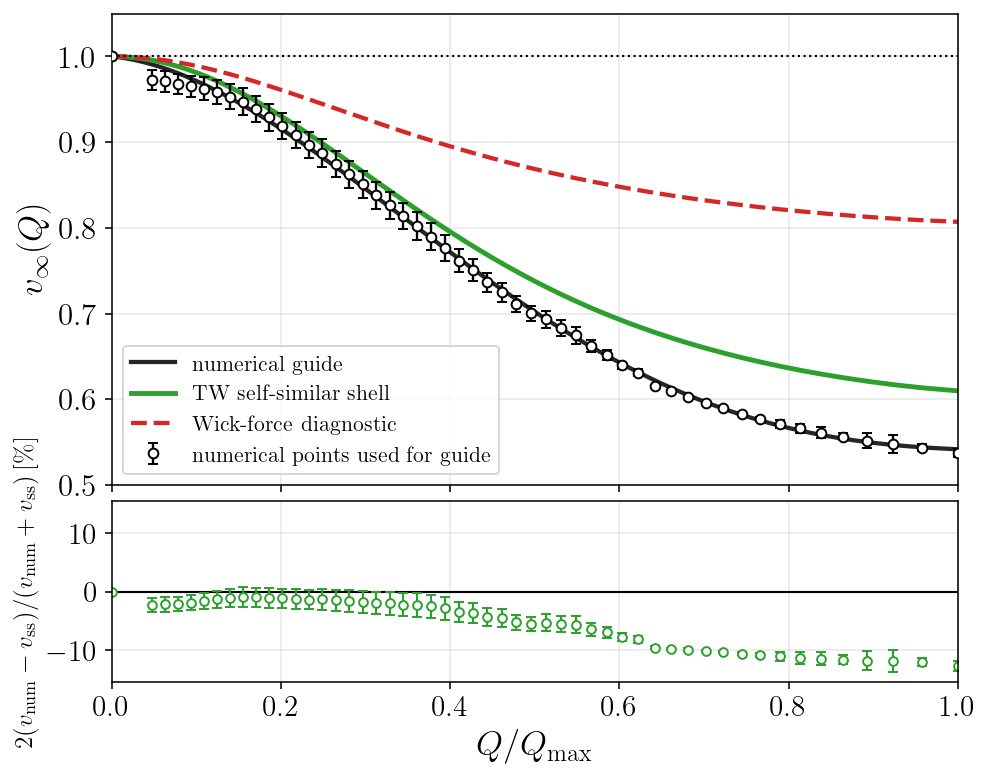

[guide-consistent presentation plot diagnostics]
broad late-time window = [6.000, t_max] after t < Lr
tail window            = final 25.0% of broad late-time window
fit points used for    = Q/Qmax <= 0.650, only if fit stable
vacua source           = vacua_of_Omega(MODEL, omega=0)
rho_i, rho_f           = 1.00000002e+00, 1.99986461e+00
eps_i, eps_f, Deps     = 1.00000004e+00, 3.99945846e+00, 2.99945842e+00
D                      = 6.99945857e+00
DeltaV                 = 1.00000002e+00
Q_max_plot             = 5.44930347e+04
USE_ETA0_IN_TW         = True
ETA0_SIGN_IN_OMEGA_R   = +1.0
beta_for_eta           = 10.0
Omega nodes range      = [0.00000000e+00, 1.32666822e+00]
v_tail range           = [5.36914633e-01, 9.49092688e-01]
v_fit range            = [5.79353748e-01, 9.72614987e-01]
v_point range          = [5.36914633e-01, 9.72614987e-01]
dv_point range         = [0.00000000e+00, 1.62294889e-02]
v_tail_std range       = [5.81252721e-04, 2.99331314e-03]
v_tail_mad range       = [3.2843

In [52]:
if "scan_terminal_results" in globals() and len(scan_terminal_results) > 0:
    # ============================================================
    # Presentation plot with points consistent with the black guide:
    #
    #   broad late-time window:
    #       6 <= t <= t_max
    #   after the box cut:
    #       t < Lr
    #
    #   estimators:
    #       v_tail = median[v(t)] in the final tail
    #       v_fit  = intercept of v(t) = v_inf + a/t + b/t^2
    #
    #   points used for the black curve:
    #       for Q/Qmax <= Q_USE_FIT_MAX and stable fit:
    #           v_point = v_fit
    #       otherwise:
    #           v_point = v_tail
    #
    #   error bars:
    #       if using v_fit:
    #           dv = max[fit_rms, tail_err, FIT_TAIL_SPREAD_FACTOR*|v_fit-v_tail|]
    #       if using v_tail:
    #           dv = tail_err
    #
    #   The black numerical guide is fitted to exactly these plotted points.
    #
    #   top panel:
    #       numerical points used for guide + black guide
    #       + TW self-similar Lorentzian shell
    #       + Wick-force diagnostic
    #
    #   bottom panel:
    #       100 * 2 * (v_point - v_ss) / (v_point + v_ss)
    # ============================================================

    import numpy as np
    import matplotlib.pyplot as plt

    # =========================
    # switches
    # =========================
    USE_ETA0_IN_TW = True
    ETA0_SIGN_IN_OMEGA_R = +1.0

    PLOT_WICK_DIAGNOSTIC = True
    PLOT_SELFSIMILAR_TW = True
    PLOT_GUIDE = True
    PLOT_RELATIVE_RESIDUAL_PANEL = True

    T_LATE_MIN = 6.0
    MIN_LATE_POINTS = 5
    MIN_TAIL_POINTS = 5
    MIN_FIT_POINTS = 5

    TAIL_FRACTION = 0.25
    USE_LAST_IN_ERROR = True

    # Fit quality cuts.
    # Do not reject the fit just because v_fit lies outside the observed late-time range:
    # for small Q the fit is supposed to extrapolate the still-rising profile.
    FIT_RIDGE_LAMBDA = 1e-6
    FIT_RMS_ABS_TOL = 0.010
    FIT_RMS_REL_TOL = 0.030
    FIT_PHYS_MIN = 0.0
    FIT_PHYS_MAX = 1.02

    # Use v_fit as the point estimator only below this charge, if stable.
    Q_USE_FIT_MAX = 0.65

    # Error assigned to fit points.
    FIT_TAIL_SPREAD_FACTOR = 0.50

    N_TW_GRID = 600
    POLY_DEG = 4

    SAVE_FIG = False
    OUTNAME = "terminal_velocity_points_consistent_with_guide.pdf"

    # =========================
    # checks
    # =========================
    if "scan_terminal_results" not in globals() or len(scan_terminal_results) == 0:
        raise RuntimeError("Missing scan_terminal_results. Run/load the terminal-velocity scan first.")

    if "CFG_2D" not in globals() or not isinstance(CFG_2D, dict) or "Lr" not in CFG_2D:
        raise RuntimeError("CFG_2D['Lr'] required.")

    if "U" not in globals():
        raise RuntimeError("Missing potential U.")

    _Lr_vel = float(CFG_2D["Lr"])


    # =========================
    # generic helpers
    # =========================
    def _safe_float_plot(x, default=np.nan):
        try:
            arr = np.asarray(x)
            if arr.size == 1:
                return float(arr.ravel()[0])
        except Exception:
            pass

        try:
            return float(x)
        except Exception:
            return float(default)


    def _nan_range(x):
        x = np.asarray(x, dtype=float)
        if not np.any(np.isfinite(x)):
            return "[nan, nan]"
        return f"[{np.nanmin(x):.8e}, {np.nanmax(x):.8e}]"


    def _tv_within_Lr(t, v):
        """
        Keep finite samples with 0 < t < Lr.
        """
        t = np.atleast_1d(np.asarray(t, dtype=float)).flatten()
        v = np.atleast_1d(np.asarray(v, dtype=float)).flatten()

        n = min(t.size, v.size)
        m = (
            np.isfinite(t[:n])
            & np.isfinite(v[:n])
            & (t[:n] > 0.01)
            & (t[:n] < _Lr_vel)
        )

        return t[:n][m], v[:n][m]


    def _late_window_from_6_to_max(t, v):
        """
        Broad late-time window:
            6 <= t <= t_max
        after t < Lr has already been applied.
        """
        t = np.asarray(t, dtype=float)
        v = np.asarray(v, dtype=float)

        m = np.isfinite(t) & np.isfinite(v) & (t >= T_LATE_MIN)

        return t[m], v[m]


    def _tail_from_late_window(t_late, v_late):
        """
        Final tail window:
            last TAIL_FRACTION of the broad late-time window.

        Also returns the previous tail segment for a drift estimate.
        """
        t_late = np.asarray(t_late, dtype=float)
        v_late = np.asarray(v_late, dtype=float)

        n_late = int(v_late.size)
        n_tail = max(MIN_TAIL_POINTS, int(np.ceil(TAIL_FRACTION * n_late)))
        n_tail = min(n_tail, n_late)

        t_tail = t_late[-n_tail:]
        v_tail = v_late[-n_tail:]

        if n_late >= 2 * n_tail:
            t_prev_tail = t_late[-2 * n_tail : -n_tail]
            v_prev_tail = v_late[-2 * n_tail : -n_tail]
        else:
            t_prev_tail = t_late[: n_late - n_tail]
            v_prev_tail = v_late[: n_late - n_tail]

        return t_tail, v_tail, t_prev_tail, v_prev_tail


    def _tail_robust_stats_from_tv(t, v):
        """
        Tail estimator:
            v_tail = median[v(t)] in the final tail.

        Tail error:
            tail_err = max[std_tail, MAD_tail, drift_from_previous_tail, last_offset].
        """
        t, v = _tv_within_Lr(t, v)
        t_late, v_late = _late_window_from_6_to_max(t, v)

        if v_late.size < MIN_LATE_POINTS:
            return {
                "ok": False,
                "n_late": int(v_late.size),
                "n_tail": 0,
                "v_tail": np.nan,
                "tail_err": np.nan,
                "v_last": np.nan,
                "v_late_median": np.nan,
                "v_late_mean": np.nan,
                "v_late_std": np.nan,
                "v_tail_median": np.nan,
                "v_tail_mean": np.nan,
                "v_tail_std": np.nan,
                "v_tail_mad": np.nan,
                "v_prev_tail_median": np.nan,
                "v_tail_drift": np.nan,
                "v_last_offset": np.nan,
            }

        t_tail, v_tail, t_prev_tail, v_prev_tail = _tail_from_late_window(t_late, v_late)

        if v_tail.size < MIN_TAIL_POINTS:
            return {
                "ok": False,
                "n_late": int(v_late.size),
                "n_tail": int(v_tail.size),
                "v_tail": np.nan,
                "tail_err": np.nan,
                "v_last": np.nan,
                "v_late_median": np.nan,
                "v_late_mean": np.nan,
                "v_late_std": np.nan,
                "v_tail_median": np.nan,
                "v_tail_mean": np.nan,
                "v_tail_std": np.nan,
                "v_tail_mad": np.nan,
                "v_prev_tail_median": np.nan,
                "v_tail_drift": np.nan,
                "v_last_offset": np.nan,
            }

        v_last = float(v[-1])

        v_late_median = float(np.nanmedian(v_late))
        v_late_mean = float(np.nanmean(v_late))
        v_late_std = float(np.nanstd(v_late))

        v_tail_median = float(np.nanmedian(v_tail))
        v_tail_mean = float(np.nanmean(v_tail))
        v_tail_std = float(np.nanstd(v_tail))

        tail_mad = float(np.nanmedian(np.abs(v_tail - v_tail_median)))
        v_tail_mad = 1.4826 * tail_mad

        if v_prev_tail.size >= MIN_TAIL_POINTS:
            v_prev_tail_median = float(np.nanmedian(v_prev_tail))
            v_tail_drift = abs(v_tail_median - v_prev_tail_median)
        else:
            v_prev_tail_median = np.nan
            v_tail_drift = 0.0

        v_last_offset = abs(v_last - v_tail_median)

        err_components = [
            v_tail_std,
            v_tail_mad,
            v_tail_drift,
        ]

        if USE_LAST_IN_ERROR:
            err_components.append(v_last_offset)

        tail_err = float(
            np.nanmax(
                [
                    np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
                    for x in err_components
                ]
            )
        )

        return {
            "ok": True,
            "n_late": int(v_late.size),
            "n_tail": int(v_tail.size),
            "v_tail": v_tail_median,
            "tail_err": tail_err,
            "v_last": v_last,
            "v_late_median": v_late_median,
            "v_late_mean": v_late_mean,
            "v_late_std": v_late_std,
            "v_tail_median": v_tail_median,
            "v_tail_mean": v_tail_mean,
            "v_tail_std": v_tail_std,
            "v_tail_mad": v_tail_mad,
            "v_prev_tail_median": v_prev_tail_median,
            "v_tail_drift": v_tail_drift,
            "v_last_offset": v_last_offset,
        }


    def _tail_robust_stats_for_row(r):
        raw_t = r.get("t_snap", None)
        raw_v = r.get("velocity_t", None)

        if raw_t is None or raw_v is None:
            return {
                "ok": False,
                "n_late": 0,
                "n_tail": 0,
                "v_tail": np.nan,
                "tail_err": np.nan,
                "v_last": np.nan,
                "v_late_median": np.nan,
                "v_late_mean": np.nan,
                "v_late_std": np.nan,
                "v_tail_median": np.nan,
                "v_tail_mean": np.nan,
                "v_tail_std": np.nan,
                "v_tail_mad": np.nan,
                "v_prev_tail_median": np.nan,
                "v_tail_drift": np.nan,
                "v_last_offset": np.nan,
            }

        return _tail_robust_stats_from_tv(raw_t, raw_v)


    def _fit_stats_for_row(r):
        """
        Fit:
            v(t) = v_inf + a/t + b/t^2
        on the broad late-time window.

        Fit is accepted as stable if:
          - finite and physical,
          - fit_rms is small.

        It is NOT rejected for being outside the observed late-time range,
        because for small Q the profile may still be slowly approaching the plateau.
        """
        raw_t = r.get("t_snap", None)
        raw_v = r.get("velocity_t", None)

        out = {
            "v_fit": np.nan,
            "v_fit_rms": np.nan,
            "fit_stable": False,
            "fit_reason": "not fitted",
        }

        if raw_t is None or raw_v is None:
            return out

        t, v = _tv_within_Lr(raw_t, raw_v)
        t_late, v_late = _late_window_from_6_to_max(t, v)

        if t_late.size < MIN_FIT_POINTS or np.unique(t_late).size < 3:
            out["fit_reason"] = (
                f"too few late points for fit: n_late={t_late.size}, "
                f"unique={np.unique(t_late).size}"
            )
            return out

        u_late = 1.0 / t_late
        X_late = np.column_stack([np.ones_like(t_late), u_late, u_late**2])

        # Ridge only on a/t and b/t^2, not on v_inf.
        L = np.array(
            [
                [0.0, 0.0, 0.0],
                [0.0, 1.0, 0.0],
                [0.0, 0.0, 1.0],
            ]
        )

        try:
            coef = np.linalg.solve(
                X_late.T @ X_late + FIT_RIDGE_LAMBDA * L,
                X_late.T @ v_late,
            )

            v_fit = float(coef[0])
            v_fit_curve = X_late @ coef
            v_fit_rms = float(np.sqrt(np.nanmean((v_late - v_fit_curve)**2)))

            v_scale = max(abs(float(np.nanmedian(v_late))), 1e-12)

            physical = (
                np.isfinite(v_fit)
                and (FIT_PHYS_MIN <= v_fit <= FIT_PHYS_MAX)
            )

            rms_ok = (
                np.isfinite(v_fit_rms)
                and (v_fit_rms <= max(FIT_RMS_ABS_TOL, FIT_RMS_REL_TOL * v_scale))
            )

            reasons = []
            if not physical:
                reasons.append(f"non-physical v_fit={v_fit:.4g}")
            if not rms_ok:
                reasons.append(f"fit_rms={v_fit_rms:.4g} too large")

            out["v_fit"] = v_fit
            out["v_fit_rms"] = v_fit_rms
            out["fit_stable"] = bool(physical and rms_ok)
            out["fit_reason"] = "stable" if out["fit_stable"] else "; ".join(reasons)

            return out

        except np.linalg.LinAlgError:
            out["fit_reason"] = "linear solve failed"
            return out


    def _fit_curve_anchored_at_one(q, v, q_grid, deg=4):
        """
        Black guide:
            v(q) = 1 - sum_k a_k q^k,
        fitted to the same points plotted with error bars.
        """
        q = np.asarray(q, dtype=float)
        v = np.asarray(v, dtype=float)

        m = np.isfinite(q) & np.isfinite(v) & (q >= 0.0) & (q <= 1.05)
        q = q[m]
        v = v[m]

        q = np.concatenate([[0.0], q])
        v = np.concatenate([[1.0], v])

        order = np.argsort(q)
        q = q[order]
        v = v[order]

        if len(q) >= deg + 1:
            X = np.column_stack([q**k for k in range(1, deg + 1)])
            y = 1.0 - v
            coef, *_ = np.linalg.lstsq(X, y, rcond=None)
            v_grid = 1.0 - sum(coef[k - 1] * q_grid**k for k in range(1, deg + 1))
        else:
            v_grid = np.interp(q_grid, q, v)

        return np.clip(v_grid, 0.0, 1.05)


    def _U_scalar(phi):
        return float(np.asarray(U(np.array([float(phi)], dtype=float))).flat[0])


    def _infer_zero_charge_vacua():
        """
        Return rho_i, rho_f.

        Convention:
          rho_i = false/initial vacuum
          rho_f = true/final vacuum
        """
        if "rho_false_0" in globals() and "rho_true_0" in globals():
            return float(rho_false_0), float(rho_true_0), "rho_false_0/rho_true_0"

        for name in ("col_thin", "col_thick", "col"):
            if name in globals():
                c = globals()[name]
                if isinstance(c, dict):
                    if "rho_false_0" in c and "rho_true_0" in c:
                        return float(c["rho_false_0"]), float(c["rho_true_0"]), name
                    if "rho_i" in c and "rho_f" in c:
                        return float(c["rho_i"]), float(c["rho_f"]), name

        if "MODEL" in globals():
            try:
                from Bubble_finder.potential_bubble import vacua_of_Omega

                rf, rt = vacua_of_Omega(
                    float(MODEL.phi0),
                    float(MODEL.v1),
                    float(MODEL.v2),
                    0.0,
                    verbose=False,
                )
                return float(rf), float(rt), "vacua_of_Omega(MODEL, omega=0)"

            except Exception as exc:
                raise RuntimeError(
                    "Could not infer zero-charge vacua from MODEL. "
                    "Define rho_false_0 and rho_true_0 explicitly."
                ) from exc

        raise RuntimeError(
            "Could not infer zero-charge vacua. Define rho_false_0 and rho_true_0."
        )


    # =========================
    # TW helper functions
    # =========================
    def _AB_of_Omega(Omega_arr, eps_i, eps_f):
        Omega_arr = np.asarray(Omega_arr, dtype=float)

        Deps = eps_f - eps_i
        D = eps_f + 3.0 * eps_i

        pref = (
            (8.0 / 5.0)
            * eps_i
            * Omega_arr**2
            * Deps
            / D**2
        )

        A = pref * (2.0 * eps_f + 3.0 * eps_i)
        B = pref * (3.0 * Deps)

        return A, B


    def _tw_velocity_wick_force(Omega_arr, eps_i, eps_f, DeltaV):
        """
        Wick-force diagnostic:
            s^2 -> -gamma^2 v^2 = -v^2/(1-v^2)
        """
        Omega_arr = np.asarray(Omega_arr, dtype=float)
        A, B = _AB_of_Omega(Omega_arr, eps_i, eps_f)

        v_out = np.full_like(Omega_arr, np.nan, dtype=float)

        num = DeltaV + A
        den = DeltaV + A + B

        good = np.isfinite(num) & np.isfinite(den) & (den > 0.0)

        v2 = np.full_like(Omega_arr, np.nan, dtype=float)
        v2[good] = num[good] / den[good]

        physical = good & np.isfinite(v2) & (v2 >= 0.0) & (v2 <= 1.0)
        v_out[physical] = np.sqrt(v2[physical])

        return v_out


    def _selfsimilar_Ealpha_coeff(v, Omega, eps_i, eps_f):
        v = float(v)
        Omega = float(Omega)

        if not (0.0 < v < 1.0):
            return np.nan

        Deps = eps_f - eps_i

        den = eps_f * v**2 + 2.0 * eps_i * v + eps_i
        if not np.isfinite(den) or abs(den) < 1e-300:
            return np.nan

        Ecoeff = (
            eps_i
            * Omega**2
            * Deps
            * v**3
            * (1.0 + v)**3
            * (eps_f * v**2 - eps_i)
            / (
                6.0
                * (1.0 - v)
                * den**2
            )
        )

        return Ecoeff


    def _tw_velocity_selfsimilar(Omega_arr, eps_i, eps_f, DeltaV):
        """
        Solve:
            Ealpha_coeff(v, Omega) = DeltaV * v^3 / 3.
        """
        Omega_arr = np.asarray(Omega_arr, dtype=float)
        v_out = np.full_like(Omega_arr, np.nan, dtype=float)

        if DeltaV <= 0.0:
            print("[warning] DeltaV <= 0 in self-similar TW estimate.")
            return v_out

        if eps_f <= eps_i:
            print("[warning] eps_f <= eps_i. Formula was derived assuming eps_f > eps_i.")

        def F(v, Om):
            return _selfsimilar_Ealpha_coeff(v, Om, eps_i, eps_f) - DeltaV * v**3 / 3.0

        for i, Om in enumerate(Omega_arr):
            if not np.isfinite(Om):
                continue

            if abs(Om) < 1e-300:
                v_out[i] = 1.0
                continue

            v_min = 1e-5
            v_max = 1.0 - 1e-7

            vv = np.linspace(v_min, v_max, 3000)
            ff = np.asarray([F(x, Om) for x in vv], dtype=float)

            good = np.isfinite(ff)
            if not np.any(good):
                continue

            vv = vv[good]
            ff = ff[good]

            idx = np.where((ff[:-1] <= 0.0) & (ff[1:] >= 0.0))[0]

            if len(idx) == 0:
                if np.nanmax(ff) < 0.0:
                    v_out[i] = 1.0
                continue

            j = idx[0]
            lo = float(vv[j])
            hi = float(vv[j + 1])
            flo = float(ff[j])

            for _ in range(120):
                mid = 0.5 * (lo + hi)
                fmid = F(mid, Om)

                if not np.isfinite(fmid):
                    break

                if abs(fmid) < 1e-13:
                    lo = mid
                    hi = mid
                    break

                if flo * fmid <= 0.0:
                    hi = mid
                else:
                    lo = mid
                    flo = fmid

            v_out[i] = 0.5 * (lo + hi)

        return v_out


    # =========================
    # scan arrays
    # =========================
    rows = list(scan_terminal_results)

    Q_vals = np.asarray([_safe_float_plot(r.get("Q", np.nan)) for r in rows], dtype=float)
    Q_max_plot = float(np.nanmax(Q_vals)) if np.any(np.isfinite(Q_vals)) else np.nan

    q_vals = np.asarray(
        [
            float(Q_vals[i] / Q_max_plot)
            if np.isfinite(Q_max_plot) and abs(Q_max_plot) > 1e-30 and np.isfinite(Q_vals[i])
            else np.nan
            for i in range(len(Q_vals))
        ],
        dtype=float,
    )

    omega_vals = np.asarray([_safe_float_plot(r.get("omega", np.nan)) for r in rows], dtype=float)
    eta0_vals = np.asarray([_safe_float_plot(r.get("eta0", np.nan)) for r in rows], dtype=float)

    beta_for_eta = float(globals().get("beta_fixed_terminal_scan", np.nan))

    if USE_ETA0_IN_TW and np.isfinite(beta_for_eta) and abs(beta_for_eta) > 1e-300:
        Omega_vals = omega_vals + ETA0_SIGN_IN_OMEGA_R * eta0_vals / beta_for_eta
    else:
        Omega_vals = omega_vals.copy()

    _tail_stats = [_tail_robust_stats_for_row(r) for r in rows]
    _fit_stats = [_fit_stats_for_row(r) for r in rows]

    v_tail_vals = np.asarray([s["v_tail"] for s in _tail_stats], dtype=float)
    tail_err_vals = np.asarray([s["tail_err"] for s in _tail_stats], dtype=float)

    v_late_median_vals = np.asarray([s["v_late_median"] for s in _tail_stats], dtype=float)
    v_late_std_vals = np.asarray([s["v_late_std"] for s in _tail_stats], dtype=float)

    v_tail_median_vals = np.asarray([s["v_tail_median"] for s in _tail_stats], dtype=float)
    v_tail_std_vals = np.asarray([s["v_tail_std"] for s in _tail_stats], dtype=float)
    v_tail_mad_vals = np.asarray([s["v_tail_mad"] for s in _tail_stats], dtype=float)
    v_tail_drift_vals = np.asarray([s["v_tail_drift"] for s in _tail_stats], dtype=float)
    v_last_offset_vals = np.asarray([s["v_last_offset"] for s in _tail_stats], dtype=float)

    n_late_vals = np.asarray([s["n_late"] for s in _tail_stats], dtype=int)
    n_tail_vals = np.asarray([s["n_tail"] for s in _tail_stats], dtype=int)

    v_fit_vals = np.asarray([s["v_fit"] for s in _fit_stats], dtype=float)
    v_fit_rms_vals = np.asarray([s["v_fit_rms"] for s in _fit_stats], dtype=float)
    fit_stable_vals = np.asarray([bool(s["fit_stable"]) for s in _fit_stats], dtype=bool)

    # =========================
    # build exactly the points used for the black guide
    # =========================
    use_fit_vals = (
        fit_stable_vals
        & np.isfinite(v_fit_vals)
        & (q_vals <= Q_USE_FIT_MAX)
    )

    v_point_vals = np.where(use_fit_vals, v_fit_vals, v_tail_vals)

    fit_err_vals = np.nan_to_num(v_fit_rms_vals, nan=0.0, posinf=0.0, neginf=0.0)
    tail_err_safe = np.nan_to_num(tail_err_vals, nan=0.0, posinf=0.0, neginf=0.0)

    fit_spread_vals = (
        FIT_TAIL_SPREAD_FACTOR
        * np.abs(np.nan_to_num(v_fit_vals - v_tail_vals, nan=0.0, posinf=0.0, neginf=0.0))
    )

    dv_point_vals = np.where(
        use_fit_vals,
        np.maximum.reduce([fit_err_vals, tail_err_safe, fit_spread_vals]),
        tail_err_safe,
    )

    order = np.argsort(q_vals)

    q_vals = q_vals[order]
    omega_vals = omega_vals[order]
    eta0_vals = eta0_vals[order]
    Omega_vals = Omega_vals[order]

    v_tail_vals = v_tail_vals[order]
    tail_err_vals = tail_err_vals[order]

    v_late_median_vals = v_late_median_vals[order]
    v_late_std_vals = v_late_std_vals[order]

    v_tail_median_vals = v_tail_median_vals[order]
    v_tail_std_vals = v_tail_std_vals[order]
    v_tail_mad_vals = v_tail_mad_vals[order]
    v_tail_drift_vals = v_tail_drift_vals[order]
    v_last_offset_vals = v_last_offset_vals[order]

    n_late_vals = n_late_vals[order]
    n_tail_vals = n_tail_vals[order]

    v_fit_vals = v_fit_vals[order]
    v_fit_rms_vals = v_fit_rms_vals[order]
    fit_stable_vals = fit_stable_vals[order]
    use_fit_vals = use_fit_vals[order]
    v_point_vals = v_point_vals[order]
    dv_point_vals = dv_point_vals[order]
    fit_spread_vals = fit_spread_vals[order]

    # =========================
    # numerical points and black guide
    # =========================
    m_num = (
        np.isfinite(q_vals)
        & np.isfinite(v_point_vals)
        & np.isfinite(dv_point_vals)
        & (q_vals >= 0.0)
        & (q_vals <= 1.0)
        & (n_late_vals >= MIN_LATE_POINTS)
        & (n_tail_vals >= MIN_TAIL_POINTS)
    )

    q_num_raw = q_vals[m_num]
    v_num_raw = v_point_vals[m_num]
    dv_num_raw = dv_point_vals[m_num]

    # Add neutral reference point.
    q_num = np.concatenate([[0.0], q_num_raw])
    v_num = np.concatenate([[1.0], v_num_raw])
    dv_num = np.concatenate([[0.0], dv_num_raw])

    sort_num = np.argsort(q_num)
    q_num = q_num[sort_num]
    v_num = v_num[sort_num]
    dv_num = dv_num[sort_num]

    # Black guide fitted to exactly these plotted points.
    q_plot = np.linspace(0.0, 1.0, 400)
    v_guide = _fit_curve_anchored_at_one(q_num, v_num, q_plot, deg=POLY_DEG)


    # =========================
    # TW curves
    # =========================
    rho_i, rho_f, vac_source = _infer_zero_charge_vacua()

    eps_i = rho_i**2
    eps_f = rho_f**2
    Deps = eps_f - eps_i
    D = eps_f + 3.0 * eps_i
    DeltaV = _U_scalar(rho_i) - _U_scalar(rho_f)

    if DeltaV <= 0.0:
        print(f"[warning] DeltaV={DeltaV:.6e} <= 0. Check vacuum ordering.")

    if Deps <= 0.0:
        print(f"[warning] eps_f-eps_i={Deps:.6e} <= 0. TW formula assumes eps_f > eps_i.")

    m_map = (
        np.isfinite(q_vals)
        & np.isfinite(Omega_vals)
        & (q_vals >= 0.0)
        & (q_vals <= 1.05)
    )

    q_map = np.concatenate([[0.0], q_vals[m_map]])
    Omega_map = np.concatenate([[0.0], Omega_vals[m_map]])

    q_round = np.round(q_map, 12)
    q_unique = np.unique(q_round)

    q_nodes = []
    Omega_nodes = []

    for qv in q_unique:
        mm = q_round == qv
        Om_mean = float(np.nanmean(Omega_map[mm]))
        if np.isfinite(Om_mean):
            q_nodes.append(float(qv))
            Omega_nodes.append(Om_mean)

    q_nodes = np.asarray(q_nodes, dtype=float)
    Omega_nodes = np.asarray(Omega_nodes, dtype=float)

    idx_nodes = np.argsort(q_nodes)
    q_nodes = q_nodes[idx_nodes]
    Omega_nodes = Omega_nodes[idx_nodes]

    q_tw = np.linspace(0.0, 1.0, N_TW_GRID)

    Omega_tw = np.interp(
        q_tw,
        q_nodes,
        Omega_nodes,
        left=0.0,
        right=Omega_nodes[-1] if Omega_nodes.size else np.nan,
    )

    v_wick = _tw_velocity_wick_force(Omega_tw, eps_i, eps_f, DeltaV)
    v_ss = _tw_velocity_selfsimilar(Omega_tw, eps_i, eps_f, DeltaV)


    # =========================
    # symmetric relative residual against self-similar TW
    # =========================
    v_ss_at_num = np.interp(q_num, q_tw, v_ss, left=np.nan, right=np.nan)

    den_rel = v_num + v_ss_at_num

    res_ss_rel = np.full_like(v_num, np.nan, dtype=float)
    dres_ss_rel = np.full_like(v_num, np.nan, dtype=float)

    m_rel = (
        np.isfinite(v_num)
        & np.isfinite(v_ss_at_num)
        & np.isfinite(dv_num)
        & (np.abs(den_rel) > 1e-14)
    )

    res_ss_rel[m_rel] = 2.0 * (v_num[m_rel] - v_ss_at_num[m_rel]) / den_rel[m_rel]

    dres_ss_rel[m_rel] = (
        4.0
        * np.abs(v_ss_at_num[m_rel])
        / den_rel[m_rel]**2
        * dv_num[m_rel]
    )

    res_ss_plot = 100.0 * res_ss_rel
    dres_ss_plot = 100.0 * dres_ss_rel


    # =========================
    # plot
    # =========================
    if PLOT_RELATIVE_RESIDUAL_PANEL:
        fig, (ax, axr) = plt.subplots(
            2,
            1,
            figsize=(7.8, 6.2),
            sharex=True,
            gridspec_kw={"height_ratios": [3.0, 1.15], "hspace": 0.05},
        )
    else:
        fig, ax = plt.subplots(figsize=(7.8, 5.0))
        axr = None

    ax.errorbar(
        q_num,
        v_num,
        yerr=dv_num,
        fmt="o",
        ms=5.0,
        lw=1.2,
        capsize=2.8,
        color="k",
        mfc="white",
        mec="k",
        label=r"numerical points used for guide",
        zorder=5,
    )

    if PLOT_GUIDE:
        ax.plot(
            q_plot,
            v_guide,
            color="k",
            lw=2.2,
            alpha=0.85,
            label=r"numerical guide",
        )

    if PLOT_SELFSIMILAR_TW:
        m = np.isfinite(q_tw) & np.isfinite(v_ss)
        if np.count_nonzero(m) > 0:
            ax.plot(
                q_tw[m],
                v_ss[m],
                color="tab:green",
                ls="-",
                lw=2.5,
                label=r"TW self-similar shell",
            )

    if PLOT_WICK_DIAGNOSTIC:
        m = np.isfinite(q_tw) & np.isfinite(v_wick)
        if np.count_nonzero(m) > 0:
            ax.plot(
                q_tw[m],
                v_wick[m],
                color="tab:red",
                ls="--",
                lw=2.2,
                label=r"Wick-force diagnostic",
            )

    ax.axhline(1.0, color="k", ls=":", lw=1.1)

    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.5, 1.05)
    ax.set_ylabel(r"$v_\infty(Q)$", fontsize=18)
    ax.tick_params(axis="both", labelsize=16)
    ax.grid(True, alpha=0.28)
    ax.legend(loc="best", fontsize=11.2, frameon=True)

    if axr is not None:
        m_res = (
            np.isfinite(q_num)
            & np.isfinite(res_ss_plot)
            & np.isfinite(dres_ss_plot)
        )

        axr.axhline(0.0, color="k", lw=1.1)

        axr.errorbar(
            q_num[m_res],
            res_ss_plot[m_res],
            yerr=dres_ss_plot[m_res],
            fmt="o",
            ms=4.5,
            lw=1.1,
            capsize=2.5,
            color="tab:green",
            mfc="white",
            mec="tab:green",
        )

        axr.set_xlabel(r"$Q/Q_{\max}$", fontsize=18)
        axr.set_ylabel(
            r"$2(v_{\rm num}-v_{\rm ss})/(v_{\rm num}+v_{\rm ss})\,[\%]$",
            fontsize=13,
        )
        axr.tick_params(axis="both", labelsize=15)
        axr.grid(True, alpha=0.28)

        if np.any(m_res):
            rmax = np.nanpercentile(np.abs(res_ss_plot[m_res]), 90)
            rmax = max(float(rmax), 3.0)
            axr.set_ylim(-1.35 * rmax, 1.35 * rmax)

    else:
        ax.set_xlabel(r"$Q/Q_{\max}$", fontsize=18)

    fig.tight_layout()

    if SAVE_FIG or ("CFG" in globals() and isinstance(CFG, dict) and CFG.get("save_figures", False)):
        fig.savefig(CFG["figures_dir"] / OUTNAME, bbox_inches="tight")

    plt.show()


    # =========================
    # diagnostics
    # =========================
    print("[guide-consistent presentation plot diagnostics]")
    print(f"broad late-time window = [{T_LATE_MIN:.3f}, t_max] after t < Lr")
    print(f"tail window            = final {100.0 * TAIL_FRACTION:.1f}% of broad late-time window")
    print(f"fit points used for    = Q/Qmax <= {Q_USE_FIT_MAX:.3f}, only if fit stable")
    print(f"vacua source           = {vac_source}")
    print(f"rho_i, rho_f           = {rho_i:.8e}, {rho_f:.8e}")
    print(f"eps_i, eps_f, Deps     = {eps_i:.8e}, {eps_f:.8e}, {Deps:.8e}")
    print(f"D                      = {D:.8e}")
    print(f"DeltaV                 = {DeltaV:.8e}")
    print(f"Q_max_plot             = {Q_max_plot:.8e}")
    print(f"USE_ETA0_IN_TW         = {USE_ETA0_IN_TW}")
    print(f"ETA0_SIGN_IN_OMEGA_R   = {ETA0_SIGN_IN_OMEGA_R:+.1f}")
    print(f"beta_for_eta           = {beta_for_eta}")
    print(f"Omega nodes range      = {_nan_range(Omega_nodes)}")
    print(f"v_tail range           = {_nan_range(v_tail_vals)}")
    print(f"v_fit range            = {_nan_range(v_fit_vals)}")
    print(f"v_point range          = {_nan_range(v_point_vals)}")
    print(f"dv_point range         = {_nan_range(dv_point_vals)}")
    print(f"v_tail_std range       = {_nan_range(v_tail_std_vals)}")
    print(f"v_tail_mad range       = {_nan_range(v_tail_mad_vals)}")
    print(f"v_tail_drift range     = {_nan_range(v_tail_drift_vals)}")
    print(f"v_last_offset range    = {_nan_range(v_last_offset_vals)}")
    print(f"v_fit_rms range        = {_nan_range(v_fit_rms_vals)}")
    print(f"fit stable count       = {int(np.count_nonzero(fit_stable_vals))}/{fit_stable_vals.size}")
    print(f"fit used count         = {int(np.count_nonzero(use_fit_vals))}/{use_fit_vals.size}")
    print(f"n_late range           = [{np.nanmin(n_late_vals)}, {np.nanmax(n_late_vals)}]")
    print(f"n_tail range           = [{np.nanmin(n_tail_vals)}, {np.nanmax(n_tail_vals)}]")
    print(f"v_ss range             = {_nan_range(v_ss)}")
    print(f"v_wick range           = {_nan_range(v_wick)}")

    m_res = np.isfinite(q_num) & np.isfinite(res_ss_rel)
    if np.any(m_res):
        rel_rms = np.sqrt(np.nanmean(res_ss_rel[m_res]**2))
        rel_max = np.nanmax(np.abs(res_ss_rel[m_res]))

        print(f"relative residual rms      = {rel_rms:.8e}")
        print(f"relative residual max      = {rel_max:.8e}")
        print(f"relative residual rms [%]  = {100.0 * rel_rms:.4f}")
        print(f"relative residual max [%]  = {100.0 * rel_max:.4f}")

    print("")
    print("Definitions:")
    print("  broad late window = 6 <= t <= t_max, after t < Lr")
    print("  tail window       = final TAIL_FRACTION of broad late window")
    print("  v_tail            = median[v(t)] in tail window")
    print("  v_fit             = intercept of fit v_inf + a/t + b/t^2")
    print("  plotted point     = v_fit at low Q if stable, otherwise v_tail")
    print("  black guide       = anchored polynomial fit to exactly the plotted points")
    print("  dv_point          = fit/tail uncertainty consistent with chosen point")
    print("  residual          = 2*(v_point - v_ss)/(v_point + v_ss)")
    print("  v_ss              = Lorentzian self-similar TW shell prediction")
    print("  v_wick            = Wick-force diagnostic with s^2 -> -gamma^2 v^2")
else:
    print('Analysis cell 164 skipped: required cached data not loaded.')